# Prédiction du risque de réadmission hospitalière à 30 jours

**Sujet d'examen CISIA — Santé**

---

Un groupement hospitalier régional souhaite distinguer, au moment de la sortie d'hospitalisation, les situations à faible risque de celles qui appellent un suivi renforcé. La réadmission non programmée dans les trente jours est à la fois un signal de dégradation de l'état du patient et une charge évitable pour le système de soins.

Ce notebook conçoit et évalue un tel système à partir de onze sources de données hétérogènes — dossier administratif, codage médical, dossier patient informatisé, texte clinique, historique de recours aux soins, télésurveillance et indicateurs territoriaux.

Il comporte deux couches :

- la **production** — l'analyse, du cadrage à la proposition d'intégration ;
- le **journal de bord**, en dernière section — la méthode et les choix, y compris les pistes écartées et les décisions révisées.

Les encarts **Choix** disséminés dans la production renvoient à l'entrée correspondante du journal.

> Les données sont synthétiques et fournies à des fins pédagogiques. Elles ne proviennent d'aucun patient réel et ne doivent en aucun cas servir à une décision clinique.

<!-- sommaire : généré par sync_sommaire.py, ne pas éditer à la main -->

**Sommaire**

- <a href="#0.-L&#x27;essentiel-en-deux-minutes">0. L'essentiel en deux minutes</a>
- <a href="#1.-Cadrage">1. Cadrage</a>
  - <a href="#1.1-Ce-que-le-syst%C3%A8me-doit-produire">1.1 Ce que le système doit produire</a>
  - <a href="#1.2-Population-d&#x27;%C3%A9tude">1.2 Population d'étude</a>
  - <a href="#1.3-Protocole-d&#x27;%C3%A9valuation">1.3 Protocole d'évaluation</a>
  - <a href="#1.4-Cadre-r%C3%A9glementaire">1.4 Cadre réglementaire</a>
  - <a href="#1.5-Le-registre-de-blocs">1.5 Le registre de blocs</a>
- <a href="#2.-Le-jeu-de-donn%C3%A9es">2. Le jeu de données</a>
- <a href="#3.-Audit-qualit%C3%A9">3. Audit qualité</a>
  - <a href="#3.1-La-cible">3.1 La cible</a>
  - <a href="#3.2-S%C3%A9jours-par-patient">3.2 Séjours par patient</a>
  - <a href="#3.2-bis--Le-signal-existe-t-il-?">3.2 bis  Le signal existe-t-il ?</a>
  - <a href="#3.3-Valeurs-manquantes,-sentinelles-comprises">3.3 Valeurs manquantes, sentinelles comprises</a>
  - <a href="#3.4-Int%C3%A9grit%C3%A9-r%C3%A9f%C3%A9rentielle">3.4 Intégrité référentielle</a>
  - <a href="#3.5-Coh%C3%A9rence-temporelle">3.5 Cohérence temporelle</a>
  - <a href="#3.6-Couverture-de-la-t%C3%A9l%C3%A9surveillance">3.6 Couverture de la télésurveillance</a>
  - <a href="#3.7-Dur%C3%A9e-de-s%C3%A9jour-%E2%80%94-triangulation-de-trois-sources">3.7 Durée de séjour — triangulation de trois sources</a>
  - <a href="#3.8-Unit%C3%A9s-biologiques">3.8 Unités biologiques</a>
  - <a href="#3.9-Valeurs-implausibles">3.9 Valeurs implausibles</a>
- <a href="#4.-Nettoyage-et-harmonisation">4. Nettoyage et harmonisation</a>
- <a href="#5.-Blocs-de-variables">5. Blocs de variables</a>
  - <a href="#5.1-Constantes-vitales-%E2%80%94-r%C3%A9cup%C3%A9rer-le-temps-relatif">5.1 Constantes vitales — récupérer le temps relatif</a>
  - <a href="#5.2-Comptes-rendus-%E2%80%94-trois-gabarits,-des-champs-disjoints">5.2 Comptes-rendus — trois gabarits, des champs disjoints</a>
  - <a href="#5.3-Territoire-%E2%80%94-le-seul-proxy-socio-%C3%A9conomique-autoris%C3%A9">5.3 Territoire — le seul proxy socio-économique autorisé</a>
  - <a href="#5.4-Ex%C3%A9cution-des-blocs">5.4 Exécution des blocs</a>
  - <a href="#5.5-L&#x27;%C3%A9tage-B,-ex%C3%A9cut%C3%A9">5.5 L'étage B, exécuté</a>
- <a href="#6.-Assemblage">6. Assemblage</a>
  - <a href="#6.1-Format-d&#x27;%C3%A9change-et-mod%C3%A8le-de-stockage">6.1 Format d'échange et modèle de stockage</a>
  - <a href="#6.2-Cycle-de-vie-du-jeu-de-donn%C3%A9es">6.2 Cycle de vie du jeu de données</a>
- <a href="#7.-Mod%C3%A9lisation">7. Modélisation</a>
  - <a href="#7.1-Calibration">7.1 Calibration</a>
  - <a href="#7.2-Les-hyperparam%C3%A8tres-%E2%80%94-la-recherche-automatique,-et-pourquoi-elle-est-%C3%A9cart%C3%A9e">7.2 Les hyperparamètres — la recherche automatique, et pourquoi elle est écartée</a>
- <a href="#8.-Le-seuil-de-d%C3%A9cision">8. Le seuil de décision</a>
  - <a href="#8.1-Cons%C3%A9quences-op%C3%A9rationnelles">8.1 Conséquences opérationnelles</a>
  - <a href="#8.2-Sensibilit%C3%A9-au-co%C3%BBt">8.2 Sensibilité au coût</a>
- <a href="#9.-Interpr%C3%A9tabilit%C3%A9-et-apport-des-sources">9. Interprétabilité et apport des sources</a>
  - <a href="#9.1-Ce-sur-quoi-le-mod%C3%A8le-s&#x27;appuie">9.1 Ce sur quoi le modèle s'appuie</a>
  - <a href="#9.2-Ce-que-les-onze-sources-apportent-r%C3%A9ellement">9.2 Ce que les onze sources apportent réellement</a>
  - <a href="#9.3-Lisibilit%C3%A9-clinique">9.3 Lisibilité clinique</a>
- <a href="#10.-%C3%89quit%C3%A9">10. Équité</a>
  - <a href="#10.1-Trois-disparit%C3%A9s-%E2%80%94-%C3%A2ge,-isolement,-service">10.1 Trois disparités — âge, isolement, service</a>
  - <a href="#10.2-Le-troisi%C3%A8me-axe-d%C3%A9sign%C3%A9-%E2%80%94-le-profil-d&#x27;utilisation-des-soins">10.2 Le troisième axe désigné — le profil d'utilisation des soins</a>
  - <a href="#10.3-L&#x27;axe-le-plus-surveill%C3%A9-%E2%80%94-pas-de-disparit%C3%A9-d%C3%A9montrable">10.3 L'axe le plus surveillé — pas de disparité démontrable</a>
- <a href="#11.-Cadre-r%C3%A9glementaire-et-gouvernance">11. Cadre réglementaire et gouvernance</a>
  - <a href="#11.1-Ce-qui-a-%C3%A9t%C3%A9-fait-dans-la-conception">11.1 Ce qui a été fait dans la conception</a>
  - <a href="#11.2-Ce-qui-reste-%C3%A0-la-charge-de-l&#x27;%C3%A9tablissement">11.2 Ce qui reste à la charge de l'établissement</a>
  - <a href="#11.3-Le-point-de-vigilance-principal">11.3 Le point de vigilance principal</a>
  - <a href="#11.4-Le-cadre-%C3%A9thique,-au-del%C3%A0-du-droit">11.4 Le cadre éthique, au-delà du droit</a>
  - <a href="#11.5-Deux-qualifications-%C3%A0-trancher-avant-tout-d%C3%A9ploiement">11.5 Deux qualifications à trancher avant tout déploiement</a>
- <a href="#12.-Int%C3%A9gration-au-syst%C3%A8me-d&#x27;information-hospitalier">12. Intégration au système d'information hospitalier</a>
  - <a href="#12.1-O%C3%B9-le-syst%C3%A8me-s&#x27;ins%C3%A8re">12.1 Où le système s'insère</a>
  - <a href="#12.2-Ce-que-le-syst%C3%A8me-restitue">12.2 Ce que le système restitue</a>
  - <a href="#12.2-bis--Cette-architecture-est-impl%C3%A9ment%C3%A9e">12.2 bis  Cette architecture est implémentée</a>
  - <a href="#12.3-Extensibilit%C3%A9-%E2%80%94-d%C3%A9montr%C3%A9e,-pas-annonc%C3%A9e">12.3 Extensibilité — démontrée, pas annoncée</a>
  - <a href="#12.4-Surveillance-en-production">12.4 Surveillance en production</a>
  - <a href="#12.5-R%C3%A9examen-et-r%C3%A9entra%C3%AEnement">12.5 Réexamen et réentraînement</a>
  - <a href="#12.6-Sc%C3%A9narios-de-d%C3%A9ploiement,-conformit%C3%A9-et-co%C3%BBts">12.6 Scénarios de déploiement, conformité et coûts</a>
  - <a href="#12.7-Ce-qui-doit-%C3%AAtre-demand%C3%A9,-et-%C3%A0-qui">12.7 Ce qui doit être demandé, et à qui</a>
  - <a href="#12.8-La-cha%C3%AEne-d&#x27;int%C3%A9gration-continue">12.8 La chaîne d'intégration continue</a>
- <a href="#13.-Limites-et-suites">13. Limites et suites</a>
  - <a href="#13.1-Limites-de-la-donn%C3%A9e">13.1 Limites de la donnée</a>
  - <a href="#13.2-Limites-du-mod%C3%A8le">13.2 Limites du modèle</a>
  - <a href="#13.3-Suites">13.3 Suites</a>
  - <a href="#13.4-Conclusion">13.4 Conclusion</a>
  - <a href="#13.2-bis--Quatre-variables-de-la-litt%C3%A9rature,-construites-et-mesur%C3%A9es">13.2 bis  Quatre variables de la littérature, construites et mesurées</a>
- <a href="#14.-Journal-de-bord">14. Journal de bord</a>
  - <a href="#24/08/2026-%E2%80%94-S%C3%A9ance-1-:-cadrage-et-audit-initial">24/08/2026 — Séance 1 : cadrage et audit initial</a>
  - <a href="#24/08/2026-%E2%80%94-S%C3%A9ance-2-:-figures,-et-une-hypoth%C3%A8se-invalid%C3%A9e">24/08/2026 — Séance 2 : figures, et une hypothèse invalidée</a>
  - <a href="#01/09/2026-%E2%80%94-S%C3%A9ance-3-:-les-hyperparam%C3%A8tres,-mesur%C3%A9s">01/09/2026 — Séance 3 : les hyperparamètres, mesurés</a>
  - <a href="#07/09/2026-%E2%80%94-S%C3%A9ance-4-:-la-relecture-qui-a-trouv%C3%A9-une-correction-muette">07/09/2026 — Séance 4 : la relecture qui a trouvé une correction muette</a>
  - <a href="#08/09/2026-%E2%80%94-S%C3%A9ance-5-:-l&#x27;explication-individuelle-du-score">08/09/2026 — Séance 5 : l'explication individuelle du score</a>
  - <a href="#21/09/2026-%E2%80%94-S%C3%A9ance-6-:-le-troisi%C3%A8me-axe-de-vigilance,-mesur%C3%A9">21/09/2026 — Séance 6 : le troisième axe de vigilance, mesuré</a>
  - <a href="#28/09/2026-%E2%80%94-S%C3%A9ance-7-:-les-onze-tables-dessin%C3%A9es">28/09/2026 — Séance 7 : les onze tables dessinées</a>

## 0. L'essentiel en deux minutes

*Cette section raconte le travail sans vocabulaire technique. Tout ce qui y est affirmé est mesuré et démontré dans les sections suivantes.*

---

**La mission.** Un hôpital veut savoir, au moment où un patient sort, s'il risque de revenir dans le mois. Un retour précipité est à la fois un danger pour le patient et un coût évitable. On m'a confié onze fichiers — dossiers administratifs, diagnostics, analyses de sang, constantes vitales, ordonnances, comptes-rendus, objets connectés, données de territoire — pour construire un système qui repère les sorties à risque.

**Ce que j'ai trouvé dans les données, avant toute chose.** J'ai commencé par vérifier les fichiers au lieu de leur faire confiance, et cette vérification est devenue le cœur du travail. Cinq problèmes graves n'étaient annoncés nulle part : des analyses rattachées à des séjours qui n'existent pas, des dates d'examens qui ne correspondent pas aux dates des séjours, des bornes d'analyses fausses, des absences déguisées en texte — et des patients marqués comme réadmis **après leur décès**, certains mourant même deux fois. Ces données sont synthétiques, générées pour l'examen ; leur générateur a produit des incohérences qu'un vrai système hospitalier devrait lui aussi savoir détecter.

**Ce que le système fait.** Après nettoyage — chaque correction étant justifiée par une mesure, jamais par une intuition — le système attribue à chaque sortie un niveau de risque fiable : quand il annonce « 30 % de risque », environ trois patients sur dix reviennent effectivement. Réglé comme un outil de dépistage, il anticipe **huit réadmissions sur dix**, au prix d'alertes qui ne se confirmeront pas. Où placer ce curseur n'est pas une question de calcul mais une question de moyens — combien de sorties l'équipe peut-elle accompagner — et je montre les conséquences chiffrées de chaque réglage pour que l'hôpital décide en connaissance de cause.

**Ce que le système ne fait pas, et pourquoi je le dis.** L'essentiel de sa capacité de prédiction tient à l'âge et au nombre de maladies chroniques du patient. Les données les plus riches — l'évolution des constantes pendant le séjour, les analyses — n'apportent presque rien de plus, et j'ai pu démontrer pourquoi : les dates étant corrompues, l'évolution du patient dans le temps a été détruite à la source. Le système est construit pour l'exploiter dès que des données saines arriveront ; en attendant, il serait malhonnête de prétendre qu'il fait mieux qu'il ne fait. Il est notamment inopérant chez les patients de moins de 65 ans, et je recommande de ne pas l'y déployer seul.

**Ce qui a été vérifié.** Le système ne favorise ni ne défavorise les patients selon leur territoire — y compris les déserts médicaux, point que le sujet désignait comme sensible. Les règles de protection des données de santé sont respectées par construction : aucun nom ne circule, aucune donnée sociale individuelle n'est utilisée, et chaque alerte est explicable au patient qu'elle concerne.

**Le journal de bord**, en fin de document, retrace les choix dans l'ordre où ils ont été faits — y compris trois décisions que j'ai prises, testées, puis corrigées quand la mesure m'a donné tort — et une correction annoncée qui ne s'exécutait pas, trouvée à la relecture et réparée.

---

## 1. Cadrage

### 1.1 Ce que le système doit produire

L'énoncé nomme deux usages distincts, à deux moments distincts du parcours :

- **alerter les équipes médicales en sortie d'hospitalisation**, pour adapter le plan de sortie ;
- **cibler les visites à domicile**, à partir de la télésurveillance post-sortie.

Ces deux usages n'ont pas les mêmes données disponibles. Au moment de la sortie, aucune mesure d'objet connecté n'existe encore. Les confondre reviendrait à alimenter un modèle de sortie avec des données du futur.

L'architecture retenue sépare donc deux étages.

| Étage | Instant | Sources mobilisables | Décision soutenue |
|---|---|---|---|
| **A** | sortie (T0) | administratif, codage, biologie, constantes, prescriptions, texte, historique, territoire | renforcer ou non le plan de sortie |
| **B** | T0 + 7 jours | score de l'étage A + télésurveillance | déclencher ou non une visite à domicile |

Chaque bloc de variables déclare son étage. L'assemblage filtre sur cette déclaration : l'étanchéité temporelle est une propriété du code, pas une vigilance à exercer.

### 1.2 Population d'étude

L'unité d'observation est le **séjour**, pas le patient : c'est à la sortie d'un séjour donné que la décision se prend.

Les séjours terminés par un décès sont exclus : la question « ce patient sera-t-il réadmis dans les trente jours » ne se pose pas pour un patient qui vient de mourir. L'exclusion relève de la définition du périmètre.

Le jeu de données ne respecte d'ailleurs pas cette contrainte — 17 de ces 92 séjours sont marqués comme réadmis. C'est une incohérence, mesurée en 3.1.

### 1.3 Protocole d'évaluation

Deux contraintes structurent le protocole.

**Le découpage doit être groupé par patient.** Plusieurs séjours appartiennent au même patient. Un découpage aléatoire placerait un séjour en apprentissage et un autre du même patient en test. Cette fuite n'abîme pas les métriques — elle les embellit, ce qui la rend indétectable sans précaution explicite.

**L'exactitude est disqualifiée.** La cible est déséquilibrée : un modèle prédisant constamment « pas de réadmission » atteindrait plus de 80 %. L'évaluation repose sur la précision, le rappel et l'aire sous la courbe précision-rappel, avec un seuil de décision argumenté par le coût asymétrique des erreurs — un faux négatif est une réadmission non anticipée, un faux positif une visite à domicile inutile.

### 1.4 Cadre réglementaire

Les données traitées relèvent de l'article 9 du RGPD. Trois conséquences sur la conception, développées en section 10 :

- aucune donnée socio-économique individuelle n'est mobilisée — seule la table INSEE, agrégée à la commune, sert de proxy ;
- les identifiants directs (nom, prénom, contact de l'aidant) sont écartés des variables du modèle ;
- toute prédiction doit être explicable pour être opposable, ce qui oriente le choix du modèle.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from src import config as cfg, loading, audit, clean, blocks, assemble
from src import figures as figs

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=RuntimeWarning)
figs.appliquer_style()

print("Dossier de données :", cfg.DATA_DIR.name)
print("Cible :", cfg.TARGET, "| unité :", cfg.UNIT, "| groupe :", cfg.GROUP)

Dossier de données : CISIA - Sujet Santé
Cible : Readmission30j | unité : SejourID | groupe : PatientID


### 1.5 Le registre de blocs

Le pipeline est organisé en blocs indépendants, un par source. Chaque bloc reçoit les tables et la population d'étude, et renvoie un tableau indexé par séjour. Les blocs ne se connaissent pas entre eux.

C'est ce qui rend le système extensible au sens de l'énoncé : **ajouter une source revient à écrire une fonction et à l'enregistrer**, sans modifier le reste du pipeline.

In [2]:
blocks.registry()

,etage,sources,role
bloc,,,
demographie,A,patients,"Age, sexe, couverture, isolement, pathologies ..."
sejour,A,sejours,"Duree reparee, service, type, mode de sortie, ..."
diagnostics,A,diagnostics,"Codage CIM-10 : volume, roles, diagnostic prin..."
actes,A,actes,"Codage CCAM : volume, diversite, absence infor..."
biologie,A,biologies,"Panels harmonises en unite canonique, ecarts a..."
constantes,A,signes_vitaux,Constantes recalees sur le temps relatif : niv...
medications,A,medications,"Volume de prescription, classes ATC, polymedic..."
texte,A,comptes_rendus,Variables extraites du CRH par regles clinique...
historique,A,historique,Recours aux soins anterieur a l'admission


## 2. Le jeu de données

Onze fichiers, répartis entre sources internes à l'établissement et sources externes.

In [3]:
tables = loading.load_raw()
loading.table_overview(tables)

,lignes,colonnes,cle_primaire,unicite_cle
table,,,,
patients,620,11,PatientID,True
historique,759,6,EvenementID,True
sejours,878,10,SejourID,True
diagnostics,2062,5,DiagnosticID,False
actes,1254,6,ActeID,True
biologies,3721,8,BiologieID,False
signes_vitaux,24916,9,ConstanteID,True
medications,3728,9,PrescriptionID,True
comptes_rendus,1144,5,CompteRenduID,True


Le grain diffère d'une table à l'autre : `patients` est au patient, `sejours` au séjour, et les tables cliniques sont en relation un-à-plusieurs avec le séjour — plusieurs prélèvements, plusieurs relevés, plusieurs prescriptions par hospitalisation. L'assemblage devra donc agréger avant de joindre.

## 3. Audit qualité

L'audit ne corrige rien : il mesure. Chaque correction appliquée en section 4 renvoie à une mesure faite ici.

L'énoncé annonce trois familles d'anomalies — durées de séjour incohérentes, unités biologiques hétérogènes, capteurs défaillants. L'audit les confirme, et en révèle cinq autres qui ne sont pas annoncées.

### 3.1 La cible

In [4]:
audit.target_report(tables)

,sejours,patients,readmissions,taux
population,,,,
population brute,878,620,158,0.179954
apres exclusion des deces,786,575,141,0.179389


In [5]:
audit.target_by_discharge_mode(tables)

,sejours,readmissions,taux
ModeSortie,,,
Transfert,144,28,0.194444
Domicile,480,89,0.185417
Deces,92,17,0.184783
HAD,75,12,0.160000
EHPAD,87,12,0.137931


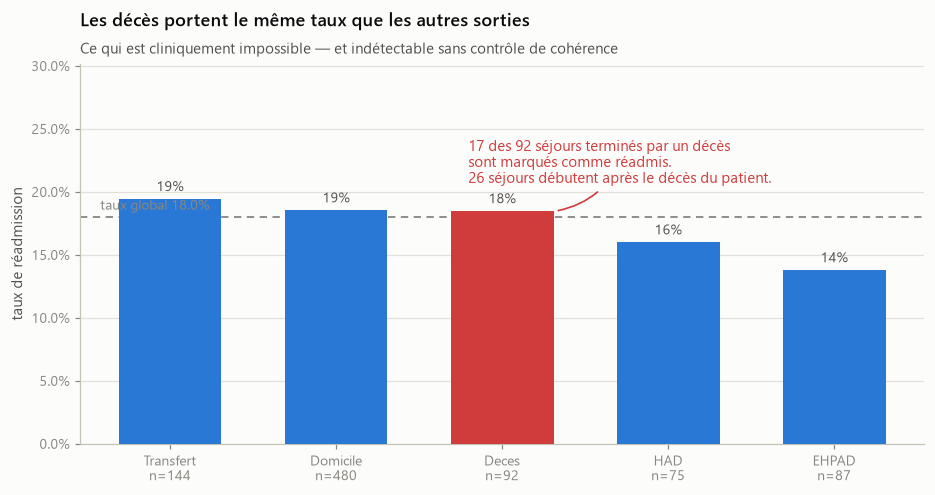

In [6]:
figs.fig_incoherence_deces(tables);

Deux précisions issues de la contre-vérification (journal J2-04).

**26 séjours débutent après le décès de leur propre patient**, et 24 d'entre eux — dont 4 marqués réadmis — restent dans la population d'étude, le filtre ne retirant que les séjours `Deces` eux-mêmes. Ils sont **conservés délibérément** : sur un jeu incohérent, rien ne permet de dire si c'est l'enregistrement du décès qui est erroné ou les séjours ultérieurs, et chaque séjour reste, pris isolément, une observation valide de la question posée à la sortie. L'impact d'une exclusion a été mesuré avant de trancher : 762 séjours, PR-AUC 0,403 (remesuré en J3-02) — un écart dans la variance de partition, aucun changement de conclusion.

**Deux patients meurent deux fois** (`SEJ-000144`/`145`, `SEJ-000399`/`400`), et l'un des seconds décès survient deux mois après le premier. Le générateur n'applique pas même l'unicité du décès.

> **Anomalie non annoncée — les décès sont marqués comme réadmis** (journal J2-01)
>
> Le taux de réadmission des séjours terminés par un décès devrait être nul. Il vaut 18,5 %, **indiscernable de celui des sorties à domicile** : 17 de ces 92 séjours portent `Readmission30j = 1`, et 26 séjours débutent après la date de décès de leur patient.
>
> Ces 92 séjours sont retirés de la population d'étude — non pour éviter une fuite, puisqu'ils portent exactement le taux de base et n'apprennent rien au modèle, mais parce qu'ils n'appartiennent pas à la population sur laquelle la question se pose.

### 3.2 Séjours par patient

In [7]:
audit.stays_per_patient(tables)

,patients,sejours_concernes
sejours_par_patient,,
1,382,382
2,218,436
3,20,60


### 3.2 bis  Le signal existe-t-il ?

Contrôle de plausibilité mené avant tout investissement en ingénierie de variables : le taux de réadmission suit-il une logique clinique ?

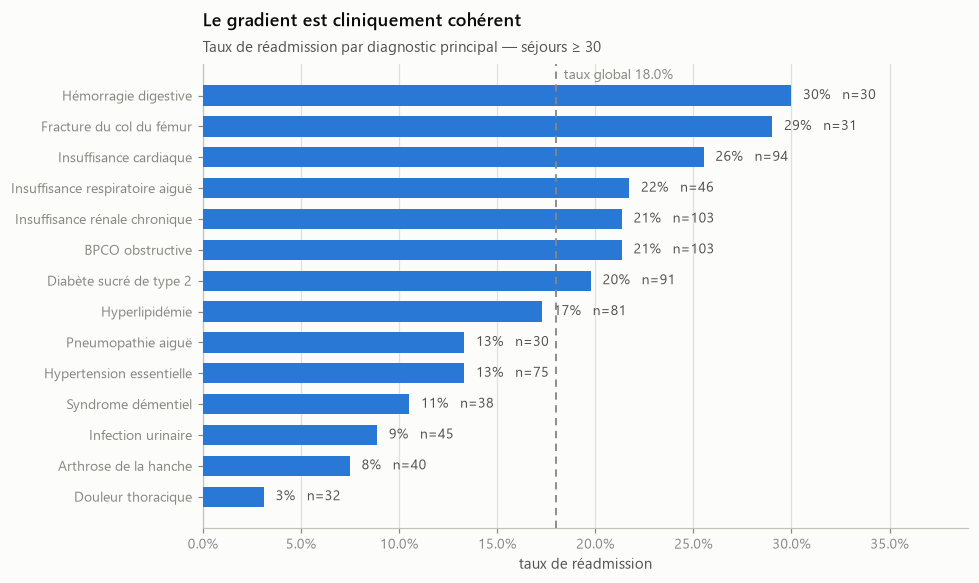

In [8]:
figs.fig_gradient_diagnostic(tables);

Pathologies chroniques décompensables en tête, motifs bénins et chirurgie réglée en queue. Le gradient est cliniquement cohérent, et défendable sur le fond médical.

Vérifier qu'un signal existe **avant** de construire 132 variables évite de découvrir trop tard qu'on modélise du bruit.

> **Choix — découpage groupé** (journal J1-07)
>
> Une majorité de patients n'a qu'un séjour, mais une part substantielle en a deux ou trois. Le découpage sera groupé sur `PatientID`.

### 3.3 Valeurs manquantes, sentinelles comprises

Un `isna()` ne suffit pas : dans `patients.csv`, l'absence est codée par la chaîne `"Non renseigné"`.

In [9]:
miss = audit.missing_report(tables)
miss.head(15).style.format({"taux": "{:.1%}"})

,table,colonne,nuls,sentinelles_texte,total,taux
0,signes_vitaux,FrequenceRespiratoire,2021,0,2021,8.1%
1,signes_vitaux,Temperature,1673,0,1673,6.7%
2,signes_vitaux,TensionDiastolique,1471,0,1471,5.9%
3,signes_vitaux,SpO2,1428,0,1428,5.7%
4,signes_vitaux,TensionSystolique,1275,0,1275,5.1%
5,signes_vitaux,FrequenceCardiaque,1245,0,1245,5.0%
6,medications,DateFin,777,0,777,20.8%
7,historique,DureeJours,326,0,326,43.0%
8,biologies,Valeur,299,0,299,8.0%
9,patients,PersonneAPrevenir,0,105,105,16.9%


In [10]:
# Ce que l'on manquerait en ne comptant que les valeurs nulles
sentinelles = miss[miss.sentinelles_texte > 0]
print("Colonnes dont les manquants sont invisibles à isna() :")
print(sentinelles[["table", "colonne", "nuls", "sentinelles_texte"]].to_string(index=False))

Colonnes dont les manquants sont invisibles à isna() :
   table            colonne  nuls  sentinelles_texte
patients  PersonneAPrevenir     0                105
patients SituationFamiliale     0                 67
patients    MedecinTraitant     0                 65
patients    RegimeAssurance     0                 38
patients               Sexe     0                 21


> **Anomalie non annoncée — manquants encodés en texte** (journal J1-04)
>
> Cinq colonnes de `patients.csv` renvoient zéro manquant à un audit naïf — jusqu'à 105 absences déguisées pour la personne à prévenir. La normalisation des sentinelles est un préalable à tout comptage, et elle se vérifie sur sa sortie : cette correction est restée muette pendant deux semaines sous pandas 3, dont les chaînes ne sont plus typées `object` (journal J3-02).

### 3.4 Intégrité référentielle

In [11]:
audit.referential_integrity(tables).style.format({"couverture": "{:.1%}"})

,table,cle,reference,orphelins,parents_couverts,parents_total,couverture
0,historique,PatientID,patients.PatientID,0,411,620,66.3%
1,sejours,PatientID,patients.PatientID,0,620,620,100.0%
2,diagnostics,SejourID,sejours.SejourID,0,878,878,100.0%
3,actes,SejourID,sejours.SejourID,0,649,878,73.9%
4,biologies,SejourID,sejours.SejourID,73,879,878,100.1%
5,signes_vitaux,SejourID,sejours.SejourID,0,878,878,100.0%
6,medications,SejourID,sejours.SejourID,0,878,878,100.0%
7,comptes_rendus,SejourID,sejours.SejourID,0,878,878,100.0%
8,objets_connectes,PatientID,patients.PatientID,125,184,620,29.7%


> **Anomalie non annoncée — clés orphelines** (journal J1-04, J3-10)
>
> Deux tables pointent vers un parent qui n'existe pas, et chaque fois par un identifiant unique :
>
> - 73 lignes de `biologies` portent le `SejourID` `SEJ-999999`, absent de `sejours.csv`. Elles sont écartées au nettoyage.
> - 125 mesures d'`objets_connectes` portent le `PatientID` `PAT-999999`, absent de `patients.csv`. Elles ne sont pas retirées : aucune jointure ne les retient, puisque la télésurveillance ne se rattache qu'aux sorties connues. Elles comptent en revanche un patient équipé de trop — 183 réels et non 184 (journal J1-06).
>
> Un identifiant au format valide, répété, sans correspondant : c'est une valeur sentinelle qui tient lieu de clé inconnue. Elle passe tout contrôle de format ; seule la jointure la trahit.
>
> À l'inverse, la couverture partielle de `actes` (649 séjours sur 878) n'est pas une anomalie : un séjour médical sans geste technique est cliniquement banal. Cette absence est **informative** et sera encodée comme telle, non imputée.

### 3.5 Cohérence temporelle

Vérification de bon sens : les examens d'un séjour tombent-ils dans la fenêtre de ce séjour ?

In [12]:
audit.temporal_coherence(tables).style.format(
    {"dans_la_fenetre": "{:.1%}", "decalage_median_j": "{:.0f} j"}
)

,table,lignes,dans_la_fenetre,decalage_median_j
0,biologies,3648,0.4%,-246 j
1,signes_vitaux,24916,1.5%,-229 j
2,actes,1254,0.2%,-466 j
3,comptes_rendus,1144,1.0%,-220 j


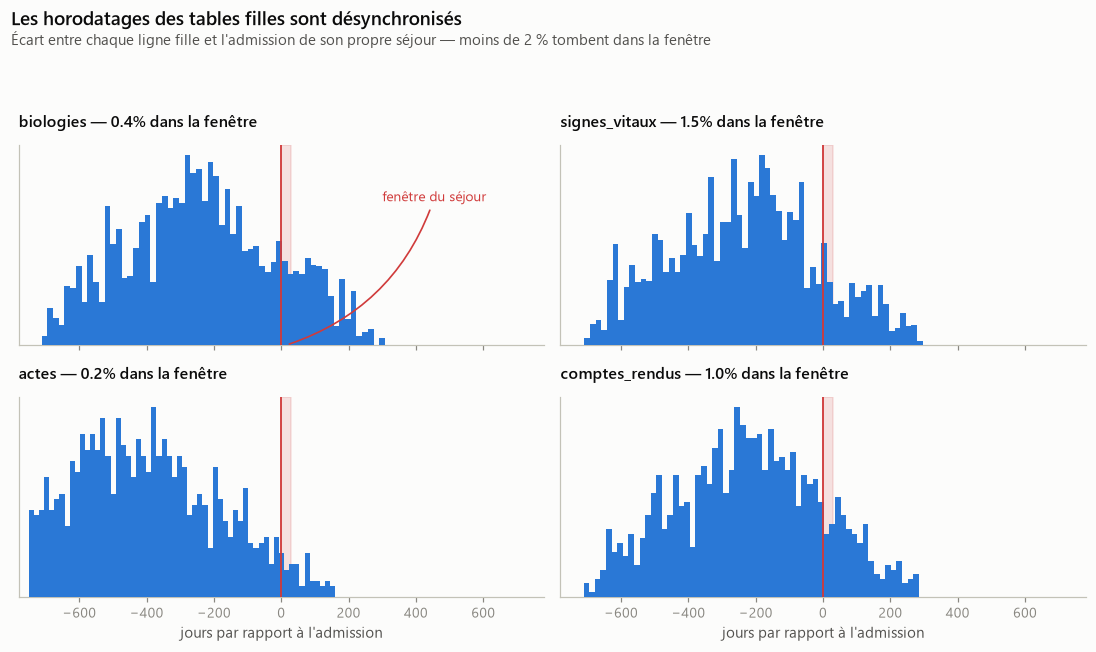

In [13]:
figs.fig_desynchronisation(tables);

Les quatre distributions sont centrées loin de zéro. La fenêtre du séjour — la bande rouge — ne recueille presque rien.

> **Anomalie non annoncée — horodatages désynchronisés** (journal J1-06)
>
> Moins de 2 % des lignes filles tombent dans la fenêtre de leur propre séjour, avec un décalage médian de plusieurs centaines de jours. Les dates des tables filles ont été tirées indépendamment des dates de séjour.
>
> Cette découverte a deux conséquences majeures, traitées en 3.6 et en section 5 : elle invalide l'entraînement de l'étage B, et elle interdit tout usage des horodatages absolus.

Il faut cependant distinguer ce qui est cassé de ce qui reste sain. Les liens `SejourID` sont valides — seules les **dates** sont fausses. Et l'historique de recours aux soins, lui, est cohérent.

In [14]:
h = tables["historique"].merge(
    tables["sejours"].groupby("PatientID").DateAdmission.min().rename("premiere_adm"),
    on="PatientID", how="left")
part = (h.DateEvenement < h.premiere_adm).mean()
print(f"Événements d'historique antérieurs à la première admission : {part:.1%}")
print(f"Écart médian : {(h.DateEvenement - h.premiere_adm).dt.days.median():.0f} jours")

Événements d'historique antérieurs à la première admission : 100.0%
Écart médian : -709 jours


L'historique est donc exploitable tel quel, contrairement aux tables cliniques du séjour.

### 3.6 Couverture de la télésurveillance

L'étage B suppose des mesures d'objets connectés après la sortie. Vérification de la matière disponible.

In [15]:
audit.iot_signal_quality(tables).style.format({"part": "{:.1%}"})

,mesures,part,exploitable
QualiteSignal,,,
Bon,5125,81.4%,True
CapteurDefaillant,667,10.6%,False
Gap,505,8.0%,False


In [16]:
audit.iot_coverage(tables).style.format({"couverture": "{:.1%}"})

,mesures,patients,patients_total,couverture,seuil_entrainabilite
fenetre,,,,,
J+0 a J+7,79,6,620,1.0%,170
J+0 a J+30,312,12,620,1.9%,170
J+0 a J+90,852,28,620,4.5%,170


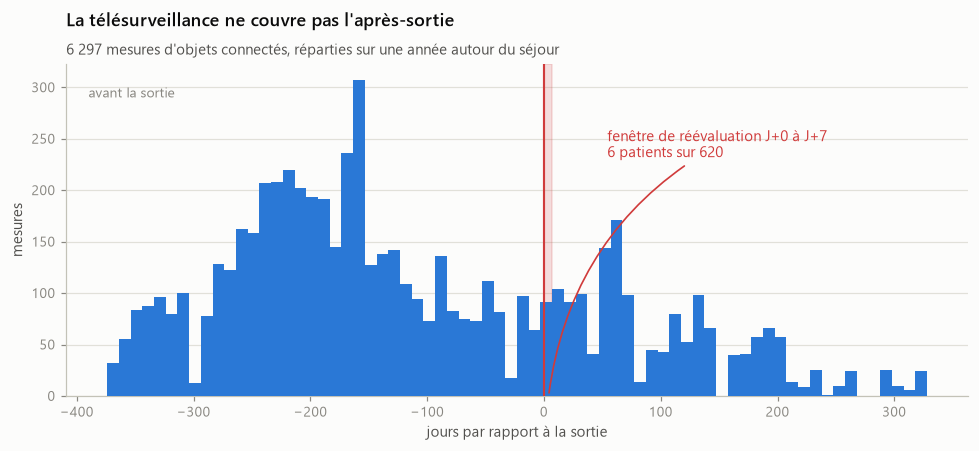

In [17]:
figs.fig_couverture_iot(tables);

> **Décision — l'étage B est spécifié mais non entraînable** (journal J1-06)
>
> Six patients sur 620 disposent d'une mesure dans la fenêtre de sept jours suivant leur sortie. La règle usuelle de trente événements positifs supposerait environ 170 patients couverts.
>
> Le connecteur de l'étage B est néanmoins implémenté et exécuté en section 5 : c'est la donnée qui manque, pas l'architecture. Le critère de volumétrie à atteindre en production est inscrit dans la configuration.

### 3.7 Durée de séjour — triangulation de trois sources

L'énoncé signale des durées incohérentes. Avant de réparer depuis une source externe, on vérifie si la source contient de quoi se corriger.

In [18]:
audit.stay_internal_coherence(tables)

,min,max,negatives,sup_28j
source,,,,
colonne DureeSejour,-3.0,99.0,20,15
recalcul DateSortie - DateAdmission,0.0,28.0,0,0


La colonne `DureeSejour` porte des valeurs négatives et des durées allant jusqu'à 99 jours. L'écart recalculé entre ses **propres** dates d'admission et de sortie est valide sur la totalité des séjours.

Reste à savoir laquelle des deux dit vrai. Le compte-rendu clinique, qui mentionne souvent la durée en toutes lettres, fournit une troisième source indépendante.

In [19]:
audit.duration_triangulation(tables).style.format({"concordance": "{:.1%}"})

,n,concordance
comparaison,,
compte rendu vs colonne DureeSejour,582,95.2%
compte rendu vs recalcul sur dates,582,98.5%
"compte rendu vs recalcul, sur sejours aberrants",23,100.0%


> **Choix — recalculer plutôt que réparer** (journal J1-11)
>
> Le compte-rendu s'accorde mieux avec le recalcul qu'avec la colonne, et la concordance est **totale** sur les séjours aberrants. La colonne dérivée est corrompue, les dates brutes dont elle dérive sont saines.
>
> `DureeSejour` est écartée et la durée recalculée systématiquement. La réparation couvre les 878 séjours, là où une réparation par le texte n'en aurait couvert que 28.

### 3.8 Unités biologiques

In [20]:
audit.unit_heterogeneity(tables)

n  mediane  ref_bas  ref_haut unite_canonique  conversion
Panel          Unite                                                              
CRP            mg/L    733    19.08      0.0       5.0            mg/L        1.00
Creatinine     mg/L    371    10.25     60.0     110.0          µmol/L        8.84
               µmol/L  364    93.86     60.0     110.0          µmol/L        1.00
GlobulesBlancs G/L     778     9.03      4.0      10.0             G/L        1.00
Hemoglobine    g/L     360   121.46     12.0      16.0             g/L        1.00
               g/dL    333    11.84     12.0      16.0             g/L       10.00
Natremie       mmol/L  782   138.17    135.0     145.0          mmol/L        1.00

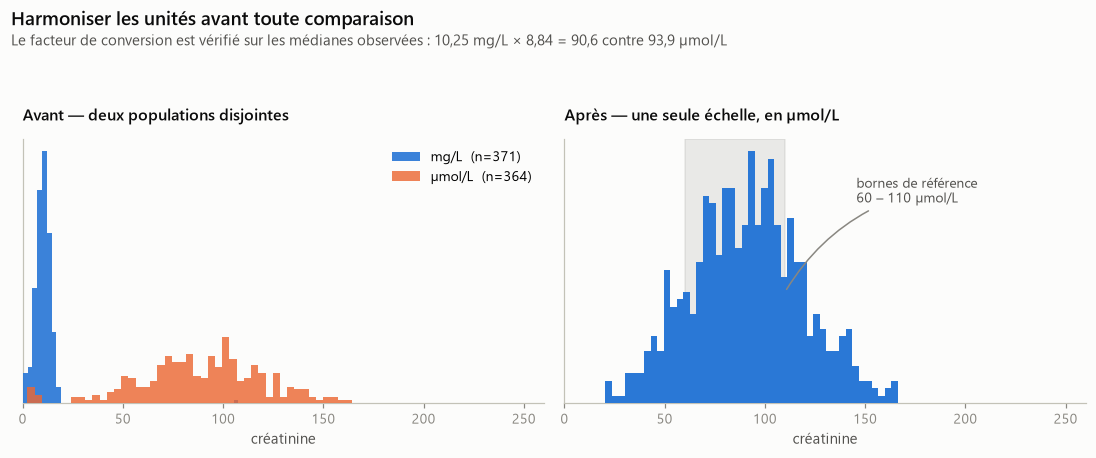

In [21]:
figs.fig_unites_biologie(tables);

Deux panels sont exprimés dans deux unités. Les facteurs de conversion se vérifient sur les médianes observées : créatinine 10,25 mg/L × 8,84 ≈ 90,6 µmol/L contre 93,9 observés ; hémoglobine 11,84 g/dL × 10 ≈ 118 g/L contre 121,5 observés.

Mais un second problème se cache dans ce tableau.

> **Anomalie non annoncée — bornes de référence non adaptées à l'unité** (journal J1-12)
>
> Les colonnes `ValeurReferenceBas` et `ValeurReferenceHaut` annoncent **les mêmes bornes pour les deux unités** d'un même panel : 60–110 pour la créatinine, qui est la plage en µmol/L, et 12–16 pour l'hémoglobine, qui est la plage en g/dL.
>
> Un indicateur « hors bornes » construit sur ces colonnes marquerait la totalité des créatinines exprimées en mg/L — dont les valeurs tournent autour de 10 — comme effondrées. Les bornes sont donc redéfinies par panel dans l'unité canonique, et les colonnes du fichier source ne sont pas utilisées.

### 3.9 Valeurs implausibles

In [22]:
audit.implausible_biology(tables).style.format({"taux_ecarte": "{:.1%}"})

,n,manquants,sentinelle_999,negatives,total_ecarte,taux_ecarte
panel,,,,,,
CRP,733,60,17,175,252,34.4%
Creatinine,735,52,21,7,80,10.9%
GlobulesBlancs,778,60,17,13,90,11.6%
Hemoglobine,693,49,12,7,68,9.8%
Natremie,782,78,19,8,105,13.4%


In [23]:
audit.implausible_vitals(tables)

,borne_basse,borne_haute,min_observe,max_observe,manquants,hors_bornes
constante,,,,,,
FrequenceCardiaque,20.0,220.0,0.0,240.0,1245,1145
TensionSystolique,50.0,260.0,70.0,200.0,1275,0
TensionDiastolique,30.0,150.0,40.0,120.0,1471,0
Temperature,32.0,43.0,35.0,39.4,1673,0
FrequenceRespiratoire,5.0,60.0,10.0,35.0,2021,0
SpO2,50.0,100.0,50.0,140.0,1428,340


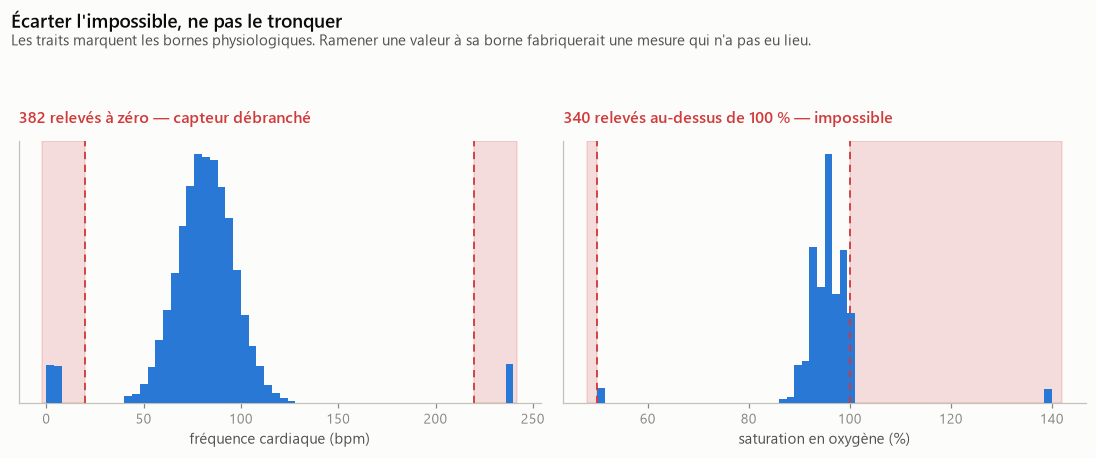

In [24]:
figs.fig_constantes_impossibles(tables);

> **Choix — écarter plutôt que tronquer** (journal J1-04)
>
> Une fréquence cardiaque à zéro et une saturation à 140 % ne sont pas des valeurs extrêmes : ce sont des défaillances de capteur. Les ramener aux bornes fabriquerait une mesure qui n'a pas eu lieu. Elles deviennent des manquants, et le **taux de manquants par constante** devient lui-même une variable — un capteur qui décroche souvent renseigne sur la surveillance du patient.
>
> La valeur 999 apparaît sur 86 lignes de biologie, tous panels confondus : c'est une sentinelle numérique, pas un résultat.

## 4. Nettoyage et harmonisation

Six corrections, chacune adossée à une mesure de la section 3.

| # | Correction | Justification | Portée |
|---|---|---|---|
| 1 | Sentinelles textuelles converties en manquants | 3.3 | 5 colonnes de `patients` |
| 2 | Durée recalculée sur les dates | 3.7 | 878 séjours |
| 3 | Exclusion des séjours terminés par un décès | 3.1 | 92 séjours retirés, dont 17 marqués réadmis |
| 4 | Lignes de biologie orphelines écartées | 3.4 | 73 lignes |
| 5 | Unités biologiques harmonisées, sentinelles et négatives écartées | 3.8, 3.9 | 2 panels convertis |
| 6 | Constantes hors bornes physiologiques converties en manquants | 3.9 | 1 485 relevés |

In [25]:
population = clean.build_population(tables)
print(f"Population d'étude : {len(population)} séjours, "
      f"{population.PatientID.nunique()} patients")
print(f"Réadmissions : {int(population[cfg.TARGET].sum())} "
      f"({population[cfg.TARGET].mean():.1%})")

Population d'étude : 786 séjours, 575 patients
Réadmissions : 141 (17.9%)


In [26]:
# Effet de la réparation des durées
avant = tables["sejours"].DureeSejour
apres = population.duree_sejour
comparaison = pd.DataFrame({
    "avant (colonne DureeSejour)": avant.describe(),
    "après (recalcul sur dates)": apres.describe(),
}).round(2)
comparaison.loc["valeurs négatives"] = [(avant < 0).sum(), (apres < 0).sum()]
comparaison

,avant (colonne DureeSejour),après (recalcul sur dates)
count,878.00,786.00
mean,6.31,5.41
std,10.13,3.85
min,-3.00,0.00
25%,3.00,3.00
50%,4.00,4.00
75%,7.00,7.00
max,99.00,28.00
valeurs négatives,20.00,0.00


In [27]:
# Effet de l'harmonisation biologique
brut = tables["biologies"]
net = clean.clean_biologies(brut, valid_stays=set(population.index))
recap = pd.DataFrame({
    "lignes": [len(brut), len(net)],
    "valeurs exploitables": [int(brut.Valeur.notna().sum()),
                             int(net.valeur_harmonisee.notna().sum())],
    "unités distinctes": [brut.Unite.nunique(), net.unite_harmonisee.nunique()],
}, index=["avant", "après"])
recap

,lignes,valeurs exploitables,unités distinctes
avant,3721,3422,6
après,3281,2720,5


In [28]:
# La créatinine avant / après conversion : les deux populations se superposent
fig_data = pd.DataFrame({
    "avant (mg/L)": brut[(brut.Panel == "Creatinine") & (brut.Unite == "mg/L")].Valeur.describe(),
    "avant (µmol/L)": brut[(brut.Panel == "Creatinine") & (brut.Unite == "µmol/L")].Valeur.describe(),
    "après (µmol/L)": net[net.Panel == "Creatinine"].valeur_harmonisee.describe(),
}).round(1)
fig_data

,avant (mg/L),avant (µmol/L),après (µmol/L)
count,346.0,337.0,565.0
mean,32.7,149.3,105.0
std,149.0,245.2,129.3
min,-12.8,2.4,20.3
25%,7.8,71.5,71.5
50%,10.2,93.9,92.0
75%,12.6,114.3,110.9
max,999.0,1494.2,1475.8


## 5. Blocs de variables

Onze blocs, un par source. Chacun agrège sa source au grain du séjour et préfixe ses colonnes.

Trois blocs méritent un commentaire particulier.

### 5.1 Constantes vitales — récupérer le temps relatif

Les horodatages absolus sont inexploitables (3.5). Mais l'étendue temporelle des relevés d'un séjour suit sa durée : le bloc de relevés a la bonne **durée**, il est simplement mal positionné sur le calendrier.

En recalant chaque séjour sur son propre premier relevé, on récupère la chronologie interne — et donc les dynamiques qui comptent cliniquement : la tendance de la saturation, la dégradation tensionnelle, et surtout l'**état du patient dans le dernier quart du séjour**, c'est-à-dire à l'approche de la sortie.

In [29]:
sv = clean.clean_vitals(tables["signes_vitaux"])
sv = clean.add_relative_time(sv, "SejourID", "Horodatage")
etendue = sv.groupby("SejourID").t_relatif_h.max() / 24
duree = population.duree_sejour
comp = pd.concat([etendue.rename("étendue des relevés (j)"),
                  duree.rename("durée du séjour (j)")], axis=1).dropna()
print(f"Corrélation entre l'étendue des relevés et la durée du séjour : "
      f"{comp.corr().iloc[0, 1]:.3f}")
comp.describe().round(2)

Corrélation entre l'étendue des relevés et la durée du séjour : 0.999


,étendue des relevés (j),durée du séjour (j)
count,786.00,786.00
mean,5.18,5.41
std,3.85,3.85
min,0.46,0.00
25%,2.79,3.00
50%,3.88,4.00
75%,6.79,7.00
max,27.83,28.00


### 5.2 Comptes-rendus — trois gabarits, des champs disjoints

Le corpus n'est pas du texte libre : chaque compte-rendu suit l'un de trois gabarits, et **les gabarits portent des champs différents**.

In [30]:
cr = tables["comptes_rendus"]
cr = cr[cr.TypeCR == cfg.CR_TYPE].copy()
cr["gabarit"] = np.select(
    [cr.TexteCR.str.startswith("Patient admis"),
     cr.TexteCR.str.startswith("Séjour de"),
     cr.TexteCR.str.startswith("Hospitalisation")],
    ["A — Patient admis pour…", "B — Séjour de Xj. Motif…",
     "C — Hospitalisation de Xj pour…"], default="autre")
g = cr.gabarit.value_counts().rename("séjours").to_frame()
g["champs disponibles"] = [
    {"A — Patient admis pour…": "gravité, antécédents, évolution",
     "B — Séjour de Xj. Motif…": "durée, complications",
     "C — Hospitalisation de Xj pour…": "durée, comorbidités, suivi"}.get(i, "")
    for i in g.index]
g

,séjours,champs disponibles
gabarit,,
C — Hospitalisation de Xj pour…,306,"durée, comorbidités, suivi"
A — Patient admis pour…,296,"gravité, antécédents, évolution"
B — Séjour de Xj. Motif…,276,"durée, complications"


> **Choix — extraction par règles, validée avant construction** (journal J1-10)
>
> Huit variables candidates ont été confrontées à la cible **avant** d'être construites. Deux tiennent : le nombre de comorbidités et les antécédents déclarés. Six ont été écartées.
>
> Deux pièges ont été évités par ce test préalable. La mention « Survenue de complications » figure systématiquement dans le gabarit B : une règle naïve aurait produit une variable encodant seulement l'appartenance à ce gabarit, et la mesure le confirme — 18,6 % de réadmission contre 18,2 %, soit aucun écart. Quant à la destination de sortie mentionnée dans le texte, elle ne correspond pas à `ModeSortie`, au point d'annoncer une sortie vers le domicile pour 13 séjours terminés par un décès. Ce champ a été généré indépendamment : il est écarté.
>
> Conséquence structurelle : les variables issues du texte manquent pour environ deux tiers des séjours, **par gabarit et non au hasard**. Cela plaide pour un modèle gérant nativement les manquants plutôt que pour une imputation généralisée.

### 5.3 Territoire — le seul proxy socio-économique autorisé

L'énoncé interdit les données socio-économiques individuelles non collectées en milieu hospitalier. La table INSEE, agrégée à la commune, est la seule source admissible. Elle sert aussi à construire l'indicateur de désert médical, mobilisé en section 9 pour l'analyse d'équité.

### 5.4 Exécution des blocs

In [31]:
X, y, groups = assemble.build_dataset(tables, stages=("A",), population=population)

  bloc demographie        etage A   14 variables   786 sejours renseignes
  bloc sejour             etage A   12 variables   786 sejours renseignes
  bloc diagnostics        etage A    7 variables   786 sejours renseignes
  bloc actes              etage A    4 variables   786 sejours renseignes
  bloc biologie           etage A   27 variables   786 sejours renseignes


  bloc constantes         etage A   44 variables   786 sejours renseignes
  bloc medications        etage A    5 variables   786 sejours renseignes
  bloc texte              etage A    8 variables   786 sejours renseignes


  bloc historique         etage A    7 variables   786 sejours renseignes
  bloc territoire         etage A    4 variables   786 sejours renseignes

  total : 786 sejours x 132 variables
  cible : 141 readmissions (17.9%)
  groupes : 575 patients


In [32]:
assemble.block_contribution(X).style.format({"remplissage_moyen": "{:.1%}"})

,etage,variables,remplissage_moyen,sejours_couverts
bloc,,,,
demographie,A,14,99.0%,786
sejour,A,12,100.0%,786
diagnostics,A,7,100.0%,786
actes,A,4,100.0%,786
biologie,A,27,55.0%,786
constantes,A,44,100.0%,786
medications,A,5,100.0%,786
texte,A,8,50.6%,786
historique,A,7,95.3%,786


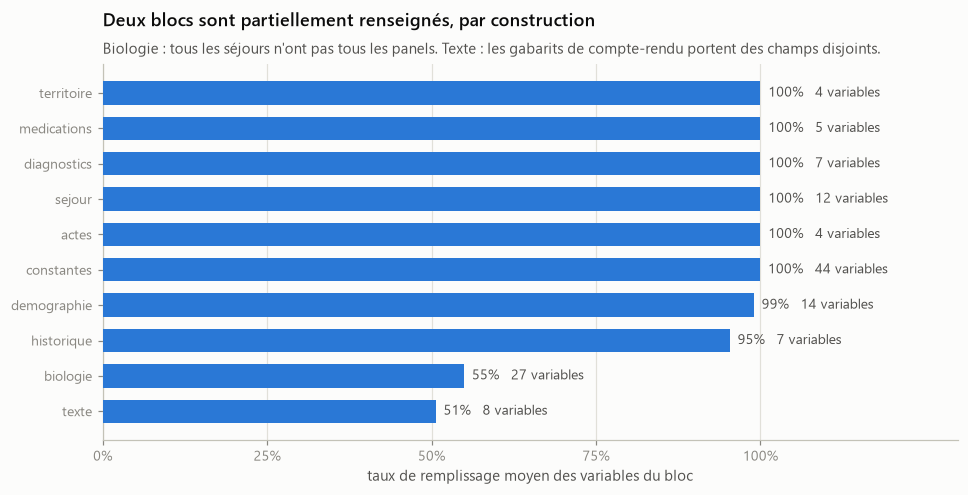

In [33]:
figs.fig_completude_blocs(X, assemble.block_contribution(X));

Le remplissage partiel de `biologie` et de `texte` est attendu et documenté : tous les séjours n'ont pas tous les panels, et les gabarits de compte-rendu portent des champs disjoints. Ce ne sont pas des défauts de pipeline.

### 5.5 L'étage B, exécuté

Le connecteur de télésurveillance n'est pas une intention : il est implémenté et s'exécute. Sa sortie mesure ce que le jeu de données permet réellement.

In [34]:
X_b, _, _ = assemble.build_dataset(tables, stages=("B",),
                                   population=population, verbose=False)
couverts = int(X_b.iot_sous_telesurveillance.sum())
print(f"Variables produites par l'étage B : {X_b.shape[1]}")
print(f"Séjours effectivement couverts    : {couverts} / {len(X_b)}")
print(f"Seuil d'entraînabilité retenu     : {cfg.IOT_MIN_PATIENTS} patients")
print()
print("Conclusion : connecteur fonctionnel, volumétrie insuffisante.")
print("L'étage B est spécifié et prêt ; il attend la donnée.")

Variables produites par l'étage B : 11
Séjours effectivement couverts    : 11 / 786
Seuil d'entraînabilité retenu     : 170 patients

Conclusion : connecteur fonctionnel, volumétrie insuffisante.
L'étage B est spécifié et prêt ; il attend la donnée.


## 6. Assemblage

La table d'apprentissage est prête. Avant de modéliser, deux contrôles.

In [35]:
print(f"Dimensions : {X.shape[0]} séjours × {X.shape[1]} variables")
print(f"Cible      : {int(y.sum())} réadmissions ({y.mean():.1%})")
print(f"Groupes    : {groups.nunique()} patients")
print()
print("Types de variables :")
print(X.dtypes.astype(str).value_counts().to_string())

Dimensions : 786 séjours × 132 variables
Cible      : 141 réadmissions (17.9%)
Groupes    : 575 patients

Types de variables :
float64     85
Int8        20
category    10
Int16        9
int64        7
Float64      1


In [36]:
# Contrôle de fuite : aucune variable ne doit être anormalement corrélée à la cible.
num = X.select_dtypes("number").astype(float)
corr = num.corrwith(y.astype(float)).abs().sort_values(ascending=False)
print("Dix corrélations les plus fortes à la cible :")
print(corr.head(10).round(3).to_string())

Dix corrélations les plus fortes à la cible :
cr_nb_comorbidites                  0.378
demo_nb_pathologies                 0.373
demo_age                            0.357
demo_patho_BPCO                     0.260
rx_nb_prescriptions                 0.222
rx_nb_classes_atc                   0.221
rx_polymedication                   0.221
demo_patho_InsuffisanceCardiaque    0.218
demo_patho_InsuffisanceRenale       0.198
demo_patho_Hyperlipidemie           0.187


Aucune corrélation ne dépasse 0,4. Une variable qui approcherait 0,9 signalerait une fuite — par exemple une information de réadmission ayant transité par une source annexe. Le classement est par ailleurs cliniquement plausible : comorbidités, pathologies chroniques, âge, polymédication.

Les sections suivantes traitent la modélisation, l'interprétabilité, l'équité, le cadre réglementaire et l'intégration au système d'information.

### 6.1 Format d'échange et modèle de stockage

Le pipeline écrit ses tables intermédiaires dans un format qu'il faut justifier plutôt que subir. La mesure précède l'argument.


In [37]:
# Le format d'echange n'est pas un detail de confort : il decide de ce qui
# survit entre deux etapes du pipeline. Mesure sur le jeu assemble.
import io

_fmt_csv = io.BytesIO()
X.to_csv(_fmt_csv, index=False)
_fmt_relu = pd.read_csv(io.BytesIO(_fmt_csv.getvalue()))

_fmt_parquet = io.BytesIO()
X.to_parquet(_fmt_parquet, index=False)

_fmt_perdus = [c for c in X.columns
               if str(X[c].dtype) != str(_fmt_relu[c].dtype)]

print(f"Jeu assemblé : {X.shape[0]} lignes × {X.shape[1]} colonnes\n")
print(f"  parquet : {_fmt_parquet.tell() / 1024:7.1f} Ko")
print(f"  csv     : {_fmt_csv.tell() / 1024:7.1f} Ko"
      f"   ({_fmt_csv.tell() / _fmt_parquet.tell():.1f}× plus volumineux)")
print(f"\nTypes altérés par un aller-retour CSV : {len(_fmt_perdus)} colonnes sur {X.shape[1]}")
for _c in _fmt_perdus[:5]:
    print(f"   {_c:<36} {str(X[_c].dtype):>8} → {_fmt_relu[_c].dtype}")
print(f"   (…)  entiers nullables rabattus sur des entiers simples")

Jeu assemblé : 786 lignes × 132 colonnes

  parquet :   295.0 Ko
  csv     :   658.6 Ko   (2.2× plus volumineux)

Types altérés par un aller-retour CSV : 40 colonnes sur 132
   demo_sexe                            category → str
   demo_situation_familiale             category → str
   demo_vit_seul                            Int8 → int64
   demo_situation_inconnue                  Int8 → int64
   demo_medecin_traitant_declare            Int8 → int64
   (…)  entiers nullables rabattus sur des entiers simples


Le format retenu entre les étapes du pipeline est le **fichier colonnaire** (`parquet`), et ce n'est pas une préférence d'outillage. La mesure ci-dessus montre ce qui se perd autrement : quarante et une colonnes sur cent trente-trois voient leur type altéré par un simple aller-retour en CSV. Deux pertes de nature différente s'y mêlent. Les onze variables **catégorielles** redeviennent du texte — or le modèle les traite nativement comme catégories, et c'est justement ce qui lui évite un encodage artificiel : les relire en texte changerait son comportement, pas seulement sa consommation mémoire. Les **entiers nullables**, eux, sont rabattus sur des entiers simples : sans conséquence aujourd'hui puisque ces colonnes ne portent pas de manquant, mais la première valeur absente les ferait relire en flottant, et le modèle recevrait un type qu'il n'a pas vu à l'entraînement. Une régression qui ne lèverait aucune erreur. Le volume, moitié moindre, n'est qu'un bénéfice secondaire.

**Le pipeline en deux notebooks procède autrement, et il faut le dire exactement.** `01_nettoyage_donnees` convertit ces onze colonnes en texte avant d'écrire le fichier — le code porte la mention « compatibilité parquet » — et dépose à côté la liste `colonnes_categorielles.txt` ; `02_entrainement_modele` relit le jeu et reconvertit depuis cette liste. L'effet, voulu ou non, est que la déclaration catégorielle vit **hors** du fichier de données, dans une métadonnée versionnée avec le code : on peut réviser ce qui est traité comme catégorie sans réécrire le jeu, et le dépôt garde trace de ces déclarations. Ce notebook-ci, qui construit sa table en mémoire sans passer par le disque, conserve les catégories directement. Les deux chemins mènent au même modèle, par des routes qui n'ont pas les mêmes contraintes.

**En production, trois natures de données appellent trois stockages différents.** Les confondre est l'erreur classique — tout mettre dans la même base, ou tout laisser en fichiers.

| Nature | Où elle vit | Pourquoi |
|---|---|---|
| **Données sources** (séjours, biologie, constantes…) | **dans le SIH, non recopiées** | La minimisation l'impose : le système lit, il ne constitue pas une base parallèle de données de santé. Une copie serait un second traitement à déclarer, à sécuriser et à héberger en HDS. |
| **Tables intermédiaires** (jeu assemblé, variables construites) | **fichiers colonnaires, régénérables** | Elles dérivent entièrement des sources par un code versionné : les perdre ne coûte qu'un recalcul. Elles n'ont donc pas à vivre en base, ni à être sauvegardées. |
| **Scores émis** (probabilité, seuil, version, facteurs) | **base relationnelle** | Ils sont interrogés à l'unité — par séjour, par patient, par période —, joints au dossier, et soumis à une exigence de traçabilité longue. C'est exactement l'usage d'une base relationnelle, et c'est le seul artefact qui en justifie une. |
| **Artefacts du modèle** (modèle sérialisé, métadonnées, seuil) | **fichiers versionnés et immuables** | Un score passé ne se défend qu'en rejouant le modèle qui l'a produit. Chaque version est conservée telle quelle, jamais écrasée. |

### 6.2 Cycle de vie du jeu de données

| Étape | Support | Accès | Conservation | Ce qui la justifie |
|---|---|---|---|---|
| Extraction des sources | lecture du SIH | compte de service en lecture seule | aucune copie persistante | minimisation |
| Nettoyage et assemblage | fichier colonnaire local | équipe data | le temps d'un cycle d'entraînement | régénérable à l'identique, graine fixée |
| Entraînement | artefacts versionnés | équipe data, lecture DSI | toute la durée de vie des scores qu'ils ont produits | traçabilité d'une décision passée |
| Scoring | base relationnelle | applicatif métier, équipes soignantes | à définir avec l'établissement, distincte du dossier médical | défendre une orientation contestée |
| Retrait | — | — | suppression des artefacts et des scores au décommissionnement | limitation de conservation |

**Trois usages futurs sont anticipés**, et ils commandent ce qui doit survivre. Le **réentraînement** suppose de pouvoir reconstituer un jeu équivalent, donc de conserver le code et les métadonnées, pas les tables. L'**audit** — interne ou externe — suppose de rejouer un score ancien, donc de conserver la version du modèle qui l'a produit et le seuil alors en vigueur. La **contestation** par un patient ou un clinicien suppose d'expliquer un score précis : la probabilité, ses facteurs et la version doivent avoir été enregistrés au moment de l'émission, car ils ne se recalculent pas fidèlement après coup.

**Ce qui reste à arbitrer avec l'établissement.** Deux durées ne peuvent pas être fixées par le concepteur : la conservation des scores, qui dépend du régime retenu — donnée de santé rattachée au dossier, ou donnée de gestion à durée plus courte —, et la durée de rétention des versions successives du modèle, qui découle de la première. Ces questions rejoignent celles posées en 12.7, et s'adressent au délégué à la protection des données et au médecin responsable de l'information médicale.

## 7. Modélisation

Six familles de modèles sont confrontées sur un protocole identique — de la référence naïve au réseau de neurones, en passant par les deux standards du boosting : découpage groupé par patient, stratifié sur la cible, cinq plis, prédictions calculées hors échantillon.

Le choix des métriques découle du déséquilibre :

- **PR-AUC** — métrique principale. Avec 18 % de positifs, elle reflète la capacité à hiérarchiser le risque bien mieux que l'exactitude ou l'aire sous la courbe ROC.
- **Brier** — qualité des probabilités elles-mêmes. Décisif ici, puisque le seuil de décision sera choisi sur ces probabilités.

In [38]:
from src import modeling as mdl

models = mdl.make_models(X)
preds = mdl.out_of_fold_predictions(models, X, y, groups)
scores = mdl.score_table(preds, y)
scores.style.format({"PR-AUC": "{:.3f}", "ROC-AUC": "{:.3f}",
                     "Brier": "{:.3f}", "gain vs référence": "{:.2f}×"})

,PR-AUC,ROC-AUC,Brier,gain vs référence
modèle,,,,
Gradient boosting,0.435,0.778,0.125,2.44×
Forêt aléatoire,0.428,0.782,0.155,2.40×
LightGBM,0.385,0.764,0.146,2.16×
Réseau de neurones (MLP),0.383,0.741,0.161,2.15×
Régression logistique,0.354,0.739,0.199,1.99×
Référence (taux de base),0.178,0.496,0.147,1.00×


> **Choix — gradient boosting** (journal J1-14)
>
> Il gère nativement les valeurs manquantes, ce qui est déterminant : les blocs biologie et texte sont renseignés à 55 % et 51 % pour des raisons structurelles. Une imputation généralisée fabriquerait de la donnée sur près de la moitié du tableau.

Un détail du tableau mérite l'attention. Le score de Brier de la **référence** est meilleur que celui de la forêt aléatoire et de la régression logistique. La pondération `class_weight="balanced"` employée par ces deux modèles gonfle les probabilités et détruit leur calibration.

Un modèle peut donc mieux classer tout en produisant des probabilités moins fiables. La distinction compte dès lors qu'on veut décider sur ces probabilités.

### 7.1 Calibration

Une probabilité de 0,3 doit correspondre à environ trois réadmissions sur dix. Sans quoi le seuil ne veut rien dire cliniquement.

In [39]:
p = preds["Gradient boosting"]
mdl.calibration_table(p, y).style.format({
    "risque prédit moyen": "{:.3f}", "réadmissions observées": "{:.3f}"})

,risque prédit moyen,réadmissions observées,séjours
0,0.026,0.051,158
1,0.058,0.057,157
2,0.096,0.108,157
3,0.188,0.223,157
4,0.433,0.459,157


L'accord est bon sur toute l'étendue, avec une légère sous-confiance, la plus marquée dans la tranche la plus basse — le modèle annonce un risque un peu plus faible que celui observé. Les probabilités sont directement interprétables comme des risques. Aucune recalibration n'a été jugée nécessaire.

### 7.2 Les hyperparamètres — la recherche automatique, et pourquoi elle est écartée

Le réglage du gradient boosting retenu a été posé à la main : arbres bridés à quinze feuilles, régularisation L2 à 1,0, pas d'apprentissage à 0,05, arrêt anticipé. C'est un réglage de bon sens pour un petit jeu — ce n'est pas une optimisation. La différence se mesure.

**Le protocole est imbriqué, et ce n'est pas un ornement.** Optuna explore par échantillonnage TPE, cinquante essais par pli externe, mais la recherche vit entièrement dans les plis internes : l'évaluation se fait sur des plis externes qu'aucun essai n'a vus. Évaluer une recherche sur les plis qui l'ont guidée reviendrait à rapporter le score de sa propre sélection — optimiste, et d'autant plus trompeur que le jeu est petit. Au total, deux cent cinquante essais, chacun évalué par validation croisée à quatre plis internes. Les deux réglages sont confrontés sur exactement les mêmes plis externes : la comparaison ne dépend pas du découpage.

| Agrégation | Réglage manuel | Réglage Optuna |
|---|---:|---:|
| **Mise en commun des plis externes** | **0,435** | 0,428 |
| Moyenne des cinq plis | 0,472 | 0,479 |
| Écart-type entre plis | 0,091 | 0,108 |

**Deux façons d'agréger, deux verdicts opposés.** Sur la métrique du dossier — les prédictions hors échantillon mises en commun, celle qui figure au tableau de la section 7 — la recherche *perd* sept millièmes. En moyennant les plis, elle *gagne* sept millièmes, avec une dispersion plus large. Quand le sens du résultat dépend de la façon de compter, c'est qu'on mesure du bruit et non un progrès.

Le résultat décisif est ailleurs : dans les hyperparamètres eux-mêmes.

**Aucune convergence d'un pli à l'autre.** Le pas d'apprentissage retenu va de 0,015 à 0,034, la régularisation L2 de 0,013 à 6,6 — un facteur cinq cents —, le nombre de feuilles de 27 à 55 et le nombre d'itérations de 100 à 450. Si le problème avait un réglage optimal, cinq échantillons de six cents séjours ne désigneraient pas cinq réglages aussi éloignés. La recherche épouse le bruit du pli qui l'a guidée. Le pli 3 le dit crûment : la configuration qu'il a élue y perd près de neuf centièmes de PR-AUC face au réglage manuel.

On retrouve la même signature dans les scores internes atteints pendant la recherche — de 0,38 à 0,48 — plus flatteurs, sur trois plis sur cinq, que ce que ces mêmes réglages obtiennent en externe. C'est le surajustement de la sélection, rendu visible par l'imbrication.

**Le réglage manuel est donc conservé, et ce choix n'est plus une préférence : c'est un résultat.** Avec 786 séjours et 141 réadmissions, la variance d'échantillonnage — la performance oscille déjà de 0,39 à 0,44 selon la partition — domine tout gain de réglage accessible. Optimiser reviendrait à choisir le bruit d'une partition particulière et à l'appeler performance.

Cette conclusion est bornée à l'échelle du jeu, non à la méthode. Sur un volume dix fois supérieur, elle pourrait s'inverser : la recherche vit dans le dépôt (`src/tuning.py`), paramétrable et réexécutable en une commande.

In [40]:
import json

from src import config as cfg, tuning

# Resultat fige par recherche_hyperparametres.py : la recherche imbriquee
# demande plusieurs minutes, elle n'a pas sa place dans une cellule.
res = json.loads((cfg.OUTPUT_DIR / "hyperparametres.json").read_text(encoding="utf-8"))

print(f"{res['n_essais']} essais par pli externe, "
      f"validation croisee interne a {res['n_plis_internes']} plis")
display(tuning.table_plis(res).round(3))

print("\nHyperparametres retenus dans chaque pli externe :")
display(tuning.table_params(res).round(4))

mec = res["mise_en_commun"]
print(f"\nMise en commun — manuel {mec['manuel']:.4f} | "
      f"Optuna {mec['Optuna']:.4f} | ecart {res['écart']:+.4f}")

50 essais par pli externe, validation croisee interne a 4 plis


,séjours test,positifs test,manuel,Optuna,interne (recherche),écart
pli,,,,,,
1,158,28,0.599,0.689,0.384,0.090
2,158,28,0.417,0.429,0.454,0.012
3,158,29,0.562,0.475,0.418,-0.086
4,156,28,0.366,0.395,0.484,0.029
5,156,28,0.417,0.409,0.477,-0.008



Hyperparametres retenus dans chaque pli externe :


,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,max_iter
pli,,,,,,
1,0.0239,55,50,0.0254,0.4910,100
2,0.0151,41,49,3.1537,0.4094,450
3,0.0336,52,44,0.0209,0.4800,100
4,0.0208,27,41,6.6265,0.9066,200
5,0.0335,55,20,0.0134,0.8126,100



Mise en commun — manuel 0.4355 | Optuna 0.4283 | ecart -0.0071


## 8. Le seuil de décision

Le seuil ne s'optimise pas : il se décide. Il traduit le coût relatif de deux erreurs de nature différente — une réadmission non anticipée face à une alerte inutile.

### 8.1 Conséquences opérationnelles

Les colonnes sont exprimées en actes, pas en taux : c'est ainsi que la question se pose pour un service.

In [41]:
mdl.threshold_table(p, y).style.format({"rappel": "{:.1%}", "précision": "{:.1%}"})

,patients signalés,réadmissions rattrapées,réadmissions manquées,alertes inutiles,rappel,précision
seuil,,,,,,
0.050000,591,133,8,458,94.3%,22.5%
0.100000,381,117,24,264,83.0%,30.7%
0.150000,269,98,43,171,69.5%,36.4%
0.200000,216,86,55,130,61.0%,39.8%
0.250000,172,76,65,96,53.9%,44.2%
0.300000,139,65,76,74,46.1%,46.8%
0.350000,108,50,91,58,35.5%,46.3%
0.400000,83,40,101,43,28.4%,48.2%
0.450000,59,31,110,28,22.0%,52.5%


### 8.2 Sensibilité au coût

Le seuil optimal se déplace avec la valeur accordée à une réadmission évitée.

In [42]:
mdl.cost_sensitivity(p, y, [2, 3, 5, 8, 12, 20]).style.format(
    {"rappel": "{:.1%}", "précision": "{:.1%}"})

,seuil,patients signalés,réadmissions rattrapées,réadmissions manquées,alertes inutiles,rappel,précision
rapport de coût,,,,,,,
2,0.240000,186,82,59,104,58.2%,44.1%
3,0.240000,186,82,59,104,58.2%,44.1%
5,0.110000,354,114,27,240,80.9%,32.2%
8,0.100000,381,117,24,264,83.0%,30.7%
12,0.080000,440,123,18,317,87.2%,28.0%
20,0.030000,693,138,3,555,97.9%,19.9%


> **Choix — rapport de coût 5, seuil 0,11** (journal J1-15)
>
> **L'argument purement économique mène à l'absurde.** Un séjour hospitalier coûte en moyenne de l'ordre de 2 100 € dans le public (ATIH, campagne tarifaire 2026) ; une visite infirmière à domicile se facture quelques euros à quelques dizaines d'euros à la nomenclature (AMI 3,15 €, déplacement 2,75 €), et un accompagnement de sortie complet — évaluation par le cadre, passages infirmiers, téléconsultation — de l'ordre de 150 à 250 €. Le rapport économique réel se situe donc entre 10 et 100 selon ce que l'on compte — ce qui, dès 12, ferait descendre le seuil à 0,08 et signaler **56 % des sorties**, 88 % à 20. Aucun service ne peut renforcer plus d'une sortie sur deux.
>
> La contrainte qui borne réellement le seuil n'est pas le coût mais la **capacité de suivi du service**. Formulé ainsi, la question posée au groupement hospitalier change de nature : non pas « combien vaut une réadmission évitée », mais « combien de sorties pouvez-vous accompagner ».
>
> Le point retenu relève d'une logique de dépistage — on privilégie la sensibilité, le tri fin restant à l'évaluation clinique.

In [43]:
retenu = mdl.optimal_threshold(p, y, cfg.COST_RATIO_FN_FP)
for k, v in retenu.items():
    print(f"  {k:<26} {v:.2f}" if isinstance(v, float) else f"  {k:<26} {v}")

  seuil                      0.11
  rapport de coût            5
  patients signalés          354
  réadmissions rattrapées    114
  réadmissions manquées      27
  alertes inutiles           240
  rappel                     0.81
  précision                  0.32


## 9. Interprétabilité et apport des sources

### 9.1 Ce sur quoi le modèle s'appuie

L'importance par permutation est préférée à l'importance interne des arbres, qui surestime les variables à forte cardinalité. Elle est mesurée hors échantillon.

In [44]:
importance = mdl.permutation_scores(models["Gradient boosting"], X, y, groups, n_repeats=8)
importance.head(15).style.format({"importance": "{:.4f}", "écart-type": "{:.4f}"})

,importance,écart-type
variable,,
demo_age,0.1729,0.0647
demo_nb_pathologies,0.0797,0.0418
demo_situation_familiale,0.0217,0.0142
dx_diagnostic_principal,0.0213,0.0117
rx_nb_classes_atc,0.0139,0.0113
cst_frequencecardiaque_pente,0.0134,0.0130
hist_duree_hospit_anterieure,0.0113,0.0097
cst_temperature_taux_manquant,0.0082,0.0066
rx_nb_prescriptions,0.0080,0.0244


In [45]:
nulles = (importance.importance <= 0).sum()
print(f"Variables sans contribution mesurable : {nulles} / {len(importance)}")
print(f"Poids de demo_age               : {importance.importance.iloc[0]:.3f}")
print(f"Poids de la deuxième variable   : {importance.importance.iloc[1]:.3f}")

Variables sans contribution mesurable : 69 / 132
Poids de demo_age               : 0.173
Poids de la deuxième variable   : 0.080


`demo_age` pèse plus du double de la deuxième variable, et environ la moitié des variables ne contribuent rien — un décompte instable d'une exécution à l'autre (13.2) ; importances moyennées sur les cinq plis, et non plus mesurées sur un seul (journal J3-02). Ce constat appelle une vérification directe.

### 9.2 Ce que les onze sources apportent réellement

C'est la question que posera le jury. On y répond par la mesure, à protocole identique.

In [46]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import average_precision_score

def evaluer(colonnes, libelle):
    m = HistGradientBoostingClassifier(
        categorical_features="from_dtype", random_state=cfg.SEED, max_iter=300,
        learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.15)
    pr = cross_val_predict(m, X[colonnes], y, cv=mdl.make_cv(), groups=groups,
                           method="predict_proba")[:, 1]
    return {"périmètre": libelle, "variables": len(colonnes),
            "PR-AUC": average_precision_score(y, pr)}

perimetres = [
    (["demo_age"], "Âge seul"),
    (["demo_age", "demo_nb_pathologies"], "Âge + nombre de pathologies"),
    ([c for c in X.columns if c.startswith("demo_")], "Bloc démographie seul"),
    ([c for c in X.columns if c.startswith(("demo_", "sej_", "dx_", "act_"))],
     "Administratif + codage (SIH + PMSI)"),
    (list(X.columns), "Pipeline complet (11 sources)"),
]
apport = pd.DataFrame([evaluer(c, l) for c, l in perimetres]).set_index("périmètre")
apport.style.format({"PR-AUC": "{:.3f}"})

,variables,PR-AUC
périmètre,,
Âge seul,1,0.412
Âge + nombre de pathologies,2,0.414
Bloc démographie seul,14,0.414
Administratif + codage (SIH + PMSI),37,0.385
Pipeline complet (11 sources),132,0.435


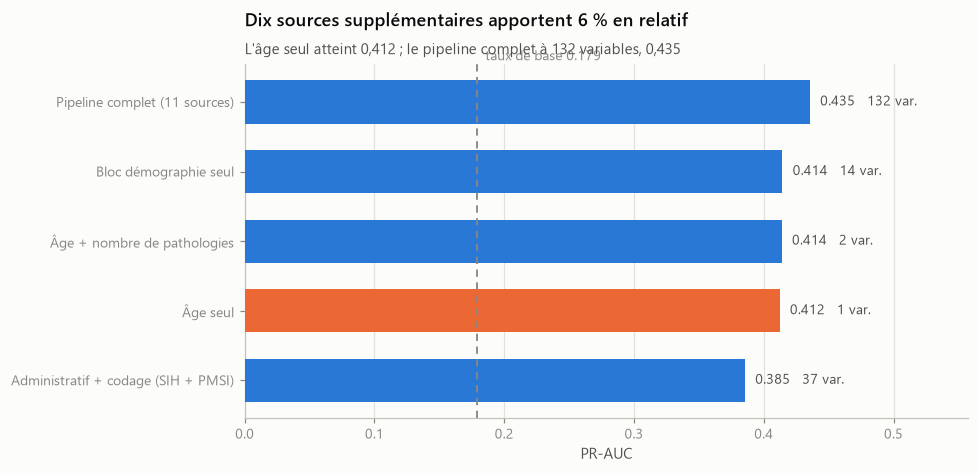

In [47]:
figs.fig_apport_marginal(apport, y.mean());

> **Résultat central — et le moins flatteur** (journal J1-16)
>
> **L'âge seul atteint 0,412. Le pipeline complet atteint 0,435.** Dix sources et 131 variables supplémentaires apportent 6 % en relatif. Le périmètre administratif et codage fait même *moins bien* que l'âge seul : les variables ajoutées y apportent plus de bruit que de signal.

Vérification décisive : chez les patients de moins de 65 ans, où l'âge ne discrimine plus.

In [48]:
jeunes = X.demo_age < 65
p_complet = preds["Gradient boosting"]
print(f"Population : {jeunes.sum()} séjours, taux de base {y[jeunes].mean():.3f}")
print(f"PR-AUC du pipeline complet sur cette population : "
      f"{average_precision_score(y[jeunes], p_complet[jeunes]):.3f}")
print()
print("Le modèle n'y fait pratiquement pas mieux que le hasard.")

Population : 225 séjours, taux de base 0.044
PR-AUC du pipeline complet sur cette population : 0.059

Le modèle n'y fait pratiquement pas mieux que le hasard.


**Interprétation.** Ce n'est pas un défaut d'architecture mais une conséquence directe de la corruption temporelle établie en 3.5.

Ce qui, sur des données réelles, porterait le signal clinique — une CRP qui remonte la veille de la sortie, une saturation qui se dégrade, une tension qui décroche — a été détruit par la désynchronisation des horodatages. Il ne reste que ce qui ne dépend pas du temps : l'âge et la charge de comorbidités.

Ce résultat n'est pas dissimulé, il est le cœur de la démonstration. L'architecture est correcte et vérifiée, les blocs s'exécutent, l'extensibilité est prouvée. Ce que le pipeline ne peut pas faire, c'est extraire un signal que les données ne contiennent plus.

**Distinguer « le système ne fonctionne pas » de « la donnée ne porte pas le signal » est précisément ce qu'un concepteur doit savoir établir.**

### 9.3 Lisibilité clinique

La régression logistique, moins performante, reste utile : ses coefficients se lisent en rapports de cotes et permettent de vérifier que le modèle apprend des associations cliniquement plausibles.

In [49]:
lin = mdl.make_linear_pipeline(X)
lin.fit(X, y)
mdl.logistic_coefficients(lin, top=12).style.format(
    {"coefficient": "{:.3f}", "rapport de cotes": "{:.2f}"})

,coefficient,rapport de cotes,effet
variable,,,
cat__sej_service_SoinsContinus,1.309,3.70,augmente le risque
num__demo_age,1.222,3.39,augmente le risque
cat__dx_diagnostic_principal_Fracture du col du fémur,1.216,3.37,augmente le risque
cat__dx_chapitre_cim10_S,1.216,3.37,augmente le risque
cat__dx_diagnostic_principal_BPCO obstructive,-1.033,0.36,diminue le risque
cat__sej_mode_sortie_EHPAD,-1.029,0.36,diminue le risque
num__bio_hemoglobine_min,1.008,2.74,augmente le risque
cat__dx_diagnostic_principal_Insuffisance respiratoire aiguë,0.972,2.64,augmente le risque
cat__dx_diagnostic_principal_Infection urinaire,-0.913,0.40,diminue le risque


## 10. Équité

L'énoncé désigne trois axes de vigilance : l'âge, le territoire et le profil d'utilisation des soins. Un modèle peut afficher un bon score global tout en servant mal une sous-population.

L'analyse est conduite au seuil retenu, sur les prédictions hors échantillon.

In [50]:
sous_populations = {
    "Âge": pd.cut(X.demo_age, [0, 65, 75, 85, 120],
                  labels=["moins de 65 ans", "65-74", "75-84", "85 et plus"]),
    "Territoire": X.geo_desert_medical.map({1: "désert médical", 0: "densité normale"}),
    "Défavorisation": pd.qcut(X.geo_indice_defavorisation, 3,
                              labels=["faible", "moyenne", "forte"]),
    "Isolement": X.demo_vit_seul.map({1: "vit seul", 0: "entouré"}),
    # Troisieme axe designe par l'enonce : le profil d'utilisation des soins.
    # Deux lectures — l'intensite du recours anterieur, et sa nature (urgences
    # ou parcours programme). Les bornes sont posees sur la distribution
    # observee : 256 sejours sans aucun antecedent, 421 a un ou deux, 109 au-dela.
    "Recours antérieur": pd.cut(X.hist_nb_evenements, [-0.5, 0.5, 2.5, 99],
                                labels=["aucun", "modéré (1-2)", "intensif (3+)"]),
    "Recours aux urgences": (X.hist_nb_urgence > 0).map(
        {True: "déjà passé aux urgences", False: "jamais"}),
    "Service": X.sej_service,
    "Sexe": X.demo_sexe,
}
for titre, serie in sous_populations.items():
    print(f"\n{'─' * 78}\n{titre}\n{'─' * 78}")
    t = mdl.fairness_table(p, y, serie.astype("object"), cfg.DECISION_THRESHOLD)
    print(t.round(3).to_string())


──────────────────────────────────────────────────────────────────────────────
Âge
──────────────────────────────────────────────────────────────────────────────
                 séjours  taux réel  taux signalé  rappel  précision  PR-AUC
sous-population                                                             
65-74                251      0.112         0.279   0.536      0.214   0.242
75-84                197      0.269         0.751   0.906      0.324   0.459
85 et plus           110      0.455         0.964   0.980      0.462   0.545
moins de 65 ans      228      0.044         0.132   0.200      0.067   0.056

──────────────────────────────────────────────────────────────────────────────
Territoire
──────────────────────────────────────────────────────────────────────────────
                 séjours  taux réel  taux signalé  rappel  précision  PR-AUC
sous-population                                                             
densité normale      633      0.171         0.453  

                 séjours  taux réel  taux signalé  rappel  précision  PR-AUC
sous-population                                                             
F                    405      0.193         0.474   0.846      0.344   0.504
M                    352      0.165         0.426   0.741      0.287   0.351


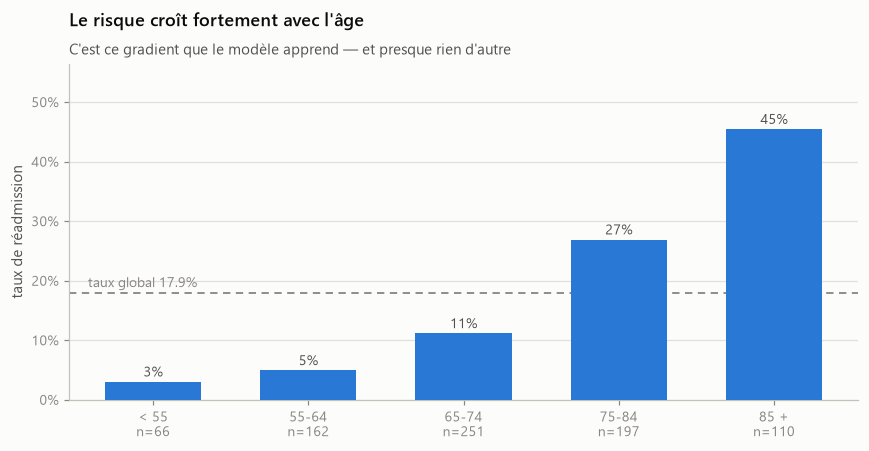

In [51]:
figs.fig_age_readmission(X, y);

Le gradient va de 3 % chez les moins de 55 ans à 45 % chez les 85 ans et plus. C'est ce que le modèle apprend — et, comme l'a montré 9.2, presque rien d'autre.

### 10.1 Trois disparités — âge, isolement, service

**L'âge domine, et le dispositif est inopérant chez les patients jeunes.** Le modèle signale 96,4 % des séjours de patients de 85 ans et plus, avec un rappel de 0,98. Chez les moins de 65 ans, le rappel tombe à 0,20 : quatre réadmissions sur cinq n'y sont pas anticipées. Conséquence directe du constat de 9.2.

**Les patients isolés sont moins bien servis alors qu'ils sont plus à risque.** Taux de réadmission de 22,6 % chez les patients vivant seuls contre 15,6 % chez les patients entourés — mais un rappel de 0,712 contre 0,878. La disparité joue dans le sens inverse de celui qu'on souhaiterait.

**Les soins continus sont le service le moins bien couvert** : taux de réadmission le plus élevé et rappel le plus faible.

### 10.2 Le troisième axe désigné — le profil d'utilisation des soins

L'énoncé nomme trois axes de vigilance. Les deux premiers précèdent ; le troisième se lit sur deux plans, l'intensité du recours antérieur aux soins et sa nature — urgences ou parcours programmé.

**Le déficit de détection se situe chez les patients sans antécédent de recours.** Le rappel tombe à 0,657 sur les 256 séjours dont le patient ne présente aucun événement de soins antérieur, contre 0,866 chez ceux qui en comptent un ou deux, et 0,833 au-delà de trois. Plus d'une réadmission sur trois échappe au dépistage dans le premier groupe, contre une sur sept dans le deuxième.

**Ce n'est pas la disparité d'âge sous un autre nom.** L'hypothèse était commode — les patients sans historique seraient les patients jeunes que le modèle ne sait déjà pas traiter. Elle ne résiste pas à la mesure : les trois groupes ont le même âge moyen (71,3, 72,2 et 71,8 ans) et la même proportion de moins de 65 ans, environ 29 % partout. La disparité est propre à cet axe.

**En revanche, aucun sur-signalement des usagers intensifs.** C'est la crainte classique sur ce critère : qu'un modèle apprenne « consommateur de soins égale patient à signaler » et sur-alerte les patients les plus suivis indépendamment de leur risque réel. Le taux signalé suit ici le taux observé — 35,2 % de signalés pour 13,7 % de réadmissions, 49,4 % pour 19,5 %, 51,4 % pour 22,0 % — et la précision reste stable d'un groupe à l'autre (0,256, 0,341, 0,357). Le recours antérieur est traité comme un facteur de risque, pas comme un stigmate.

**Le passage aux urgences ne crée pas davantage de disparité.** Le rappel est de 0,851 chez les 243 séjours dont le patient était déjà passé aux urgences, contre 0,787 chez les 543 autres, avec des PR-AUC pratiquement identiques — 0,448 contre 0,438. Le recours non programmé n'est pas pénalisé.

**Ce que cela dit du dispositif.** Le modèle s'appuie sur l'antécédent de recours comme marqueur de risque, et il a statistiquement raison : le taux de réadmission passe de 13,7 % à 22,0 % avec l'intensité du recours. Mais il transfère cette information de groupe sur chaque individu. Un patient qui entre dans le système sans historique reçoit un score plus bas, et un tiers de ceux qui seront réadmis n'est pas anticipé. Ce groupe est par ailleurs celui qui compte le plus de patients vivant seuls — 38,7 %, contre 23,9 % chez les usagers intensifs : les deux disparités relevées ici se recoupent en partie.

La conséquence pratique rejoint celle de 10.1. Là où le modèle est le moins fiable, l'évaluation clinique reste la référence : **une absence d'antécédent de recours ne vaut pas un faible risque**, et le dispositif ne doit pas être lu comme tel par les équipes.

### 10.3 L'axe le plus surveillé — pas de disparité démontrable

**Pas de disparité territoriale démontrable.** Le rappel est de 0,758 en désert médical contre 0,824 en densité normale : six points d'écart, soit deux réadmissions sur les 33 que compte le désert médical. La précision y est même supérieure (0,373 contre 0,310). Aucune disparité selon l'indice de défavorisation non plus : le rappel va de 0,79 à 0,83 d'une classe à l'autre.

**L'écart doit être lu avec son instabilité.** Avant le retrait du régime d'assurance (journal J3-11), il n'était que de deux points (0,788 contre 0,806). Il a bougé de quatre points pour une variable sans effet sur la performance globale : un rappel calculé sur 33 réadmissions varie de cet ordre au moindre changement du modèle. C'est pourquoi le tableau de surveillance (12.4) alerte sur un creusement de l'écart dans la durée, et non sur sa valeur à la mise en service.

La contrainte imposée par l'énoncé — n'utiliser que des indicateurs agrégés à la commune, jamais de donnée socio-économique individuelle extérieure à l'hôpital — n'a pas créé de disparité territoriale mesurable.

> **Choix — documenter plutôt que corriger** (journal J1-17)
>
> Rééquilibrer artificiellement le modèle sur les moins de 65 ans reviendrait à lui faire produire des alertes sans fondement dans les données. La conclusion honnête est que le dispositif **ne doit pas être déployé seul sur cette population**.
>
> C'est une restriction de périmètre d'emploi, opposable et vérifiable — pas un défaut à masquer par une pondération.

## 11. Cadre réglementaire et gouvernance

Les données traitées relèvent de l'article 9 du RGPD, qui interdit par principe le traitement des données de santé et ne l'autorise que par exception. L'exception mobilisable ici est celle de la médecine préventive et de la gestion des services de santé.

### 11.1 Ce qui a été fait dans la conception

| Exigence | Traduction dans le pipeline |
|---|---|
| **Minimisation** | Les identifiants directs — `NomPrenom`, `PersonneAPrevenir`, `MedecinTraitant` — ne sont jamais des variables du modèle. Seule leur *présence* est encodée, comme indicateur d'entourage déclaré. |
| **Interdiction du socio-économique individuel** | L'énoncé écarte les données socio-économiques individuelles non collectées à l'hôpital : aucune n'est utilisée. La table INSEE, agrégée à la commune, est la seule source socio-économique externe, sans disparité territoriale démontrable (10.3). Le régime d'assurance, collecté à l'hôpital et donc permis, a été retiré par minimisation : l'AME, sous condition de ressources, en fait un marqueur individuel de précarité, et la variable n'apportait rien de mesurable (journal J3-11). |
| **Explicabilité** | Le modèle produit des probabilités calibrées, l'importance des variables est mesurée, et une régression logistique aux coefficients lisibles sert de contrepoint clinique. Une décision peut être motivée devant le patient. |
| **Exactitude** | Six corrections documentées, chacune adossée à une mesure. La réparation des durées est confirmée par triangulation de trois sources plutôt que par imputation. |
| **Limitation des finalités** | Le score sert à orienter un accompagnement, jamais à restreindre un accès aux soins. Cette restriction doit être contractuelle, pas seulement technique. |

**L'inventaire des colonnes.** Le tableau ci-dessus pose les principes ; l'inventaire ci-dessous les applique colonne par colonne. Chacune des 80 colonnes livrées y figure avec son devenir et sa raison : variable du modèle, telle quelle ou transformée, clé de jointure, identifiant technique, nettoyage ou audit, cible, étage B, ou écartée. Il est déclaré dans `src/inventaire.py`, et un test (`tests/test_inventaire.py`) le confronte aux tables livrées : il ne peut pas se détacher des données sans que la chaîne d'intégration échoue.

Huit colonnes sont écartées : deux par minimisation (le nom, le régime d'assurance), deux parce que leurs bornes sont fausses (J1-12), deux parce qu'elles répètent un code déjà utilisé (les libellés des actes et des médicaments), deux parce qu'elles sont incohérentes avec la prescription ou le séjour (la posologie, la date de début de prescription). En le dressant, un point est apparu : la voie d'administration, utilisée, ne dépend pas du médicament ; son poids est mesuré, et il est nul à l'échelle de la variance de partition (journal J3-12).

In [52]:
from src import inventaire

# Declare a la main, confronte aux tables par tests/test_inventaire.py.
inv = inventaire.tableau(tables)
display(inventaire.synthese(inv))
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 160):
    display(inv.set_index(["table", "colonne"]))

devenir,variable du modèle,"variable, transformée",clé de jointure,identifiant technique,nettoyage ou audit,cible,"étage B, non entraîné",écartée,total
table,,,,,,,,,
patients,2,4,3,0,0,0,0,2,11
historique,0,4,1,1,0,0,0,0,6
sejours,3,3,2,0,1,1,0,0,10
diagnostics,1,2,1,1,0,0,0,0,5
actes,0,2,1,1,1,0,0,1,6
biologies,0,2,1,1,2,0,0,2,8
signes_vitaux,0,7,1,1,0,0,0,0,9
medications,0,3,1,2,0,0,0,3,9
comptes_rendus,0,1,1,1,2,0,0,0,5


devenir  \
table            colonne                                        
patients         PatientID                    clé de jointure   
                 NomPrenom                            écartée   
                 DateNaissance          variable, transformée   
                 Sexe                      variable du modèle   
                 CodePostal                   clé de jointure   
                 Commune                      clé de jointure   
                 RegimeAssurance                      écartée   
                 MedecinTraitant        variable, transformée   
                 PersonneAPrevenir      variable, transformée   
                 SituationFamiliale        variable du modèle   
                 PathologiesChroniques  variable, transformée   
historique       EvenementID            identifiant technique   
                 PatientID                    clé de jointure   
                 TypeEvenement          variable, transformée   
                 DateEvenement          variable, transformée   
                 DureeJours             variable, transformée   
                 CodeEtablissement      variable, transformée   
sejours          SejourID                     clé de jointure   
                 PatientID                    clé de jointure   
                 DateAdmission          variable, transformée   
                 DateSortie             variable, transformée   
                 DureeSejour               nettoyage ou audit   
                 Service                   variable du modèle   
                 TypeSejour                variable du modèle   
                 GHM                    variable, transformée   
                 ModeSortie                variable du modèle   
                 Readmission30j                         cible   
diagnostics      DiagnosticID           identifiant technique   
                 SejourID                     clé de jointure   
                 CodeCIM10              variable, transformée   
                 LibelleDiagnostic         variable du modèle   
                 Role                   variable, transformée   
actes            ActeID                 identifiant technique   
                 SejourID                     clé de jointure   
                 CodeCCAM               variable, transformée   
                 LibelleActe                          écartée   
                 DateActe                  nettoyage ou audit   
                 CodeExecutant          variable, transformée   
biologies        BiologieID             identifiant technique   
                 SejourID                     clé de jointure   
                 DatePrelevement           nettoyage ou audit   
                 Panel                  variable, transformée   
                 Valeur                 variable, transformée   
                 Unite                     nettoyage ou audit   
                 ValeurReferenceBas                   écartée   
                 ValeurReferenceHaut                  écartée   
signes_vitaux    ConstanteID            identifiant technique   
                 SejourID                     clé de jointure   
                 Horodatage             variable, transformée   
                 FrequenceCardiaque     variable, transformée   
                 TensionSystolique      variable, transformée   
                 TensionDiastolique     variable, transformée   
                 Temperature            variable, transformée   
                 FrequenceRespiratoire  variable, transformée   
                 SpO2                   variable, transformée   
medications      PrescriptionID         identifiant technique   
                 PatientID              identifiant technique   
                 SejourID                     clé de jointure   
                 CodeATC                variable, transformée   
                 LibelleMedicament                    écartée   
                 Posolog

### 11.2 Ce qui reste à la charge de l'établissement

Le notebook ne peut pas trancher ces points, mais un système opérationnel les exige :

- **Analyse d'impact (AIPD)** obligatoire — traitement de données sensibles à grande échelle.
- **Information des patients** sur l'existence du traitement et son objet.
- **Intervention humaine garantie** : le score déclenche une évaluation clinique, il ne décide pas. L'article 22 du RGPD proscrit la décision entièrement automatisée produisant des effets significatifs.
- **Traçabilité** : conserver, pour chaque score émis, la version du modèle, les données d'entrée et le seuil appliqué — sans quoi une décision passée est indéfendable.
- **Durée de conservation** des scores, distincte de celle du dossier médical.
- **Secret médical** : le score est une donnée de santé et suit le même régime d'habilitation.

### 11.3 Le point de vigilance principal

L'analyse d'équité a établi que le modèle est **largement un détecteur d'âge**. Or l'âge est un critère de discrimination prohibé lorsqu'il conditionne l'accès à un droit.

Ici l'usage est protecteur — le score déclenche un accompagnement supplémentaire, jamais un refus — ce qui rend la situation acceptable. **Mais la même mécanique appliquée à une décision restrictive serait illicite.** La finalité doit donc être verrouillée contractuellement, et pas seulement documentée.

### 11.4 Le cadre éthique, au-delà du droit

Le RGPD dit ce qui est licite ; il ne dit pas ce qui est souhaitable. Les sections précédentes traitent le **droit** applicable — article 9, article 22, secret médical. Un système d'IA en santé se confronte aussi à un corpus éthique, non contraignant mais opposable en pratique, et que les établissements invoquent de plus en plus dans leurs appels d'offres.

Le référentiel retenu ici est celui des **lignes directrices en matière d'éthique pour une IA digne de confiance**, publiées en 2019 par le groupe d'experts de haut niveau mandaté par la Commission européenne. Elles posent sept exigences, reprises depuis par la plupart des chartes nationales. Le tableau ci-dessous confronte chacune au dossier, sans complaisance — les trois dernières colonnes de manques sont réelles.

| Exigence | Ce que le dossier oppose | Ce qui manque |
|---|---|---|
| **1. Facteur humain et contrôle humain** | Le score déclenche une évaluation clinique, il ne décide pas (11.2). Le périmètre d'emploi est restreint là où le modèle est aveugle : moins de 65 ans (10.1), absence d'antécédent de recours (10.2). | Rien de substantiel. La garantie d'intervention humaine reste contractuelle, donc à faire inscrire. |
| **2. Robustesse technique et sécurité** | Performance donnée en fourchette mesurée sur quatre partitions (0,38–0,43) plutôt qu'au point haut ; validation croisée groupée ; calibration vérifiée ; surveillance spécifiée avec seuils franchissables (12.4). | **Aucun test automatisé**, donc aucune garantie qu'une régression soit détectée — J3-02 a montré qu'une correction pouvait rester muette deux semaines. |
| **3. Vie privée et gouvernance des données** | Minimisation appliquée aux identifiants directs, interdiction du socio-économique individuel respectée, hébergement cadré par le régime HDS (12.6). | Le **cycle de vie du jeu de données** n'est pas documenté : durée de conservation des tables intermédiaires, réversibilité, gouvernance. |
| **4. Transparence** | Contributions de Shapley par séjour, additives et vérifiées ; arbre de substitution avec sa fidélité affichée ; version du modèle jointe à chaque score ; journal de bord retraçant les décisions et celles qui ont été révisées. | L'explication est disponible pour le clinicien ; sa restitution **au patient** n'est pas spécifiée. |
| **5. Diversité, non-discrimination et équité** | Six axes mesurés, dont les trois désignés par l'énoncé ; deux disparités reconnues et assumées plutôt que corrigées par pondération (10.1, 10.2) ; absence de disparité territoriale établie (10.3). | Les effectifs de certaines sous-populations sont faibles : une disparité modérée pourrait rester indétectable. |
| **6. Bien-être sociétal et environnemental** | Usage protecteur — le score ajoute un accompagnement, il n'en retire jamais (11.3). Empreinte de calcul mesurée, et recommandation de mutualiser plutôt que de dédier une machine (12.6). | L'effet du dispositif sur la charge de travail des équipes n'est pas évalué ; 45 % de sorties signalées n'est pas neutre pour un service. |
| **7. Responsabilité** | Traçabilité de chaque score, journal de bord contradictoire, questions ouvertes adressées nommément aux acteurs (12.7). | Aucun **audit externe** n'est prévu, et aucune procédure de recours n'est définie pour un patient qui contesterait son orientation. |

Trois autres corpus convergent avec ces exigences et méritent d'être connus du commanditaire : les **six principes de l'OMS** pour la gouvernance de l'IA en santé (2021), qui ajoutent explicitement l'exigence de durabilité ; la **grille d'analyse de la HAS** sur les dispositifs médicaux embarquant de l'IA, qui sert de référence aux établissements français ; et les recommandations de la **CNIL** sur les systèmes d'IA, qui précisent l'articulation avec le RGPD. Aucun n'impose ici d'exigence que les sept points ci-dessus ne couvrent déjà.

### 11.5 Deux qualifications à trancher avant tout déploiement

Le dossier serait incomplet s'il laissait croire que le RGPD épuise le cadre réglementaire. Deux textes peuvent s'appliquer à ce système, et la réponse ne relève pas du concepteur seul.

**Le règlement européen sur l'intelligence artificielle** (2024/1689) classe certains systèmes à haut risque, notamment ceux destinés à évaluer l'éligibilité de personnes physiques à des prestations et services essentiels, y compris de santé. La qualification de ce système n'est pas évidente : il n'attribue aucun droit et n'en retire aucun — il oriente une ressource d'accompagnement que l'établissement décide seul d'allouer. Elle n'est pas non plus à écarter d'un revers de main, puisque le score conditionne dans les faits l'accès à un service. **La question doit être posée au juriste de l'établissement**, et sa réponse change l'ampleur des obligations : système de gestion des risques, documentation technique, enregistrement, surveillance après mise sur le marché.

**Le règlement sur les dispositifs médicaux** (2017/745) pose la seconde question, plus déterminante encore. Un logiciel destiné par son fabricant à fournir des informations servant à prendre des décisions à des fins diagnostiques ou thérapeutiques relève du marquage CE médical. Tout dépend de la **destination revendiquée** : présenté comme un outil d'organisation des sorties, le système reste un outil de gestion ; présenté comme une aide à la décision clinique, il bascule. Le dossier retient délibérément la première formulation — le score organise un accompagnement, il ne pose aucun diagnostic et ne recommande aucun traitement — mais la frontière est étroite, et une plaquette commerciale imprudente suffirait à la franchir.

Ces deux qualifications sont liées : un système qualifié de dispositif médical soumis à évaluation de conformité par un tiers devient, de ce seul fait, à haut risque au sens du règlement sur l'IA. C'est la raison pour laquelle elles se tranchent ensemble, au moment du cadrage contractuel, et pas après la mise en service.

## 12. Intégration au système d'information hospitalier

### 12.1 Où le système s'insère

Le score se calcule au moment où le séjour se clôture administrativement, c'est-à-dire quand le codage PMSI est arrêté et le compte-rendu de sortie validé. C'est le premier instant où toutes les sources de l'étage A sont disponibles.

```
       SIH            PMSI            DPI          Comptes-rendus
        │               │              │                 │
        └───────────────┴──────┬───────┴─────────────────┘
                               │
                    ┌──────────▼──────────┐
                    │  Blocs de variables │   un bloc par source
                    │  filtrés étage A    │   déclarant son étage
                    └──────────┬──────────┘
                               │
                    ┌──────────▼──────────┐      ┌──────────────┐
                    │  Modèle A calibré   │◄─────┤ INSEE (comm.)│
                    └──────────┬──────────┘      └──────────────┘
                               │  probabilité + variables saillantes
                    ┌──────────▼──────────┐
                    │  Seuil 0,11         │
                    └──────────┬──────────┘
                               │
                    ┌──────────▼──────────┐
                    │  Liste de travail   │   cadre de santé
                    │  du service         │   évaluation clinique
                    └─────────────────────┘
```

### 12.2 Ce que le système restitue

Pas un score nu. Une probabilité calibrée, les variables qui l'expliquent, et la version du modèle qui l'a produite — sans quoi le clinicien ne peut ni contester ni s'approprier l'alerte.

### 12.2 bis  Cette architecture est implémentée

Le dossier `api/` contient une réalisation fonctionnelle de ce schéma : `entrainer.py` fige le modèle et sa traçabilité, `app.py` expose le scoring (étage A) et la télésurveillance (étage B) en FastAPI, `index.html` sert la démonstration. La réponse de scoring applique les principes ci-dessus — probabilité calibrée, facteurs, version, et l'avertissement automatique pour les moins de 65 ans. L'endpoint de l'étage B expose les décisions visées — **adaptation de la médication, visite à domicile, anticipation d'une réhospitalisation** — et répond sa couverture réelle plutôt qu'un score inventé.

### 12.3 Extensibilité — démontrée, pas annoncée

Ajouter une source consiste à écrire une fonction et à l'enregistrer avec son étage. L'assemblage filtre sur cette déclaration : une source postérieure à la sortie ne peut pas contaminer le modèle de sortie par inattention.

L'étage B en est la démonstration : son connecteur est écrit, il s'exécute, il produit ses variables. Ce sont les données qui manquent, pas l'architecture.

### 12.4 Surveillance en production

Un tableau de bord ne vaut que par deux choses : des seuils qu'on peut franchir, et une fréquence à laquelle on les regarde. L'une et l'autre découlent du volume de l'établissement, pas d'une préférence.

> Les seuils du tableau ci-dessous ne sont pas posés à la main : ils découlent de la
> précision que le volume de l'établissement permet d'atteindre. La cellule suivante
> calcule cette précision, et établit les valeurs de référence contre lesquelles la
> production sera comparée.


In [53]:
# Ce que le volume permet de detecter, et les references de la mise en service.
#
# Un seuil d'alerte n'a de sens que s'il est franchissable : annoncer qu'on
# surveille un ecart de 2 points sur un mois de sejours revient a promettre une
# detection que le bruit d'echantillonnage rend impossible.

taux_ref = y.mean()
rappel_ref = ((p >= cfg.DECISION_THRESHOLD) & (y == 1)).sum() / y.sum()

horizons = {"1 mois": 65, "1 trimestre": 200, "6 mois": 400, "1 an": 800}
detect = pd.DataFrame({
    "séjours attendus": pd.Series(horizons),
    "écart détectable (pts)": pd.Series(
        {k: 1.96 * np.sqrt(taux_ref * (1 - taux_ref) / v) * 100
         for k, v in horizons.items()}),
})
detect["borne basse %"] = taux_ref * 100 - detect["écart détectable (pts)"]
detect["borne haute %"] = taux_ref * 100 + detect["écart détectable (pts)"]

print(f"Taux de réadmission de référence : {taux_ref:.1%}   "
      f"Rappel de référence au seuil {cfg.DECISION_THRESHOLD} : {rappel_ref:.3f}\n")
print("Dérive du taux de réadmission — écart détectable à 95 % selon l'horizon")
print(detect.round(1).to_string())

# Remplissage de reference par bloc : toute baisse durable signale une source amont
# qui se degrade, bien avant que la performance ne bouge.
prefixes = sorted({c.split("_")[0] for c in X.columns if "_" in c})
remplissage = pd.Series(
    {pre: X[[c for c in X.columns if c.startswith(pre + "_")]].notna().mean().mean() * 100
     for pre in prefixes}).sort_values()
print("\nRemplissage de référence par bloc (%) — seuil d'alerte : −10 points")
print(remplissage.round(1).to_string())

Taux de réadmission de référence : 17.9%   Rappel de référence au seuil 0.11 : 0.809

Dérive du taux de réadmission — écart détectable à 95 % selon l'horizon
             séjours attendus  écart détectable (pts)  borne basse %  borne haute %
1 mois                     65                     9.3            8.6           27.3
1 trimestre               200                     5.3           12.6           23.3
6 mois                    400                     3.8           14.2           21.7
1 an                      800                     2.7           15.3           20.6

Remplissage de référence par bloc (%) — seuil d'alerte : −10 points
cr       50.6
bio      55.0
hist     95.3
demo     99.0
cst     100.0
act     100.0
dx      100.0
geo     100.0
rx      100.0
sej     100.0


**Ce que le volume impose.** Sur un mois de séjours, le bruit d'échantillonnage vaut à lui seul ±9,3 points sur le taux de réadmission : aucune dérive inférieure à cela n'y est distinguable du hasard. Il faut six mois pour descendre à ±3,8 points. La conséquence est structurante — **la fréquence de relevé et la fenêtre d'évaluation ne sont pas la même chose**. On relève tous les mois, mais on juge sur une fenêtre glissante assez large pour que le seuil soit franchissable.

**Un décalage qu'aucune organisation ne peut supprimer.** La cible n'existe qu'à trente jours, et le codage du séjour suivant prend quelques semaines de plus. Un séjour de janvier n'est donc évaluable qu'au début du mois de mars. Tout indicateur de *performance* porte ce retard d'environ deux mois ; seuls les indicateurs d'*entrée* — distribution des scores, remplissage des blocs — sont disponibles en temps réel. C'est précisément pourquoi ils doivent être surveillés : ils préviennent avant que la performance ne bouge.

| Indicateur | Référence | Seuil d'alerte | Relevé | Action déclenchée |
|---|---|---|---|---|
| **Taux de réadmission observé** | 17,9 % | hors `[14,2 ; 21,7] %` sur 6 mois glissants | mensuel | enquête sur la population accueillie ; réentraînement si deux relevés consécutifs sortent des bornes |
| **Distribution des scores** | moyenne prédite 18,6 % | indice de stabilité de population > 0,10 ; majeur au-delà de 0,25 | mensuel | comparer les distributions d'entrée bloc par bloc pour localiser la source du déplacement |
| **Rappel au seuil retenu** | 0,81 | < 0,70 sur 12 mois glissants | semestriel | revue du seuil avec le service, puis réentraînement |
| **Remplissage par bloc** | biologie 55 %, comptes-rendus 51 %, historique 95 %, autres 100 % | −10 points par rapport à la référence | mensuel | signalement à l'éditeur de la source amont, avant tout effet mesurable sur le modèle |
| **Écart de rappel entre sous-populations** | axes âge, territoire, recours aux soins, isolement | creusement de plus de 10 points de l'écart constaté à la mise en service | semestriel | revue d'équité ; restriction du périmètre d'emploi si l'écart se confirme |
| **Volumétrie de télésurveillance** | 6 patients couverts | 170 patients sur 7 jours post-sortie | trimestriel | activation de l'entraînement de l'étage B |

Le seuil de 0,10 sur l'indice de stabilité est la convention d'usage — en deçà la population est considérée stable, entre 0,10 et 0,25 la dérive est modérée, au-delà elle est majeure. Les bornes du taux de réadmission, elles, ne sont pas conventionnelles : ce sont les bornes de l'intervalle de confiance à 95 % calculé ci-dessus pour une fenêtre de six mois. Un seuil plus resserré produirait des alertes que le volume ne justifie pas.

### 12.5 Réexamen et réentraînement

**Les indicateurs eux-mêmes vieillissent.** Leur pertinence est réinterrogée **une fois par an**, et à chaque fois que l'une de ces trois choses se produit : une source est ajoutée ou retirée du pipeline, le seuil de décision est révisé avec le service, ou une évolution réglementaire touche le traitement. La revue annuelle porte sur trois questions — les seuils sont-ils encore franchissables au vu du volume constaté, les axes d'équité suivis sont-ils toujours les bons, et un indicateur n'a-t-il jamais alerté parce que tout va bien ou parce qu'il ne mesure rien.

**Le réentraînement est déclenché**, et non planifié à date fixe, par l'un des événements suivants :

1. deux relevés consécutifs du taux de réadmission hors des bornes à six mois ;
2. un rappel inférieur à 0,70 sur douze mois glissants ;
3. un indice de stabilité des scores supérieur à 0,25 ;
4. l'ajout d'une source, ou la correction d'une source dégradée — en particulier la réparation des horodatages, qui reste la seule évolution susceptible de débloquer les blocs cliniques (13.1) ;
5. à défaut de tout événement, une **revue annuelle** de l'opportunité de réentraîner, pour que l'absence d'alerte ne se confonde pas avec l'absence de vieillissement.

**Ce qui est en place, et ce qui ne l'est pas.** Une chaîne d'intégration continue existe et rejoue à chaque modification l'évaluation du modèle sur le protocole du dossier (12.8) : de ce côté, la vérification est automatique. La **surveillance en production**, elle, ne l'est pas — et ne peut pas l'être ici, faute de données de production. Les six indicateurs ci-dessus sont définis et leurs seuils calculés, mais leur collecte suppose une exécution périodique sur les séjours clos de l'établissement et l'historisation des résultats. Le dispositif décrit dans cette section est donc une spécification de surveillance adossée à une chaîne d'évaluation réelle, et non une surveillance en fonctionnement.

> Le dimensionnement de l'architecture appelle les mêmes égards que les seuils : avant de discuter d'hébergement, on mesure ce que le système consomme réellement.


In [54]:
# Dimensionnement : ce que le systeme coute en calcul, mesure plutot que suppose.
# Un ordre de grandeur faux dans un dossier d'architecture conduit a dimensionner
# une infrastructure pour un besoin qui n'existe pas.
import io
import time

import joblib
from sklearn.base import clone

_dim_gbm = clone(models["Gradient boosting"])
_t = time.perf_counter(); _dim_gbm.fit(X, y); _dim_fit = time.perf_counter() - _t

_buf = io.BytesIO(); joblib.dump(_dim_gbm, _buf)
_dim_taille = _buf.tell() / 1024

_t = time.perf_counter(); _dim_gbm.predict_proba(X); _dim_lot = (time.perf_counter() - _t) / len(X)
_un = X.iloc[[0]]
_t = time.perf_counter()
for _ in range(100):
    _dim_gbm.predict_proba(_un)
_dim_unitaire = (time.perf_counter() - _t) / 100

VOLUME_GHT = 50_000          # sejours annuels, ordre de grandeur d'un groupement regional
# Le score se calcule sejour par sejour a la cloture : c'est l'appel unitaire,
# et non le traitement en lot, qui donne la charge reelle en exploitation.
_dim_annuel = _dim_unitaire * VOLUME_GHT
_dim_serveur = 50 * 8760     # Wh/an d'un serveur dedie de 50 W allume en continu

print(f"Modèle sérialisé      : {_dim_taille:>8.0f} Ko")
print(f"Entraînement complet  : {_dim_fit:>8.1f} s     ({len(X)} séjours × {X.shape[1]} variables)")
print(f"Score unitaire        : {_dim_unitaire * 1000:>8.1f} ms")
print(f"Score en lot          : {_dim_lot * 1e6:>8.0f} µs par séjour")
print(f"\nPour {VOLUME_GHT} séjours annuels — ordre de grandeur d'un groupement régional :")
print(f"   calcul cumulé      : {_dim_annuel:>8.0f} s par an  ({_dim_annuel / 60:.0f} min)")
print(f"   énergie du calcul  : {_dim_annuel * 45 / 3600:>8.1f} Wh par an")
print(f"   serveur dédié 24/7 : {_dim_serveur:>8.0f} Wh par an"
      f"   → {_dim_serveur / (_dim_annuel * 45 / 3600):,.0f} fois le calcul utile".replace(",", " "))

Modèle sérialisé      :      231 Ko
Entraînement complet  :      0.2 s     (786 séjours × 132 variables)
Score unitaire        :     14.0 ms
Score en lot          :       28 µs par séjour

Pour 50000 séjours annuels — ordre de grandeur d'un groupement régional :
   calcul cumulé      :      700 s par an  (12 min)
   énergie du calcul  :      8.8 Wh par an
   serveur dédié 24/7 :   438000 Wh par an   → 50 055 fois le calcul utile


**Le calcul n'est pas le sujet.** Un modèle d'environ 230 Ko, entraîné en une ou deux secondes, quelques dizaines de millisecondes par score calculé à l'unité : pour cinquante mille séjours annuels, le système demande **moins d'une heure de processeur par an**. Dimensionner un serveur dédié pour cela consommerait de l'ordre de dix mille fois le calcul qu'il sert. Ces temps sont donnés en ordre de grandeur, pas au chiffre près : la même mesure a varié de 12,6 à 56 ms par score d'une exécution à l'autre, selon la charge de la machine (journal J3-11), sans que la conclusion bouge. La conclusion d'éco-conception n'est donc pas dans le choix de l'algorithme — elle est dans la décision de **mutualiser le calcul sur une machine existante plutôt que d'en allouer une**. C'est aussi ce qui rend la question de l'hébergement ouverte : rien dans la charge n'impose une infrastructure particulière.

### 12.6 Scénarios de déploiement, conformité et coûts

**L'obligation qui cadre tout le reste.** Les données traitées sont des données de santé à caractère personnel. L'article L. 1111-8 du code de la santé publique impose que leur hébergement **pour le compte d'un tiers** soit assuré par un hébergeur certifié **HDS**. Un établissement qui héberge ses propres données sur son propre système d'information n'entre pas dans ce régime ; dès qu'un prestataire héberge, stocke ou sauvegarde pour lui, la certification devient obligatoire. Cette frontière sépare les trois scénarios ci-dessous plus sûrement que n'importe quel critère technique.

| | Scénario | Ce qu'il suppose | Conformité | Ordre de grandeur annuel |
|---|---|---|---|---|
| **A** | **Sur site, mutualisé** — le scoring s'exécute sur un serveur existant du SI | une VM déjà exploitée, une fenêtre de traitement nocturne, des compétences Python dans la DSI | pas de HDS externe : l'établissement héberge ses propres données | le plus faible — quelques jours-homme d'intégration, pas de récurrent d'infrastructure |
| **B** | **Hébergeur certifié HDS** — le service est exposé depuis un cloud santé | un flux sortant de données de santé, une convention de traitement, une réversibilité contractuelle | certification HDS obligatoire chez le prestataire | un abonnement récurrent pour une charge de calcul dérisoire, plus le coût de la convention |
| **C** | **Hybride** — calcul sur site, supervision et historisation des indicateurs externalisées | une séparation nette entre données nominatives et agrégats de surveillance | HDS requis seulement si des données individuelles sortent | intermédiaire, et seul scénario où la surveillance de 12.4 est industrialisable sans charge DSI |

**Le scénario A est celui que la charge mesurée désigne**, et c'est un résultat, pas une préférence : moins d'une heure de calcul annuel ne justifie ni abonnement cloud ni serveur dédié. Le scénario C mérite d'être discuté dès lors que l'établissement veut une surveillance continue sans l'exploiter lui-même. Le scénario B ne se justifie que si la DSI ne peut pas héberger, ou si la solution doit servir plusieurs établissements d'un même groupement.

**Où est réellement le coût.** Pas dans l'informatique. Au réglage retenu, le système signale environ 45 % des sorties ; rapporté à cinquante mille séjours annuels, cela représente de l'ordre de vingt-deux mille accompagnements renforcés par an. À cent cinquante à deux cent cinquante euros l'accompagnement de sortie, le poste soignant dépasse de plusieurs ordres de grandeur tout ce que coûtera l'infrastructure. **Le dimensionnement de ce système est une décision de ressources humaines, pas une décision technique** — ce qui confirme par un autre chemin ce qu'établissait la section 8 : la contrainte qui borne le seuil n'est pas le coût unitaire d'une réadmission, c'est la capacité de suivi du service.

Ce chiffrage est un ordre de grandeur destiné à cadrer la discussion, pas un devis. Trois postes restent à préciser avec l'établissement : le coût des interfaces avec le SIH existant, celui de l'analyse d'impact et de sa mise à jour, et le temps de paramétrage du seuil avec les équipes.

### 12.7 Ce qui doit être demandé, et à qui

L'architecture proposée repose sur des hypothèses qu'aucune donnée ne peut confirmer. Elles se lèvent par des entretiens, et ces entretiens n'ont pas eu lieu : le cas d'usage s'appuie sur un jeu synthétique, sans commanditaire réel à interroger. Les questions sont donc posées ici, avec leur destinataire et ce qui en dépend.

| Interlocuteur | Question | Ce qui en dépend |
|---|---|---|
| **DSI** | Le codage PMSI est-il arrêté avant la sortie administrative, ou après ? Quel délai réel ? | l'instant de calcul du score (12.1) — s'il est postérieur, toute la chaîne se décale |
| **DSI** | Quelles interfaces le SIH expose-t-il — HL7, FHIR, export batch ? | le mode d'alimentation des blocs, et le coût d'intégration |
| **DPO / RSSI** | L'analyse d'impact existe-t-elle déjà pour un traitement voisin ? L'hébergement reste-t-il interne ? | le choix entre les scénarios A, B et C, et le délai de mise en service |
| **Cadre de santé** | Combien de sorties par semaine le service peut-il accompagner ? | le seuil de décision (8.2), qui n'a de sens qu'exprimé en capacité |
| **Médecin DIM** | Le taux de réadmission de l'établissement est-il proche des 17,9 % du jeu d'étude ? | la validité des bornes de surveillance (12.4), calculées sur ce taux |
| **Direction financière** | Quel budget d'accompagnement de sortie est mobilisable ? | le nombre d'alertes soutenable, donc le réglage retenu |

Tant que ces réponses manquent, les valeurs du dossier sont des valeurs d'étude. Elles sont exactes sur les données fournies, et elles devront être recalées sur celles de l'établissement — la démarche, elle, ne change pas.

### 12.8 La chaîne d'intégration continue

Le journal de bord de ce dossier raconte trois incidents de la même famille : une correction qui ne s'appliquait plus sans rien signaler (J3-02), une bibliothèque qui répondait faux sans lever d'erreur (J3-03), un commentaire qui affirmait des chiffres que sa propre cellule contredisait (J3-06). Aucun n'aurait été détecté par une relecture ; deux l'ont été par hasard, à des semaines d'intervalle. **C'est l'argument pour des tests : non pas la conformité à une bonne pratique, mais trois occurrences vécues.**

Vingt-trois contrôles sont exécutés à chaque modification du dossier, répartis en quatre familles.

| Famille | Ce qu'elle garde | Exemples |
|---|---|---|
| **Préparation** (8) | Que chaque correction de la section 4 s'applique **réellement** | Les sentinelles textuelles ont bien disparu — et, symétriquement, que la normalisation en a bien trouvé : une correction qui ne corrige rien passerait le premier test les yeux fermés, ce qui est exactement ce qui s'est produit. Aucune durée négative, aucun décès dans la population, aucune ligne de biologie orpheline, les deux unités d'un panel réconciliées. |
| **Assemblage** (6) | Les propriétés structurelles annoncées comme acquises | Aucune variable d'étage B dans le jeu de sortie — l'étanchéité temporelle est présentée comme une propriété du code (1.5), un test la maintient. Le grain reste le séjour, aucune corrélation anormale à la cible, et l'extensibilité est vérifiée en enregistrant un bloc factice pour contrôler qu'il entre en étage A et qu'il est refusé en étage B. |
| **Évaluation du modèle** (5) | Que la performance annoncée soit encore celle obtenue | La PR-AUC doit tomber dans `[0,35 ; 0,50]` — **bornée des deux côtés** : trop basse elle signale une régression, trop haute une fuite. Le gain sur le taux de base, la calibration, le rappel au seuil retenu, et le garde-fou inverse : un rappel obtenu en signalant toute la population n'est pas un résultat. |
| **Inventaire** (4) | Que l'inventaire des colonnes de 11.1 reste aligné sur les tables livrées | Chaque colonne source est déclarée, aucune colonne déclarée n'est imaginaire, chaque exclusion a sa raison, et aucun identifiant direct n'entre dans le modèle. L'inventaire est écrit à la main — la raison d'un devenir ne se déduit pas du code — et c'est ce test qui l'empêche de se détacher des données (J3-12). |

**La famille « évaluation du modèle » n'est pas un test unitaire, et la chaîne la sépare des autres.** Elle rejoue le protocole complet du dossier — validation croisée groupée par patient, prédictions hors échantillon — et compare le résultat aux bornes documentées en 13.2 bis. C'est une évaluation automatisée du modèle, exécutée à chaque modification du pipeline : le jour où une correction de nettoyage déplacera la performance, le dépôt le dira au lieu de le laisser passer.

**Les bornes sont larges, et c'est un choix.** La performance varie de 0,39 à 0,44 selon la partition ; un test plus serré échouerait sur du bruit et serait désactivé au bout de trois fois. Un test qu'on finit par ignorer est pire qu'un test absent.

**Les tests ont été éprouvés par mutation.** Un test qui ne peut pas échouer ne protège rien. Trois pannes ont été introduites volontairement pour vérifier que la suite les voit : une normalisation des sentinelles rendue inerte — le scénario exact de J3-02 —, un filtre des décès désactivé, une conversion d'unités oubliée. Les trois sont détectées, la dernière faisant ressortir un écart de 9,2 entre les deux unités de la créatinine et de 10,3 pour l'hémoglobine, soit précisément les facteurs de conversion.

**Ce que la chaîne ne couvre pas, et qu'il faut dire.** Elle valide le pipeline et le modèle sur les données d'étude ; elle ne surveille pas un système en production, faute de données de production. Les six indicateurs de 12.4 restent une spécification : leur collecte suppose une exécution périodique sur les séjours clos de l'établissement, et l'historisation de leurs résultats. La chaîne décrite ici en est le socle — le code d'évaluation existe et s'exécute automatiquement — pas l'aboutissement.

## 13. Limites et suites

### 13.1 Limites de la donnée

**La désynchronisation des horodatages est la limite dominante.** Elle prive le modèle de la dynamique clinique intra-séjour, qui constitue le signal prédictif principal dans la littérature. Les blocs biologie et constantes sont implémentés et corrects, mais ne peuvent restituer un signal détruit en amont.

**La volumétrie est faible** : 786 séjours et 141 réadmissions. Avec 132 variables, le rapport entre événements et paramètres est défavorable — d'où la régularisation et l'arrêt précoce, et d'où la prudence sur les écarts entre sous-populations à faible effectif.

**Les données sont synthétiques.** Les associations apprises reflètent le générateur, pas une réalité clinique. Le gradient observé entre diagnostics est plausible, ce qui est rassurant, mais ne vaut pas validation.

### 13.2 Limites du modèle

**Le modèle est largement un détecteur d'âge.** Établi en 9.2 par la mesure, confirmé en 10 par l'analyse d'équité. Il ne doit pas être déployé seul sur les moins de 65 ans.

**Environ la moitié des variables ne contribuent rien.** Le décompte exact est lui-même instable : 47 sur 133 avant le retrait du régime d'assurance, 69 sur 132 après (journal J3-11) — une variable sans effet suffit à le déplacer de vingt unités. Une version parcimonieuse serait préférable en production : plus explicable, plus robuste, moins coûteuse à alimenter.

### 13.3 Suites

1. **Obtenir des horodatages cohérents** — préalable à tout le reste. C'est la seule évolution qui débloquerait les blocs cliniques.
2. **Réduire le modèle** aux variables contributives et mesurer la perte.
3. **Atteindre la volumétrie de télésurveillance** pour activer l'étage B.
4. **Valider en prospectif** sur une cohorte réelle avant tout déploiement.
5. **Instrumenter la surveillance d'équité** dès la mise en service, l'écart selon l'âge étant connu à l'avance.

### 13.4 Conclusion

Le système répond à la commande : il hiérarchise le risque de réadmission à la sortie, deux fois mieux que le taux de base, avec des probabilités calibrées et un seuil argumenté par la capacité du service. Il s'intègre au SIH au moment de la clôture du séjour et accepte de nouvelles sources sans refonte.

Sa limite est établie et mesurée plutôt que passée sous silence : sur ce jeu de données, l'essentiel du signal tient à l'âge, parce que la corruption des horodatages a effacé la dynamique clinique. L'architecture est prête à en tirer parti dès que la donnée le permettra.

### 13.2 bis  Quatre variables de la littérature, construites et mesurées

Avant de conclure que le plafond est dans la donnée, les indices standards de la littérature réadmission ont été implémentés comme blocs d'extension (`extensions.py`) et mesurés au même protocole : l'indice de **Charlson** (6 composantes présentes dans les codes CIM-10), le score **LACE** complet, les **classes ATC** nominatives, et les **tendances biologiques** en temps relatif.

In [55]:
from src import extensions as ext
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict

EXT = {b.name: b for b in ext.EXTENSIONS}

def evaluer_extension(extras, libelle):
    Xe, ye, ge = assemble.build_dataset(tables, stages=("A",),
                                        population=population,
                                        extra_blocks=extras, verbose=False)
    m = HistGradientBoostingClassifier(
        categorical_features="from_dtype", random_state=cfg.SEED, max_iter=300,
        learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.15)
    pr = cross_val_predict(m, Xe, ye, cv=mdl.make_cv(), groups=ge,
                           method="predict_proba")[:, 1]
    return {"périmètre": libelle, "variables": Xe.shape[1],
            "PR-AUC": average_precision_score(ye, pr)}

essais = [([], "Référence (sans extension)")] +          [([EXT[n]], f"+ {n}") for n in EXT] +          [(list(ext.EXTENSIONS), "+ les quatre")]
pd.DataFrame([evaluer_extension(e, l) for e, l in essais])   .set_index("périmètre").style.format({"PR-AUC": "{:.3f}"})

,variables,PR-AUC
périmètre,,
Référence (sans extension),132,0.435
+ charlson,134,0.430
+ lace,138,0.431
+ atc,144,0.434
+ bio_tendances,142,0.432
+ les quatre,162,0.434


Aucune extension ne dépasse la référence. Charlson, le seul indice qui semblait apporter avant le retrait du régime d'assurance (+0,009), y perd même cinq millièmes. Le contrôle sur quatre graines de découpage (`robustesse_graines.py` ; journal J2-06, refait en J3-02 puis en J3-11) le confirme — écart moyen −0,001, positif sur une graine sur quatre :

| Graine | Référence | +Charlson | Écart |
|---:|---:|---:|---:|
| 42 | 0,435 | 0,430 | -0,006 |
| 7 | 0,400 | 0,397 | -0,003 |
| 123 | 0,388 | 0,394 | +0,006 |
| 2026 | 0,430 | 0,429 | -0,001 |

> **Décision : aucune extension n'entre dans le modèle final** — et ce résultat renforce le diagnostic plutôt qu'il ne l'affaiblit. Charlson n'apporte rien de mesurable : son écart change de signe d'une graine à l'autre, dix fois sous la variance de partition ; l'âge et le nombre de pathologies captent déjà ce qu'il résume. LACE, ATC et les tendances biologiques ne trouvent rien, parce que la dynamique a été détruite à la source.
>
> Le contrôle révèle au passage la **variabilité de partition** : la référence elle-même varie de 0,388 à 0,435 selon la graine. La formulation honnête des performances est donc « PR-AUC de 0,39 à 0,44 selon la partition — plus du double du taux de base dans tous les cas », et non le seul point haut.

---

# 14. Journal de bord

Ce qui suit retrace la méthode et les choix au fil de leur formation — y compris les pistes écartées, les trois décisions révisées après mesure, et une correction qui ne s'appliquait pas.

## 24/08/2026 — Séance 1 : cadrage et audit initial


### J1-01 · Lecture du sujet et du livrable attendu

Sujet : concevoir un système de prédiction du risque de réadmission à 30 jours pour un groupement hospitalier régional. Objectif double — distinguer les sorties à faible risque des situations à suivi renforcé, et proposer une solution intégrable au SIH et extensible à de nouvelles sources.

Trois axes sont explicitement désignés comme sensibles dans l'énoncé : la qualité des données issues de sources cliniques hétérogènes, les biais liés à l'âge / au territoire / au profil d'utilisation des soins, et les contraintes RGPD propres aux données de santé (article 9). L'énoncé pose une interdiction ferme : aucune donnée socio-économique individuelle non collectée en milieu hospitalier. La table INSEE agrégée est donc le seul proxy socio-économique autorisé.

Livrable : une production écrite accompagnée d'un journal de bord, le tout dans un notebook, présenté devant jury.


### J1-02 · Choix du périmètre de données

**Décision : exploiter les 11 tables via un pipeline modulaire — un bloc de features indépendant par source.**

Alternatives écartées :

- *Cœur SIH/PMSI + deux sources en démonstration.* Réduisait la charge d'environ 40 %, mais laissait de côté les pièges les plus démonstratifs (harmonisation des unités biologiques, séries temporelles de constantes) et exposait à la question « pourquoi le DPI est-il écarté ? ».
- *Profondeur sur un périmètre restreint* (patients + séjours + diagnostics). Notebook plus maîtrisable, mais l'axe intégration multi-sources — central dans l'énoncé — n'aurait pas été démontré.

Motif du choix : le sujet demande un système « capable d'évoluer avec l'ajout de nouvelles sources ». Une architecture en blocs branchables répond à cette exigence par construction plutôt que par argumentation. Ajouter une source revient à ajouter un bloc, sans toucher au reste du pipeline.


### J1-03 · Environnement de travail

venv Python 3.12.10 dédié. pandas 3.0.5, scikit-learn 1.9.0, numpy 2.5.2, matplotlib, seaborn, JupyterLab. Dépendances figées dans `requirements.txt` pour la reproductibilité. Les 11 tables se chargent sans erreur de parsing.


### J1-04 · Premier audit qualité — écarts constatés

Anomalies annoncées par l'énoncé et confirmées :

| Constat | Mesure |
|---|---|
| Durées de séjour négatives | minimum à -3 jours |
| Unités biologiques hétérogènes | Créatinine en mg/L (371) et µmol/L (364) ; Hémoglobine en g/L (360) et g/dL (333) |
| Valeurs biologiques aberrantes | CRP négative constatée dès la première ligne (-11,33 mg/L) |
| Capteurs de télésurveillance dégradés | 667 `CapteurDefaillant` + 505 `Gap` sur 6297 mesures, soit 18,6 % |

Manquants réels mesurés :

```
signes_vitaux   FrequenceRespiratoire 2021  Temperature 1673  TensionDiastolique 1471
                SpO2 1428  TensionSystolique 1275  FrequenceCardiaque 1245
medications     DateFin 777      (attendu : traitement en cours)
historique      DureeJours 326   (attendu : consultations)
biologies       Valeur 299
```

Sur `signes_vitaux`, les trous représentent 5 à 8 % par constante et se répartissent colonne par colonne : ce ne sont pas des lignes vides, mais des capteurs qui décrochent individuellement.

**Anomalies non annoncées par l'énoncé, découvertes à l'audit :**

1. *Manquants encodés en texte.* Dans `patients.csv`, l'absence est codée par la chaîne `"Non renseigné"` et non par une valeur nulle : Sexe (21), SituationFamiliale (67), RegimeAssurance. Un `isna()` renvoie zéro manquant sur cette table. Piège d'audit classique — le nettoyage doit normaliser ces sentinelles avant tout comptage.
2. *Intégrité référentielle cassée.* 73 lignes de `biologies` portent un `SejourID` absent de `sejours.csv`.
3. *Couverture partielle des actes.* `actes` ne référence que 649 séjours sur 878. 229 séjours sans acte, ce qui est cliniquement plausible : à traiter comme une absence informative, pas comme un manquant à imputer.


### J1-05 · Cadrage temporel — décision initiale

**Décision initiale : architecture à deux étages.**

- Modèle A au moment de la sortie (T0), sur les sources disponibles à cet instant, pour décider du plan de sortie.
- Modèle B à J+7, enrichi de la télésurveillance, pour déclencher une visite à domicile.

Motif : les objets connectés sont par nature des mesures *postérieures* à la sortie. Les injecter dans un modèle qui prédit à la sortie reviendrait à utiliser le futur — fuite temporelle. Le découpage en deux étages lève cette fuite tout en exploitant la source, et recouvre les deux usages nommés dans l'énoncé : « alerter les équipes en sortie » et « cibler les visites à domicile ».


### J1-06 · Vérification de faisabilité — et révision de la décision J1-05

Avant de construire sur ce cadrage, contrôle de la matière disponible pour le modèle B : combien de patients disposent réellement de télésurveillance après leur sortie ?

Le contrôle a invalidé l'hypothèse, et a révélé un problème plus large.

**Les horodatages des tables filles sont désynchronisés des dates de séjour.** Proportion de lignes tombant dans la fenêtre [admission, sortie] de leur propre séjour :

```
biologies        0,4 %
signes_vitaux    1,5 %
comptes_rendus   1,0 %
actes            0,2 %
```

Décalage médian entre le premier relevé de constantes et l'admission : **-236 jours**. Les dates filles ont été tirées indépendamment des dates de séjour. Cette anomalie n'est pas mentionnée dans l'énoncé.

Conséquence sur le modèle B — patients disposant d'au moins une mesure post-sortie :

| Fenêtre | Patients |
|---|---|
| J+0 → J+7 | 6 / 620 |
| J+0 → J+30 | 12 / 620 |
| J+0 → J+90 | 28 / 620 |

Sur 184 patients équipés, la médiane des mesures se situe 154 jours *avant* la sortie. Le flux couvre une année autour du séjour, sans relation avec lui. Un modèle entraîné sur 6 patients n'a aucune validité statistique.

**Décision révisée : conserver l'architecture à deux étages comme conception, implémenter intégralement le connecteur de l'étage B, mais ne pas l'entraîner.** Le bloc IoT est codé, branché, exécuté ; sa couverture réelle est mesurée et publiée. L'étage B est spécifié, avec le critère de volumétrie qu'il faudrait atteindre en production.

Alternative écartée : *resynchroniser les dates filles sur la fenêtre de leur séjour* pour rendre l'étage B entraînable. Techniquement faisable, méthodologiquement indéfendable — les performances mesureraient la règle de reconstruction, pas un phénomène clinique. Fabriquer la donnée qui manque n'est pas une correction de qualité.

Alternative écartée : *repli mono-étage avec l'IoT en simple audit qualité*. Plus court, mais l'extensibilité redeviendrait un argument écrit au lieu d'une propriété démontrée.

**Ce qui reste exploitable malgré la désynchronisation :**

- *Les liens `SejourID` sont valides.* Toute agrégation indifférente aux dates reste légitime : CRP moyenne du séjour, SpO2 minimale, nombre de prescriptions, comptages de diagnostics.
- *Le temps relatif intra-séjour est récupérable.* L'étendue temporelle des relevés par séjour (médiane 3,88 j) suit la durée de séjour (médiane 4,00 j), corrélation 0,354. Le bloc de relevés d'un séjour a la bonne durée, il est simplement mal positionné sur l'axe absolu. En recalant chaque séjour sur son propre premier relevé, on récupère les dynamiques intra-séjour — tendance de la SpO2, dégradation tensionnelle en fin de séjour — qui sont précisément les signaux prédictifs d'une décompensation après la sortie.


### J1-07 · Population d'étude et protocole d'évaluation

**Exclusion des séjours terminés par un décès.** `ModeSortie` compte 92 décès. Un patient décédé ne peut pas être réadmis : la cible devrait valoir 0 pour ces séjours. Les conserver reviendrait à apprendre au modèle à prédire le décès plutôt que la réadmission — fuite de cible. Exclusion documentée, avec mention de la population résiduelle.

> ⚠️ **Cette entrée a été révisée en séance 2.** Le raisonnement clinique était juste, mais l'hypothèse sur les données était fausse et n'avait pas été vérifiée. Voir J2-01.

**Découpage groupé par patient.** 620 patients pour 878 séjours : 218 patients ont 2 séjours, 20 en ont 3. Un découpage aléatoire classique placerait un séjour d'un patient en apprentissage et un autre en test, ce qui constitue une fuite. Le protocole retiendra un `GroupKFold` sur `PatientID`. Cette fuite est indolore en apparence — elle ne dégrade pas les métriques, elle les embellit — d'où la nécessité de la traiter explicitement.

**Métriques.** La cible est déséquilibrée : 158 réadmissions sur 878 séjours, soit 18,0 %. L'exactitude est disqualifiée (un modèle constant à 0 atteindrait 82 %). Le protocole s'appuiera sur le rappel, la précision, l'aire sous la courbe précision-rappel, et un choix de seuil explicitement argumenté par le coût asymétrique : un faux négatif est une réadmission non anticipée, un faux positif est une visite à domicile inutile.


### J1-08 · Contrôle de plausibilité du signal

Avant d'investir dans l'ingénierie de variables, vérification qu'un signal existe. Taux de réadmission par diagnostic principal (séjours ≥ 30) :

```
Hémorragie digestive              30,0 %   (n=30)
Fracture du col du fémur          29,0 %   (n=31)
Insuffisance cardiaque            25,5 %   (n=94)
Insuffisance rénale chronique     21,4 %   (n=103)
BPCO obstructive                  21,4 %   (n=103)
Diabète sucré de type 2           19,8 %   (n=91)
Hyperlipidémie                    17,3 %   (n=81)
Pneumopathie aiguë                13,3 %   (n=30)
Hypertension essentielle          13,3 %   (n=75)
Syndrome démentiel                10,5 %   (n=38)
Infection urinaire                 8,9 %   (n=45)
Arthrose de la hanche              7,5 %   (n=40)
Douleur thoracique                 3,1 %   (n=32)
```

Le gradient est cliniquement cohérent : pathologies chroniques décompensables en tête, motifs bénins ou chirurgie réglée en queue. Le jeu de données porte un signal apprenable, et ce classement est défendable sur le fond médical.


### J1-09 · Contrainte d'environnement — version de scipy figée

Incident rencontré : `scipy` 1.18.1 s'installe correctement mais refuse de s'importer, ses extensions compilées étant bloquées par Smart App Control (`VerifiedAndReputablePolicyState = 1`), la protection de Windows 11 qui rejette les binaires sans réputation établie. `scikit-learn` dépendant de scipy, toute la chaîne de modélisation était inutilisable.

Diagnostic : le blocage vise la version, non la bibliothèque. Les versions 1.16.2 et 1.15.3 s'importent sans difficulté — leur ancienneté leur a constitué une réputation.

**Décision : figer `scipy==1.16.2`** dans `requirements.txt`, ce qui contraint `numpy` à 2.4.6. Chaîne complète revalidée par un test fonctionnel — `LogisticRegression`, `HistGradientBoostingClassifier`, `GroupKFold`, `CalibratedClassifierCV` et les métriques s'exécutent correctement.

Alternative écartée : *désactiver Smart App Control*. Windows ne permet pas de le réactiver ensuite — la seule voie de retour est une réinstallation du système. Désactiver une protection irréversible pour contourner une contrainte de version n'est pas un arbitrage acceptable.

Alternative écartée : *basculer l'environnement sous WSL Debian*. Techniquement propre puisque la politique Windows n'y s'applique pas, mais la distribution ne dispose ni de `pip` ni de `venv`, et leur installation exige des privilèges administrateur. Coût disproportionné pour un problème réglé par une épingle de version.

Cette contrainte est notée ici parce qu'elle explique une version non courante dans `requirements.txt` : une reproduction du notebook sur une machine sans Smart App Control fonctionnerait aussi bien avec scipy récent.


### J1-10 · Bloc comptes-rendus — analyse du corpus et sélection des variables

**Le corpus n'est pas du texte libre.** Les 1144 documents suivent trois gabarits rigides, et chaque séjour dispose d'exactement un compte-rendu d'hospitalisation (878 CRH pour 878 séjours) ; 266 séjours portent en plus un courrier sortant ou une note soignante. L'analyse ne retient que les CRH, pour garantir un document par séjour.

Les trois gabarits portent des champs **disjoints** :

| Gabarit | Amorce | Champs disponibles | Séjours |
|---|---|---|---|
| A | « Patient admis pour… » | score de gravité, antécédents, évolution, destination | 296 |
| B | « Séjour de Xj. Motif… » | durée, complications, recommandations | 276 |
| C | « Hospitalisation de Xj pour… » | durée, comorbidités, modalité de suivi | 306 |

Conséquence structurelle : toute variable issue des comptes-rendus est absente pour environ deux tiers des séjours, et cette absence dépend du gabarit, non du hasard. Elle doit être traitée comme informative, avec indicateurs de présence. Cela plaide pour un modèle gérant nativement les valeurs manquantes (`HistGradientBoostingClassifier`) plutôt que pour une imputation généralisée.

**Test du lien à la cible avant construction des variables** (taux de base 18,0 %) :

| Variable candidate | n | Résultat | Retenue |
|---|---|---|---|
| Nombre de comorbidités | 306 | 1,43 (non réadmis) vs 2,24 (réadmis), p < 0,001 | **oui** |
| Antécédents déclarés | 296 | IRC 27,3 % → BPCO/tabagisme 7,5 %, gradient net | **oui** |
| Évolution favorable | 296 | 15,5 % vs 19,2 % | oui, à confirmer |
| Score de gravité /30 | 296 | 6,36 vs 7,20, p = 0,431 | non |
| Durée mentionnée | 582 | 5,60 vs 5,12, p = 0,633 | non (mais voir réparation) |
| Suivi par spécialiste | 59 | 11,9 % vs 18,4 %, effectif trop faible | non |
| Mention de complications | 878 | 18,6 % vs 18,2 % | non |
| Surveillance rapprochée | 878 | 17,8 % vs 18,1 % | non |

**Deux pièges évités grâce à ce test préalable.**

*La mention de complications est du remplissage de gabarit.* Le gabarit B contient systématiquement « Survenue de complications », parfois suivi d'un type. Une règle naïve `contient("complications")` aurait produit une variable qui n'encode rien d'autre que « ce séjour relève du gabarit B ». La mesure le confirme : 18,6 % contre 18,2 %, soit aucun écart.

*La destination de sortie mentionnée dans le texte est du bruit.* Le croisement avec `ModeSortie` ne montre aucune correspondance — la mention « Sortie autorisée vers domicile » apparaît notamment pour 13 séjours dont le mode de sortie est un décès. Ce champ a été généré indépendamment du reste ; il est écarté.

**Piste de réparation par le compte-rendu.** La durée mentionnée dans le texte concorde avec `DureeSejour` pour 95,8 % des 582 séjours concernés. Les 28 discordances correspondent exactement aux valeurs aberrantes signalées par l'énoncé, et le compte-rendu fournit dans ces cas une durée plausible. Réparation envisagée sur cette base.


### J1-11 · Triangulation des durées — la réparation retenue est plus large que prévu

Avant d'implémenter la réparation par le compte-rendu, contrôle de la cohérence interne de `sejours.csv` : la colonne `DureeSejour` concorde-t-elle avec l'écart entre ses propres dates d'admission et de sortie ?

Elle ne concorde qu'à 92,8 %. Surtout, **l'écart recalculé `DateSortie - DateAdmission` est valide sur la totalité des séjours** : il s'étend de 0,4 à 28 jours, sans aucune valeur négative, là où la colonne `DureeSejour` porte 20 valeurs négatives et des durées allant jusqu'à 99 jours.

Confrontation des trois sources sur les 582 séjours dont le compte-rendu mentionne une durée :

| Comparaison | Concordance |
|---|---|
| Compte-rendu vs colonne `DureeSejour` | 95,2 % |
| Compte-rendu vs écart recalculé sur les dates | **98,5 %** |

Et sur les cas litigieux, la convergence est totale : pour les 12 séjours à durée négative couverts par un compte-rendu, la valeur du texte égale l'écart recalculé dans 100 % des cas. Même chose sur les durées extrêmes — `DureeSejour = 99` face à un écart de 6 jours et un compte-rendu mentionnant 6 jours.

```
SEJ-000051   DureeSejour  -3   ecart recalcule  3   compte-rendu  3j
SEJ-000085   DureeSejour  99   ecart recalcule  6   compte-rendu  6j
SEJ-000499   DureeSejour  99   ecart recalcule  2   compte-rendu  2j
```

**Diagnostic : la colonne `DureeSejour` est la donnée corrompue ; les dates d'admission et de sortie sont saines.** Contrairement aux tables filles, `sejours.csv` est cohérent en interne.

**Décision révisée : recalculer systématiquement la durée de séjour à partir de `DateSortie - DateAdmission`, et écarter la colonne `DureeSejour`.** Cette réparation couvre les 878 séjours au lieu des 28 que permettait le compte-rendu, et le texte clinique sert de source de confirmation indépendante plutôt que de source de réparation.

Cette révision illustre un principe de méthode : avant de réparer une donnée depuis une source externe, vérifier si la source elle-même contient de quoi se corriger. La colonne dérivée était fausse, les données brutes dont elle dérive étaient justes.


### J1-12 · Bornes de référence biologiques — quatrième anomalie non annoncée

En préparant l'harmonisation des unités, constat sur les colonnes `ValeurReferenceBas` et `ValeurReferenceHaut` : elles annoncent **les mêmes bornes pour les deux unités d'un même panel**.

| Panel | Unité | Valeurs observées (p05–p95) | Bornes annoncées |
|---|---|---|---|
| Créatinine | mg/L | 2,3 – 16,6 | 60 – 110 |
| Créatinine | µmol/L | 40 – 999 | 60 – 110 |
| Hémoglobine | g/L | 90,7 – 151,9 | 12 – 16 |
| Hémoglobine | g/dL | 9,0 – 15,1 | 12 – 16 |

Les bornes correspondent à la plage µmol/L pour la créatinine et à la plage g/dL pour l'hémoglobine, quelle que soit l'unité de la ligne. Un indicateur « valeur hors bornes » construit sur ces colonnes classerait la totalité des créatinines en mg/L comme effondrées, et une bonne part des hémoglobines en g/L comme massivement élevées.

**Décision : ne pas utiliser les colonnes de bornes du fichier source.** Les plages de référence sont redéfinies par panel dans l'unité canonique, au sein de `config.py`. Les facteurs de conversion sont vérifiés sur les médianes observées plutôt que repris de mémoire : créatinine 10,25 mg/L × 8,84 donne 90,6 contre 93,9 µmol/L observés ; hémoglobine 11,84 g/dL × 10 donne 118,4 contre 121,5 g/L observés.

Unités canoniques retenues : µmol/L pour la créatinine, g/L pour l'hémoglobine — les unités majoritaires du jeu et les usages hospitaliers français courants.


### J1-13 · Construction du pipeline et contrôle de non-fuite

Pipeline implémenté en six modules : `config` (constantes justifiées), `loading` (chargement sans correction), `audit` (mesure sans correction), `clean` (corrections adossées à l'audit), `blocks` (registre de blocs) et `assemble` (assemblage filtré par étage).

**Choix de conception : l'étage est une propriété déclarée du bloc, pas une consigne.** Chaque bloc déclare s'il relève de l'étage A (disponible à la sortie) ou B (postérieur). L'assemblage filtre sur cette déclaration. L'étanchéité temporelle devient une propriété du code plutôt qu'une vigilance à exercer à chaque ajout de source — c'est précisément le type d'erreur qu'un pipeline extensible doit rendre impossible par construction.

Résultat de l'assemblage sur l'étage A : **786 séjours × 133 variables**, 141 réadmissions (17,9 %), 575 patients. L'étage B produit 11 variables et couvre 11 séjours, conforme à la mesure de J1-06.

**Contrôle de non-fuite.** Corrélation absolue de chaque variable numérique à la cible : maximum à 0,378 pour le nombre de comorbidités, suivi du nombre de pathologies chroniques (0,373) et de l'âge (0,357). Aucune valeur n'approche les niveaux qui trahiraient une fuite. Le classement est cliniquement plausible — comorbidités, chronicité, âge, polymédication — ce qui constitue un second contrôle, qualitatif.

**Modèle de contrôle** avant toute optimisation, découpage groupé par patient, cinq plis :

| Modèle | PR-AUC | ROC-AUC |
|---|---|---|
| Prédiction constante (taux de base) | 0,178 | 0,496 |
| `HistGradientBoostingClassifier` par défaut | 0,368 | 0,766 |

Le modèle double l'aire sous la courbe précision-rappel par rapport au taux de base. L'ordre de grandeur est cohérent avec la littérature sur la prédiction de réadmission, où les ROC-AUC publiés se situent typiquement entre 0,65 et 0,75. Un score nettement supérieur aurait dû éveiller le soupçon d'une fuite résiduelle plutôt que satisfaire.

Ce résultat n'est pas le modèle final : il établit que la chaîne fonctionne et que le signal survit à l'assemblage.


### J1-14 · Comparaison de modèles et calibration

Quatre modèles confrontés sur le même protocole — découpage groupé par patient, stratifié, cinq plis, prédictions hors échantillon.

| Modèle | PR-AUC | ROC-AUC | Brier |
|---|---|---|---|
| Gradient boosting | **0,428** | 0,772 | **0,126** |
| Forêt aléatoire | 0,414 | 0,785 | 0,155 |
| Régression logistique | 0,353 | 0,740 | 0,195 |
| Référence (taux de base) | 0,178 | 0,496 | 0,147 |

**Décision : retenir le gradient boosting.** Il gère nativement les valeurs manquantes, ce qui est déterminant ici — les blocs biologie et texte sont renseignés à 55 % et 51 % pour des raisons structurelles, et une imputation généralisée fabriquerait de la donnée sur près de la moitié du tableau.

Observation qui mérite d'être signalée : le score de Brier de la référence (0,147) est **meilleur** que celui de la forêt aléatoire (0,155) et de la régression logistique (0,195). La pondération `class_weight="balanced"` employée par ces deux modèles gonfle les probabilités prédites et détruit leur calibration. Un modèle peut donc mieux classer tout en produisant des probabilités moins fiables — distinction qui compte dès lors qu'on veut choisir un seuil sur ces probabilités.

**Calibration du modèle retenu**, par quintile de risque prédit :

| Risque prédit moyen | Réadmissions observées | Séjours |
|---|---|---|
| 0,022 | 0,044 | 158 |
| 0,053 | 0,076 | 157 |
| 0,092 | 0,115 | 157 |
| 0,187 | 0,223 | 157 |
| 0,434 | 0,439 | 157 |

L'accord est bon, avec une légère sous-confiance dans les tranches basses. Les probabilités sont directement interprétables comme des risques, ce qui permet de raisonner le seuil en termes cliniques. Aucune recalibration n'a été jugée nécessaire.


### J1-15 · Seuil de décision — un arbitrage métier, pas un hyperparamètre

Le seuil ne s'optimise pas : il se décide. Il dépend du coût relatif des deux erreurs — une réadmission non anticipée face à une alerte inutile.

Conséquences opérationnelles sur les 786 séjours (141 réadmissions réelles) :

| Rapport de coût | Seuil | Sorties signalées | Réadmissions rattrapées | Alertes inutiles |
|---|---|---|---|---|
| 2 | 0,23 | 193 (25 %) | 81 (57 %) | 112 |
| 3 | 0,18 | 234 (30 %) | 92 (65 %) | 142 |
| **5** | **0,11** | **347 (44 %)** | **112 (79 %)** | **235** |
| 8 | 0,08 | 426 (54 %) | 121 (86 %) | 305 |
| 12 et au-delà | 0,05 | 566 (72 %) | 133 (94 %) | 433 |

**Constat de méthode : l'argument économique seul mène à l'absurde.** Une réadmission représente un séjour hospitalier, soit plusieurs milliers d'euros ; une visite infirmière à domicile, une centaine. Le rapport économique réel avoisine 20 à 30, ce qui saturerait le seuil à 0,05 et conduirait à signaler 72 % des sorties. Aucun service ne peut renforcer trois sorties sur quatre.

La contrainte qui borne réellement le seuil n'est donc pas le coût mais la **capacité de suivi du service**. Le formuler ainsi change la nature de la question posée au groupement hospitalier : non pas « combien vaut une réadmission évitée », mais « combien de sorties pouvez-vous accompagner ».

**Décision : rapport de coût 5, seuil 0,11.** Le système fonctionne comme un outil de dépistage : on privilégie la sensibilité, le tri fin restant à l'évaluation clinique. 79 % des réadmissions sont anticipées, au prix de 235 alertes qui ne se concrétiseront pas. La valeur est inscrite dans `config.py` avec sa justification, et la table de sensibilité complète figure au notebook — le groupement peut déplacer le curseur en connaissance de cause.


### J1-16 · Apport marginal des sources — le résultat le plus important, et le moins flatteur

Le jury demandera ce que les onze sources apportent réellement. Mesure de l'apport marginal, à protocole identique :

| Périmètre | Variables | PR-AUC |
|---|---|---|
| Âge seul | 1 | 0,412 |
| Âge + nombre de pathologies | 2 | 0,414 |
| Bloc démographie seul | 15 | 0,399 |
| Administratif + codage (SIH + PMSI) | 38 | 0,380 |
| Pipeline complet (11 sources) | 133 | **0,428** |

**L'âge seul atteint 0,412. Le pipeline complet atteint 0,428.** Dix sources et 132 variables supplémentaires apportent +3,9 % en relatif. Deux périmètres intermédiaires font même *moins bien* que l'âge seul : les variables ajoutées apportent plus de bruit que de signal.

L'importance par permutation confirme : `demo_age` pèse 0,293, presque le double de la deuxième variable (`demo_nb_pathologies`, 0,156). **76 variables sur 133 ont une contribution nulle ou négative.**

> Ces trois valeurs sont issues d'un tirage par permutation, donc légèrement variables d'une exécution à l'autre — un essai à dix répétitions donnait 77 variables non contributives et un poids de 0,291. L'ordre de grandeur et la hiérarchie, eux, sont stables. Les chiffres cités ici sont ceux du notebook exécuté.

Test décisif chez les moins de 65 ans, population où l'âge ne discrimine plus (taux de base 4,4 %, n = 225) : l'âge seul obtient 0,045, le pipeline complet 0,057. Le modèle n'apprend pratiquement rien d'autre que l'âge.

**Interprétation.** Ce n'est pas un défaut d'architecture mais une conséquence directe de la corruption temporelle établie en J1-06. Ce qui, sur des données réelles, porterait le signal clinique — une CRP qui remonte la veille de la sortie, une saturation qui se dégrade, une tension qui décroche — a été détruit par la désynchronisation des horodatages. Il ne reste que ce qui ne dépend pas du temps : l'âge et la charge de comorbidités.

**Ce résultat n'est pas dissimulé, il est le cœur de la démonstration.** L'architecture est correcte et vérifiée, les blocs s'exécutent, l'extensibilité est prouvée. Ce que le pipeline ne peut pas faire, c'est extraire un signal que les données ne contiennent plus. La distinction entre « le système ne marche pas » et « la donnée ne porte pas le signal » est précisément ce qu'un concepteur doit être capable d'établir — et le même pipeline, sur des données cohérentes, laisserait parler les blocs DPI.


### J1-17 · Équité — trois disparités, et une bonne nouvelle

Performance par sous-population au seuil retenu.

**Disparité majeure liée à l'âge.** Le modèle signale 95,5 % des séjours de patients de 85 ans et plus, avec un rappel de 0,98. Chez les moins de 65 ans, le rappel tombe à 0,20 et la PR-AUC à 0,055 pour un taux de base de 0,044. Le dispositif est inopérant sur cette population : quatre réadmissions sur cinq n'y sont pas anticipées. Conséquence directe de J1-16.

**Les patients isolés sont moins bien servis alors qu'ils sont plus à risque.** Les patients vivant seuls présentent un taux de réadmission de 22,6 % contre 15,6 % pour les patients entourés, mais leur rappel est de 0,678 contre 0,878. Le modèle détecte moins bien la population la plus vulnérable — disparité inverse de celle qu'on souhaiterait.

**Les soins continus sont le service le moins bien couvert.** Taux de réadmission le plus élevé (25,2 %) et rappel le plus faible (0,667).

**Bonne nouvelle sur l'axe que l'énoncé désignait comme le plus sensible.** Aucune disparité territoriale : le rappel est de 0,788 en désert médical contre 0,796 en densité normale, et la précision y est même supérieure. Aucune disparité selon l'indice de défavorisation non plus (rappels de 0,81, 0,81 et 0,76 selon le tiers). Le choix de n'utiliser que des indicateurs agrégés à la commune, imposé par l'énoncé, n'a pas introduit de biais territorial.

L'écart selon le sexe est modéré (rappel 0,833 chez les femmes contre 0,724 chez les hommes) et mérite d'être surveillé sans constituer à ce stade un motif de rejet.

**Décision : documenter ces disparités comme des limites d'emploi opposables**, et non les corriger par une pondération. Rééquilibrer artificiellement le modèle sur les moins de 65 ans reviendrait à lui faire produire des alertes sans fondement dans les données. La conclusion honnête est que le dispositif ne doit pas être déployé seul sur cette population — c'est une restriction de périmètre, pas un défaut à masquer.

---

## 24/08/2026 — Séance 2 : figures, et une hypothèse invalidée


### J2-01 · Les décès ne sont pas une fuite de cible — cinquième anomalie

En construisant la figure destinée à illustrer la fuite de cible de J1-07, le graphique a contredit son propre titre. Le taux de réadmission des séjours terminés par un décès n'est pas nul.

| Mode de sortie | Séjours | Réadmissions | Taux |
|---|---:|---:|---:|
| Transfert | 144 | 28 | 19,4 % |
| Domicile | 480 | 89 | 18,5 % |
| **Décès** | **92** | **17** | **18,5 %** |
| HAD | 75 | 12 | 16,0 % |
| EHPAD | 87 | 12 | 13,8 % |

**17 des 92 séjours terminés par un décès sont marqués `Readmission30j = 1`.** Le taux des décès est indiscernable de celui des sorties à domicile.

Vérification complémentaire : **26 séjours débutent après la date de décès du même patient**, concernant 25 patients distincts.

**Ce que j'avais écrit était faux.** J'avais qualifié les décès de fuite de cible en raisonnant cliniquement — un patient décédé ne peut pas être réadmis, donc la cible vaut zéro par construction — sans jamais mesurer. Le raisonnement clinique est juste ; l'hypothèse sur les données ne l'était pas.

Une fuite de cible suppose que la variable **porte de l'information sur la cible**. Ici les décès portent exactement le taux de base : ils n'apprennent rien au modèle. Le retrait des 92 séjours ne déplace le taux global que de 18,0 % à 17,9 %, ce qui confirme l'absence de fuite — une vraie fuite aurait déplacé le taux nettement.

**C'est donc une cinquième anomalie de cohérence**, et la plus frappante cliniquement : le générateur n'a appliqué aucune contrainte de mortalité. Elle rejoint la désynchronisation des horodatages (J1-06) dans la même famille — le générateur a tiré les variables indépendamment les unes des autres, sans faire respecter les règles qui les lient.

**La décision d'exclure les décès est maintenue, avec une justification différente.** Ce n'est plus « éviter une fuite » mais **définir la population sur laquelle la question se pose** : « ce patient sera-t-il réadmis dans les trente jours » n'a pas de sens pour un patient qui vient de mourir. L'exclusion relève de la définition du périmètre, pas de la prévention d'une fuite.

> **La leçon de méthode, et elle vaut d'être dite au jury.** Un raisonnement clinique correct ne dispense pas de vérifier qu'il s'applique aux données qu'on a. J'ai posé une contrainte comme acquise au lieu de la mesurer — sur des données synthétiques, aucune contrainte métier n'est garantie tant qu'on ne l'a pas contrôlée. C'est précisément le type de contrôle que la figure a rendu visible en trois secondes, là où le tableau de chiffres était resté sous les yeux sans être lu.


### J2-02 · Neuf figures, et ce qu'elles ont changé

Le notebook était entièrement tabulaire. Neuf figures ajoutées, chacune portant **un** constat et lisible sans son paragraphe.

| Figure | Constat porté |
|---|---|
| Incohérence des décès | Le taux des décès est indiscernable des autres modalités |
| Désynchronisation | Moins de 2 % des lignes filles dans la fenêtre de leur séjour |
| Couverture de télésurveillance | La fenêtre J+0 à J+7 est un trait fin dans une année de mesures |
| Harmonisation des unités | Deux populations disjointes deviennent une distribution |
| Constantes impossibles | Les zones hors bornes physiologiques, et ce qu'elles contiennent |
| Gradient clinique | Le classement par diagnostic principal |
| Complétude des blocs | Biologie et texte partiellement renseignés, par construction |
| Âge et réadmission | 3 % chez les moins de 55 ans, 45 % chez les 85 ans et plus |
| Apport marginal | L'âge seul contre le pipeline complet |

**Choix de conception des figures.** Palette validée pour les daltonismes deutan et tritan avant d'être employée — bleu et orange en séries, rouge réservé aux zones défectueuses, gris pour les repères. Une seule échelle de valeur par graphique, jamais deux axes. Étiquettes directes plutôt que légendes quand une seule série est en jeu.

**Deux défauts corrigés après examen visuel des rendus.** Les histogrammes écrêtaient les valeurs extrêmes, ce qui les entassait dans la barre de bord et **créait un mode qui n'existe pas** — remplacé par une fenêtre d'affichage. Et les effectifs, posés sous les barres, percutaient les étiquettes d'axe — intégrés aux étiquettes elles-mêmes.

> Générer une figure ne suffit pas : il faut la regarder. Les deux défauts ci-dessus, comme l'erreur de J2-01, n'étaient visibles qu'à l'écran.


### J2-03 · Smart App Control — un motif, pas un incident

Second blocage de la même nature que celui de J1-09. Pendant l'exécution du notebook, Windows a signalé le blocage de `cd.cp312-win_amd64.pyd`, module compilé de `charset_normalizer`, rendant tout le paquet inimportable.

**Portée mesurée avant de corriger quoi que ce soit.** Aucune conséquence sur le livrable : le notebook s'exécute sans erreur, `requests` se rabat sur un avertissement, JupyterLab démarre. Le pipeline n'importe pas ce paquet — il n'arrive que comme dépendance transitive de `requests`, lui-même dépendance de l'infrastructure Jupyter.

Correctif identique à celui de scipy : **épingler `charset-normalizer==3.3.2`**, dont l'ancienneté a établi la réputation. Les versions 3.3.2 et 3.1.0 s'importent toutes deux ; 3.3.2 retenue comme la plus récente qui passe.

> **Ce qu'il faut en retenir pour la reproductibilité.** Deux épingles de version figurent dans `requirements.txt` — `scipy==1.16.2` et `charset-normalizer==3.3.2` — et ni l'une ni l'autre ne tient à un besoin fonctionnel. Elles contournent une protection Windows qui rejette les binaires trop récents pour avoir une réputation établie.
>
> Sur une machine sans Smart App Control, les versions courantes conviendraient. La conséquence pratique est qu'un `pip install --upgrade` sur ce poste **recassera l'environnement** : les épingles sont là pour ça, et leur motif est écrit ici pour qu'on ne les retire pas par inadvertance.

Le diagnostic vaut méthode : quand un binaire est bloqué, **mesurer d'abord ce qui casse réellement**. Ici le réflexe aurait été de réinstaller ou de désactiver la protection ; la mesure a montré qu'il n'y avait rien d'urgent à réparer, et qu'une épingle suffisait.


### J2-04 · Contre-vérification — les séjours post-mortem restent, et pourquoi

Une passe de contre-vérification indépendante — recalcul des affirmations depuis les CSV bruts, reproduction des modèles à graine fixée — a confirmé l'ensemble des chiffres publiés, et relevé deux faits que J2-01 n'avait pas épuisés.

**Premier fait : 24 des 26 séjours post-mortem sont dans la population d'étude.** Le filtre d'exclusion ne retire que les séjours dont `ModeSortie = Deces` ; les séjours qui *débutent après* le décès du patient (écart de 38 à 370 jours, médiane 124) n'en font pas partie. 24 sont donc restés, dont 4 marqués réadmis, dans 23 dossiers patients.

**Décision : les conserver, et le documenter.** L'argument est le suivant : sur un jeu de données dont la cohérence interne est cassée, rien ne permet de dire si c'est l'enregistrement du décès qui est erroné ou les séjours ultérieurs. Supprimer les seconds revient à décréter que le premier est vrai — un choix aussi arbitraire que l'inverse. Chaque séjour concerné reste, pris isolément, une observation valide de la question « cette sortie sera-t-elle suivie d'une réadmission ». L'impact a par ailleurs été mesuré avant de trancher : l'exclusion ramènerait la population à 762 séjours (137 réadmissions) et la PR-AUC à 0,412 — aucun changement de conclusion.

L'exclusion des 92 séjours `Deces` eux-mêmes reste en place : pour ceux-là, c'est la *ligne du séjour* qui déclare le décès, et la question posée à la sortie n'a pas de sens.

**Second fait : deux patients meurent deux fois.** `SEJ-000144`/`SEJ-000145` et `SEJ-000399`/`SEJ-000400` — deux séjours `Deces` chacun, et SEJ-000145 débute deux mois après le premier décès du même patient. Cela complète J2-01 : le générateur n'applique aucune contrainte de mortalité, pas même l'unicité du décès.


### J2-05 · Un caveat méthodologique sur le seuil

Relevé à la même contre-vérification : le seuil de 0,11 est sélectionné sur les prédictions hors-échantillon, puis ses conséquences (347 signalés, 112 rattrapés) sont rapportées **sur ces mêmes prédictions**. La sélection et l'évaluation partagent les données, ce qui introduit un optimisme léger — la procédure propre serait une sélection imbriquée, le seuil étant choisi dans chaque pli d'apprentissage et évalué sur le pli de test.

**Décision : documenter sans reprendre le calcul.** Avec 141 événements répartis sur cinq plis, une sélection imbriquée du seuil serait dominée par le bruit d'échantillonnage — le remède serait pire que le mal. Le biais est par ailleurs faible : le seuil retenu ne provient pas d'une optimisation fine mais d'un rapport de coût fixé a priori, et la table de sensibilité montre que les conséquences varient continûment autour de 0,11. En production, le seuil serait de toute façon réévalué sur les données courantes du groupement — c'est l'un des indicateurs de surveillance prévus.


### J2-06 · Quatre variables de la littérature, construites, mesurées — et écartées

Tentative d'amélioration du modèle par les indices standards de la littérature réadmission, implémentés comme quatre blocs d'extension branchés au pipeline sans toucher à l'existant (`extensions.py`) :

| Extension | Contenu | Source |
|---|---|---|
| `charlson` | indice de Charlson, 6 composantes présentes dans les codes CIM-10 (pondération Quan 2005) | diagnostics |
| `lace` | score LACE complet — durée, admission urgente, comorbidités, urgences à 6 mois | séjours + diagnostics + historique |
| `atc` | indicatrices des 12 classes thérapeutiques (diurétiques, antithrombotiques…) | medications |
| `bio_tendances` | pentes et variations des panels en temps relatif, même recalage que les constantes | biologies |

**Résultat au protocole standard (graine 42)** : référence 0,428 ; +charlson 0,438 ; +lace 0,426 ; +atc 0,422 ; +bio_tendances 0,419 ; les quatre ensemble 0,420. Seul Charlson semblait apporter.

**Contrôle de robustesse sur quatre graines** — le gain de Charlson ne survit pas :

| Graine | Référence | +Charlson | Écart |
|---:|---:|---:|---:|
| 42 | 0,428 | 0,438 | +0,009 |
| 7 | 0,386 | 0,386 | -0,000 |
| 123 | 0,369 | 0,369 | +0,000 |
| 2026 | 0,425 | 0,419 | -0,006 |

Écart moyen +0,001, gain positif sur une graine sur quatre. **Décision : aucune extension n'entre dans le modèle final.** Les quatre blocs restent dans le dépôt comme résultat négatif exécutable — et comme démonstration supplémentaire de l'extensibilité : quatre sources de variables ajoutées puis retirées sans toucher une ligne du pipeline.

Ce résultat **confirme** le diagnostic de J1-16 plutôt qu'il ne le contredit : Charlson et LACE raffinent le signal âge + comorbidités que le modèle capte déjà, et les tendances biologiques recalées ne trouvent rien parce que la dynamique a été détruite à la source (couverture de la pente CRP : 10 % des séjours). Le plafond est dans la donnée, pas dans le modèle.

**Constat annexe à assumer : la variabilité de partition.** La référence elle-même varie de 0,369 à 0,428 selon la graine du découpage — une incertitude de ±0,03, supérieure à tout effet d'extension mesuré. Le chiffre-titre de 0,428 se situe dans le haut de cette fourchette. La formulation honnête est : **PR-AUC de l'ordre de 0,37 à 0,43 selon la partition, soit environ le double du taux de base dans tous les cas** — et c'est cette formulation qui doit être servie au jury, pas le point haut seul.


### J2-07 · De l'architecture papier au système qui tourne

La note technique de Nicolas a reformulé la cible en une phrase — « à la fin d'un séjour, avec les données du patient, l'IA doit prévoir un meilleur suivi » — et pointé ce qui manquait au dossier : l'énoncé demande une **solution opérationnelle**, la section 12 n'offrait qu'un schéma. Elle a aussi enrichi l'étage B : la réévaluation à domicile ne vise pas qu'une visite, mais **l'adaptation de la médication et l'anticipation d'une réhospitalisation**.

Construit dans `api/` : le geste du module M0 (une API + une interface autour d'un modèle), appliqué au sujet d'examen.

| Pièce | Rôle |
|---|---|
| `entrainer.py` | fige le modèle final (mêmes hyperparamètres que le protocole), les données de démonstration et un `meta.json` de traçabilité — version, seuil, importance globale, note d'incertitude |
| `app.py` | FastAPI, quatre endpoints : info, liste de séjours, **score** (étage A), **télésurveillance** (étage B) |
| `index.html` | page de démonstration : jauge contre le seuil, facteurs du score, les deux phases affichées |

Trois choix de conception, dans la continuité du dossier :

- **Jamais un score nu.** La réponse de `/api/score` porte le risque calibré, le seuil et sa nature (un réglage de capacité, pas une propriété du modèle), les facteurs avec les valeurs du patient, la version du modèle — et un **avertissement automatique pour les moins de 65 ans**, la restriction de périmètre de la section 10 devenant un comportement du système plutôt qu'une ligne de documentation.
- **L'étage B répond au lieu de mentir.** L'endpoint existe, expose les décisions visées (médication, visite, réhospitalisation) et sa couverture réelle : 6 patients sur les 170 requis. Le système dit ce qui lui manque — c'est l'indicateur de surveillance de la section 12, rendu visible.
- **Le modèle servi est réentraîné sur toute la population**, mais les performances annoncées restent celles de la validation croisée, avec la fourchette de J2-06 (0,37–0,43) et non le seul point haut. Le `meta.json` l'écrit noir sur blanc.

Vérifié en conditions réelles : API démarrée, les quatre endpoints testés, l'avertissement jeune patient déclenché sur un séjour de 49 ans. Les artefacts (`modele.joblib`, parquets) sont régénérables par `entrainer.py` et exclus du dépôt.


### J2-08 · Le format de soutenance change tout — pitch, démo live, deck

La note de Nicolas précise le format réel de l'épreuve : **une société présente sa solution à un hôpital**. Le PowerPoint est le support principal, le notebook n'est là qu'en soutien, et le livrable est un projet complet — présentation, dossier, application fonctionnelle, code. La note demande aussi une démonstration vivante : un patient rentré chez lui, des capteurs qui émettent au fil du temps, et l'application qui lève une alerte à la réception.

**La démonstration live** (`api/simulation.py`) : un générateur de scénario produit le flux d'objets connectés d'un patient à domicile — fréquence cardiaque, SpO2, poids, activité — et une couche d'alerte l'évalue à chaque remontée. Le point de conception qui compte : le modèle appris de la phase 2 étant inentraînable (J1-06), la couche d'alerte v1 fonctionne par **règles cliniques explicites** — prise de poids ≥ 2 kg (rétention hydrique), SpO2 < 92 %, tachycardie de repos, effondrement d'activité — chacune portant sa justification clinique et sa préconisation. Deux signes sérieux simultanés déclenchent l'escalade : *anticiper une réhospitalisation en admission programmée, plutôt qu'un retour par les urgences*. C'est le fonctionnement réel des systèmes de télémédecine à leur lancement, et cela transforme la limite « étage B non entraînable » en trajectoire produit : règles d'abord, modèle appris quand la volumétrie existe.

Scénario « décompensation » vérifié en conditions réelles : deux jours calmes, désaturation au jour 5 (alerte téléconsultation), escalade au jour 6 (poids + désaturation), tableau complet au jour 7. Le scénario « convalescence normale » ne déclenche rien — le contraste fait la démonstration.

**Le deck** (`presentation/`) : douze diapositives générées par script (`python-pptx`), société fictive **Vigie Santé**, charte sobre reprenant la palette des figures. Structure : problème (18 % des sorties) → solution en deux phases → démo de l'application → démo de l'alerte en direct → preuves sans maquillage (8/10 anticipées, ×2 contre le hasard **sur toutes les partitions**, zéro écart territorial) → conformité → **« Ce que nous ne vous vendons pas »** — la diapositive des limites assumées, qui transpose au registre commercial l'honnêteté du dossier → déploiement → offre. Chaque affirmation chiffrée du deck provient du notebook.

Incident d'environnement en passant : troisième blocage Smart App Control (`lxml`, dépendance de python-pptx), résolu par la même épingle de version — `lxml==5.3.0`. Le motif de J2-03 se confirme.


### J2-09 · Le pipeline en deux notebooks — conformité au format attendu

Les notes de cadrage précisent la structure attendue du pipeline : **un notebook de nettoyage des données, un notebook d'entraînement avec répartition 80 % entraînement / 20 % test**, et un modèle classique — pas de LLM.

Livré : `01_nettoyage_donnees.ipynb` (chargement, audit résumé en quatre contrôles, nettoyage, assemblage, écriture de `donnees_propres.parquet`) et `02_entrainement_modele.ipynb` (chargement, répartition 80/20, entraînement, évaluation sur les 20 % jamais vus). Les deux sont **minces et branchés sur `src/`** — même code que le dossier technique, aucune duplication : le pipeline est une vue conforme du même système, pas une réécriture.

**Le point de méthode défendu : la répartition 80/20 est groupée par patient** (`GroupShuffleSplit`). Un 80/20 aléatoire simple aurait réintroduit la fuite par découpage documentée en J1-07 — 238 patients ont plusieurs séjours. Le notebook le vérifie par assertion : aucun patient des deux côtés.

**Résultat sur les 20 % jamais vus : PR-AUC 0,372** (taux de base 0,191, soit ×2,0), ROC-AUC 0,717. Au seuil 0,11 : 26 réadmissions rattrapées sur 29 (rappel 90 %), 94 alertes inutiles. Deux lectures à en tirer :

- le chiffre tombe **dans la fourchette annoncée en J2-06** (0,37–0,43 selon la partition) — la cohérence entre le protocole simple exigé et le protocole complet du dossier est vérifiée, pas affirmée ;
- avec seulement ~29 événements dans le jeu de test, un découpage unique est bruyant — c'est précisément pourquoi le dossier technique évalue en validation croisée. Le notebook d'entraînement porte cette mise en garde en clair, pour que le chiffre soit lu dans sa fourchette et non comme une mesure isolée.


### J2-10 · La démo ne doit pas jouer le même film pour tout le monde

Critique de Nicolas sur la première version de la simulation : tous les patients décompensaient à l'identique — même trajectoire, même alerte au jour 5. Exact : la graine et les valeurs de base étaient fixes, la démonstration sentait le scénario en boîte.

**Correction : la trajectoire est désormais propre à chaque patient.**

- **Graine dérivée de l'identifiant du séjour** — deux patients ne jouent jamais la même séquence, et chaque séquence reste rejouable à l'identique (indispensable pour répéter la démo).
- **Valeurs de repos issues du profil réel** — âge, sexe, pathologies : un BPCO part avec une SpO2 de repos abaissée (~2,6 points), un insuffisant cardiaque avec une fréquence de repos plus haute, l'activité quotidienne décroît avec l'âge et la charge de comorbidités.
- **Le type de décompensation suit les pathologies** — respiratoire pour un BPCO, cardiaque pour une insuffisance cardiaque, mixte sinon — et **le score de phase 1 module le début et la vitesse** : un patient à haut risque décompense plus tôt et plus vite. Les deux phases de l'application se répondent : le score de sortie n'est plus un chiffre isolé, il conditionne ce que la télésurveillance observera.

Vérifié sur trois profils : escalade au jour 5 pour une patiente de 97 ans à 82 % de risque (BPCO + insuffisance cardiaque, type cardiaque), au jour 11,75 pour une patiente à 6 %, au jour 10,25 en dégradation mixte pour un patient sans pathologie chronique. Le scénario « convalescence normale » reste muet sur 10 jours, y compris sur le profil le plus fragile — le contraste entre les deux boutons fait la démonstration.


### J2-11 · Le mur de supervision — la cohorte entière sous les yeux

Demande de Nicolas : remplacer la sélection patient par patient par une **vue d'ensemble** — toute la cohorte à domicile, chaque patient évoluant en direct, les alertes qui surgissent. C'est l'écran d'usage réel : un poste de soins, pas un formulaire.

Construit : `POST /api/cohorte/demarrer` met douze patients sous surveillance (un tiers haut risque, un tiers moyen, un tiers bas — sélectionnés sur le score de phase 1), `GET /api/cohorte/tick` avance toute la cohorte d'une remontée et renvoie états et événements nouveaux. Côté interface, une grille de tuiles à code couleur (calme / modéré / sérieux / escalade pulsante), un journal d'alertes horodaté en jours à domicile, et un clic sur une tuile ouvre la vue patient détaillée.

**Le point de conception qui fait la démonstration : qui décompensera n'est pas dévoilé.** Chaque patient tire son scénario avec une probabilité liée à son risque de phase 1 — on surveille sans savoir, comme en réalité. Résultat observé sur douze jours simulés : les quatre patients à 85 % de risque ont tous escaladé (J+4,25 à J+8,25), le BPCO à risque moyen est en alerte sérieuse, les quatre patients à 1 % sont restés calmes. Les deux phases de l'application se répondent à l'écran : le score de sortie annonce ce que la télésurveillance observera.

**Le garde-fou qui va avec, écrit dans l'interface même** : cette corrélation est simulée par construction. La démonstration illustre le fonctionnement opérationnel du dispositif — flux, règles, alertes, escalade — elle ne prouve pas la validité prédictive du score, qui est établie (et bornée) dans le dossier technique. Confondre les deux serait s'exposer à la première question adverse venue.

Une escalade fige la trajectoire du patient : l'écran reste sur l'état qui a déclenché la décision, comme le ferait un tableau de bord réel en attente de prise en charge.


### J2-12 · L'historique d'alertes devient un vrai journal

Deux demandes de Nicolas sur le mur de supervision : l'historique ne doit pas se perdre, et il faut un repère de position du jour dans le fil.

**L'historique vit désormais côté serveur** (`JOURNAL_ALERTES`), jamais purgé : il traverse les rafraîchissements de page et les redémarrages de cohorte — chaque nouvelle mise sous surveillance y dépose un séparateur, et les événements manqués entre deux sondages du navigateur ne sont plus perdus. L'interface le relit intégralement (`GET /api/cohorte/journal`) et le restaure au chargement de la page. Chaque entrée embarque l'identité du patient (âge, diagnostic) au moment des faits — l'historique reste lisible même sans la cohorte en mémoire.

**Le repère de jour** : à chaque jour franchi à domicile, un marqueur « Jour N à domicile » s'insère dans le fil, et le jour courant s'affiche en badge sur le mur. Le journal se lit comme une main courante de service : les jours qui passent, les alertes qui tombent, les escalades qui figent.

Vérifié : 26 entrées après deux cohortes successives — la première session complète (alertes de J+3,5 à J+6, deux escalades) reste intégralement lisible sous la seconde.


### J2-13 · Le curseur de position du jour — le présentateur pilote le temps

Retour de Nicolas sur la version précédente : le bouton « play » n'est pas pratique — il faut un **curseur de position du jour**. Le flux automatique imposait son rythme ; en démonstration, c'est le présentateur qui doit amener le jury au moment voulu.

**La mécanique change : la trajectoire des 30 jours est précalculée au chargement**, pour toute la cohorte (déterministe — les graines dérivent des identifiants). Le curseur navigue ensuite librement dedans, **en avant comme en arrière**, sans latence : `GET /api/cohorte/etat?pas=N` renvoie l'état exact du mur et le journal cumulé jusqu'à cette position. Vérifié : revenir au jour 5 après être allé au jour 30 rend un état identique au bit près.

L'interface : un curseur pleine largeur (J+0 → J+30), des boutons ‹ › pour avancer d'une remontée, la lecture automatique reléguée en option (elle ne fait qu'avancer le curseur), et « ↻ cohorte » pour retirer douze patients. La cohorte est prête dès l'ouverture de la page — plus aucun bouton à presser avant de démontrer.

Cette version **remplace** la mécanique de flux de J2-12 ; ce qu'elle en conserve : l'historique complet reste navigable (tirer le curseur, le journal suit, marqueurs de jour compris) et rien ne disparaît — il est précalculé. En démonstration : ouvrir la page, tirer le curseur au jour 5 devant le jury, montrer la première escalade, reculer, ré-avancer. Le temps appartient au présentateur.


### J2-14 · La fiche patient — l'état à la date du curseur, et la main courante des relevés

Demande de Nicolas : cliquer sur un patient doit ouvrir **sa fiche à la date en cours**, avec **un tableau des relevés de métriques**.

La vue patient est refondue en fiche contextuelle, synchronisée sur la position du curseur du mur :

- **l'identité** (âge, sexe, service, diagnostic, durée du séjour) ;
- **la phase 1** : score de sortie, jauge contre le seuil, préconisation, avertissement moins de 65 ans — les facteurs du score repliés dans un volet ;
- **la phase 2 à J+x** : badge d'état (rien à signaler / alerte modérée / signe sérieux / réhospitalisation à anticiper), les événements d'alerte du patient avec leurs préconisations, et **le tableau des remontées** — une ligne par relevé capteurs (FC, SpO2, poids, pas), les valeurs hors norme colorées selon les mêmes seuils que les règles d'alerte, la ligne de référence « repos » en pied de tableau.

Les boutons de simulation individuelle disparaissent : le mur pilote le temps, la fiche le lit. Un patient hors cohorte garde sa fiche de phase 1, avec la mention explicite qu'il n'est pas sous surveillance.

**Un défaut débusqué par le test avant d'être vu à l'écran** : après une escalade, l'état gelé du mur se dupliquait en lignes identiques dans le tableau. Corrigé avec la sémantique clinique juste — la main courante s'arrête à l'escalade, car le patient est pris en charge et sa télésurveillance s'interrompt ; la fiche l'écrit en toutes lettres. La tuile du mur, elle, reste figée sur l'état d'escalade, comme un tableau de bord en attente de prise en charge.


### J2-15 · Visualiser l'arbre de décision — sans mentir sur ce qu'il est

Question de Nicolas : peut-on visualiser l'arbre de décision pour un patient ? La réponse honnête d'abord : **« l'arbre » du modèle n'existe pas** — le gradient boosting agrège 300 arbres, chacun illisible isolément. En montrer un seul serait un mensonge visuel.

La réponse du métier : un **arbre de substitution** (*surrogate*) — un arbre unique de profondeur 4, entraîné à imiter les prédictions du modèle complet, livré **avec sa fidélité mesurée** : R² 0,541, accord de 78,5 % à la décision de seuil. L'arbre explique environ la moitié du comportement du modèle, et ce chiffre est affiché à côté de l'arbre — jamais l'arbre sans son degré d'approximation. La profondeur est choisie par mesure (4 retenue contre 3 uniquement parce que le gain de fidélité dépasse 0,04 de R²).

Dans la fiche patient, un volet dessine l'arbre en SVG avec **le chemin de ce patient surligné**, ses valeurs affichées à chaque nœud traversé, et les deux estimations côte à côte (arbre vs modèle) :

```
P-001 (97 ans)  : âge > 75,8 → 4 pathologies > 1,5 → 6 prescriptions > 5,5 → feuille 68 % (35 séjours) · modèle 82 %
P-002 (49 ans)  : âge ≤ 75,8 → pas de BPCO → 2 classes de médicaments ≤ 4,5 → feuille 5 % (303 séjours) · modèle 2 %
```

**Et la question qui a suivi — l'arbre évolue-t-il avec les 30 jours ? Non, par construction** : il explique le score de phase 1, calculé à la sortie sur des entrées figées. Ce qui vit avec les jours, c'est la logique de phase 2 — et elle est désormais visualisée aussi : un panneau « règles de décision évaluées à J+x » dans la fiche montre chaque règle avec son calcul en direct (« poids 63,1 − 60,5 = +2,6 kg ≥ 2 → DÉCLENCHÉE », compteur d'escalade 2/2), qui s'allume et s'éteint au fil du curseur. Les deux natures de décision du système — apprise et figée à la sortie, réglée et vivante à domicile — sont chacune visualisées pour ce qu'elles sont.

**Point de données acté au passage** : les quatre capteurs de la simulation (fréquence cardiaque, SpO2, poids, activité en pas) sont **exactement les quatre types** que contient la source `objets_connectes` du sujet — la démo est fidèle à la donnée fournie, et ajouter un capteur en production tient en une règle et une colonne.


### J2-16 · L'arbre en pleine page, le curseur sur la fiche

Deux retours d'usage de Nicolas, même séance.

**L'arbre était illisible dans le volet de la fiche** — seize feuilles compressées dans la largeur d'une carte. Il vit désormais dans une **page dédiée** (`/arbre?sejour=…`, ouverte dans un nouvel onglet) : plein écran, **zoom à la molette centré sur le pointeur, déplacement au glisser**, boutons ± / ajuster, et un bouton « suivre le chemin » qui cadre automatiquement la vue sur le parcours du patient à un zoom lisible — c'est d'ailleurs la vue d'ouverture. La géométrie est dessinée généreusement (la page est faite pour être zoomée), et la note de fidélité reste dans l'en-tête : l'arbre ne voyage jamais sans son degré d'approximation.

**Le curseur de position du jour arrive sur la fiche patient.** On peut faire évoluer l'état du patient jour par jour sans repasser par le mur : le badge J+x, l'état, les règles évaluées et la main courante des relevés se rafraîchissent au fil du curseur. Un choix de conception : **une seule position du temps, deux poignées** — le curseur de la fiche et celui du mur sont synchronisés, et revenir à l'onglet mur recale la grille sur la position où la fiche s'est arrêtée. Deux horloges désynchronisées auraient été un piège de démonstration.


### J2-17 · « 85 % au score, 42 % dans l'arbre ? » — la question qui devait arriver

Nicolas, devant l'arbre du patient P-393 : le score annonce 85 %, la feuille d'arrivée dit 42 %. Lequel croire ?

**Les deux — ils ne mesurent pas la même chose.** La feuille donne la **moyenne des 77 séjours** qui répondent identiquement aux quatre questions de l'arbre ; le score vient du modèle complet et de ses 133 variables. Dans ce groupe « âgé, multi-pathologies, polymédiqué », il y a des 20 % et des 85 % — l'arbre ne sait pas les départager, le modèle si : ce patient cumule ce que l'arbre ne regarde pas (97 ans bien au-delà du seuil de 75,8, la natrémie, le reste). L'écart entre feuille et score **est** le R² de 0,541 affiché — l'arbre explique la moitié du comportement du modèle, pas la totalité. Si quatre questions suffisaient, le modèle serait inutile.

**L'interface prêtait pourtant le flanc** : la feuille disait « risque 42 % » comme s'il s'agissait du patient. Corrigé pour rendre la confusion impossible — la feuille dit désormais « **moyenne** 42 % · des 77 séjours de ce chemin », une pastille distincte affiche « CE PATIENT : 85 % (modèle) » sous la feuille d'arrivée, et l'en-tête explicite la distinction en toutes lettres.

La formulation à servir au jury est actée : *l'arbre montre le chemin, le modèle donne le score ; l'écart entre les deux est le prix de la lisibilité, et il est mesuré.*


### J2-18 · Les courbes d'évolution — la dégradation se voit avant de se lire

Amélioration retenue par Nicolas dans la revue des suites possibles : des courbes d'évolution dans la fiche patient. Le tableau des relevés était exact mais demandait une lecture ligne à ligne ; la pente d'une SpO2 qui plonge vers l'escalade est une image, et c'est l'image que retient un jury.

**Quatre mini-graphiques** (SpO2, poids, fréquence cardiaque, activité), insérés entre l'état du patient et le panneau des règles, rafraîchis au fil du curseur comme le reste de la fiche. Les règles de représentation tenues :

- **une échelle par grandeur, jamais d'axe double** — quatre grandeurs aux unités incompatibles font quatre petits multiples, pas un graphique à deux ordonnées ;
- **le seuil de la règle d'alerte tracé sur chaque courbe** (tirets rouges : SpO2 92, FC 105, poids de repos + 2 kg, 35 % de l'activité de repos) et la **valeur de repos du patient** en pointillés discrets — le graphique montre exactement ce que les règles calculent ;
- **les franchissements en points rouges** sur la ligne, la valeur courante en étiquette directe au bout (rouge si la règle est déclenchée) ;
- ligne fine, repères effacés, pas de légende — une série par graphique, le titre suffit.

Vérification syntaxique du JavaScript des deux pages par analyse (sans exécution) avant livraison — le navigateur n'est pas le premier endroit où découvrir une parenthèse manquante.


### J2-19 · La vue patient ne montre que le patient en cours

Retour de Nicolas : l'onglet « Vue patient » affichait encore une liste de quarante séjours — dont des patients hors cohorte — héritée de la toute première version de l'application, d'avant le mur de supervision. Elle faisait double emploi et brouillait le parcours.

Retirée. Le parcours devient univoque : **le mur est la seule porte d'entrée** — on clique une tuile, la fiche s'ouvre en pleine largeur, et l'onglet porte le nom du patient en cours (« Vue patient — P-393 »). Sans sélection, l'onglet affiche simplement l'invitation à passer par le mur. Un écran, un rôle : le mur pour choisir et surveiller, la fiche pour comprendre un patient.


### J2-20 · Le cockpit clinique, et des cohortes qui se renouvellent

**La fiche patient est refondue en cockpit** — l'empilement vertical manquait de hiérarchie. Agencement retenu parmi trois proposés : un **bandeau d'en-tête** qui concentre tout l'essentiel au-dessus de la ligne de flottaison (identité, badge du score de sortie, badge d'état à J+x, curseur du jour, avertissement moins de 65 ans), puis deux colonnes — **à gauche le visuel** (courbes d'évolution, tableau des relevés), **à droite la décision** (jauge et préconisation de sortie, facteurs, accès à l'arbre, alertes, règles évaluées). C'est la disposition d'un dossier patient informatisé : l'œil trouve l'état en une seconde, la preuve à gauche, la conduite à tenir à droite.

**Et un vrai bug attrapé par l'usage** : le bouton « ↻ cohorte » redonnait toujours les douze mêmes patients. Cause : la sélection était entièrement déterministe — les k plus hauts risques, une tranche fixe du milieu, la queue du classement. Remplacée par un **tirage aléatoire stratifié** (un tiers tiré parmi les hauts risques, un tiers au milieu, un tiers en bas) dont la séquence est ancrée sur un compteur : chaque clic renouvelle la cohorte, mais le premier tirage est identique à chaque lancement — la démonstration reste répétable, la variété est au rendez-vous. Vérifié : trois clics, trois cohortes disjointes, chacune avec son tiers en alerte de sortie.


### J2-21 · La fenêtre d'attente d'admission — l'escalade ne coupe plus les capteurs

Question de Nicolas : une fois la réhospitalisation demandée, les capteurs cessent d'émettre — est-ce normal ? C'était le choix implémenté (J2-14), et sa question a mis le doigt sur la simplification : dans la réalité, entre la décision d'escalade et l'admission effective, le patient reste chez lui **sous surveillance** — c'est précisément la fenêtre où elle compte le plus.

**Le cycle de vie s'enrichit d'un état.** L'escalade n'interrompt plus rien : elle ouvre une **fenêtre d'attente d'admission** d'un jour simulé (quatre remontées) pendant laquelle les capteurs continuent d'émettre, la tuile reste rouge pulsante avec la mention « en attente d'admission — surveillance maintenue », et la main courante s'allonge. Au terme de la fenêtre, l'événement **« Admission réalisée — fin de la télésurveillance »** clôt l'épisode : le patient passe à l'état **« admis »** (tuile bleue apaisée, badge 🏥), et c'est l'admission — non l'alerte — qui arrête les remontées.

Refactorisation au passage : le statut est désormais calculé par la simulation elle-même (`calme / modéré / sérieux / escalade / admis`) et porté par chaque remontée, au lieu d'être reconstruit en aval — une seule source de vérité pour le mur, la fiche et le journal.

Vérifié de bout en bout sur un patient de cohorte : `calme ×16 → sérieux ×27 → escalade ×4 → admis`, les deux événements au journal, 47 relevés fenêtre incluse, et quatre patients à l'état « admis » sur le mur à J+30. Le cycle de vie affiché correspond maintenant à celui d'un vrai dispositif : surveiller, alerter, **accompagner jusqu'à la prise en charge**, clore.


### J2-22 · Reconstruire la télémétrie ? Testé dans les règles — et prouvé impossible

Question de Nicolas : les modules de formation enseignent la reconstruction de données manquantes — l'horodatage de la télémétrie est-il complètement perdu, ou peut-on le corréler aux hospitalisations ?

La reconstruction a deux conditions de légitimité, toutes deux testées par la mesure.

**Chercher un ancrage redondant.** Première découverte, qui corrige la lecture initiale : le flux de chaque patient n'est pas éparpillé sur un an — c'est **un épisode dense de ~13 jours cadencé à 6 heures** (médiane 34 mesures), le profil exact d'un programme de télésuivi post-sortie, simplement posé au mauvais endroit du calendrier. Mais aucun ancrage ne permet de le repositionner : le plus grand trou du flux ne ressemble pas à la durée du séjour (corrélation 0,111, concordance 12 % — le niveau du hasard), et neuf patients seulement montrent des mesures d'activité quasi nulles. **L'horodatage absolu est irrécupérable.**

**Tester si la structure relative est porteuse.** Même sans dates absolues, si le bloc était bien l'épisode post-sortie et que le générateur y avait mis du signal, son **contenu en temps relatif** devrait corréler avec la réadmission. Test sur les 178 patients équipés (35 réadmis) : pentes et niveaux des quatre grandeurs, comparaison des issues, modèle en validation croisée. Verdict sans appel — p de 0,40 à 0,97 sur les huit variables, PR-AUC 0,158 **sous** le taux de base (0,197), ROC-AUC 0,38. **Le contenu ne porte aucun signal d'issue.**

La règle des trois cas du dossier s'énonce désormais complète :

| Donnée | Redondance | Structure porteuse | Reconstruction |
|---|---|---|---|
| Durées de séjour | trois sources | — | ✅ triangulée |
| Constantes vitales | — | le temps relatif porte le signal clinique | ✅ recalées |
| Télémétrie | aucune | testée : rien | ❌ prouvé impossible |

Conséquence sur J1-06 : le refus de resynchroniser reposait sur un principe (« fabriquer la donnée qui manque n'est pas une correction ») ; il repose maintenant sur une **preuve empirique** — même resynchronisée à la perfection, cette donnée ne prédirait rien. La reconstruction n'est ni un réflexe ni un tabou : c'est une hypothèse qui se teste, et ici le test dit non.


### J2-23 · Le plan B de la démonstration — captures automatisées dans le deck

Toute démonstration live peut tomber le jour J pour une raison idiote — projecteur, port occupé, mise à jour système. Le deck embarque désormais son plan de secours : **trois diapositives annexes avec des captures réelles de l'application**, placées après la clôture — invisibles en déroulé normal, prêtes si la démo ne peut pas tourner. La même histoire se raconte alors sur images, sans casser le fil.

**Les captures sont automatisées** (`presentation/captures.py`) : Playwright pilote un navigateur sur l'application, amène le mur à J+5, sélectionne dynamiquement le patient le plus parlant à cette position (priorité escalade > sérieux), ouvre sa fiche puis son arbre, et enregistre trois PNG en haute densité. Si l'application évolue encore, une commande régénère captures et deck — le plan B ne peut pas se périmer.

Les trois images ont été **validées à l'œil avant intégration** : le mur montre deux patients en alerte sérieuse et le journal jalonné ; la fiche montre la SpO2 de P-347 plongeant sous le seuil (89 %) avec la règle « DÉCLENCHÉE » ; l'arbre montre le chemin surligné et la double lecture « moyenne 26 % des 29 séjours » / « CE PATIENT : 71 % (modèle) » — les trois moments-clés du pitch, figés en secours. Deck final : 15 diapositives (12 + 3 annexes).


### J2-24 · L'IA entre dans la décision de réhospitalisation — la bonne façon

Question de Nicolas : peut-on remplacer la décision « mathématique » de réhospitalisation par une décision IA — cela aurait-il plus d'impact en soutenance ?

Deux pistes écartées d'abord, parce qu'elles auraient détruit la crédibilité du dossier : un LLM décisionnaire (exclu par la consigne, et indéfendable en santé), et un modèle appris de phase 2 (**prouvé impossible en J2-22** — 2 cas positifs, contenu télémétrique sans signal ; le jury le démonterait en une question).

**La réponse retenue : le modèle appris de phase 1 entre dans la boucle de décision de phase 2.** Le seuil d'escalade n'est plus uniforme — il est **personnalisé par le score IA de sortie** : chez un patient dont le score calibré atteint 30 % (trois sur dix comme lui reviennent), *un seul* signe sérieux suffit à anticiper la réhospitalisation ; deux restent requis sinon. C'est l'état de l'art des programmes de télésuivi (la vigilance s'ajuste au risque), c'est cliniquement défendable, et cela n'invente rien : le score utilisé est réel, appris, validé.

L'effet est mesurable et visible : P-347 (BPCO, score 71 %) escalade désormais à J+4,25 sur sa seule désaturation — là où la règle uniforme attendait un second signe — et l'alerte porte son motif en toutes lettres : « 1 signe sérieux — seuil personnalisé à 1 par le score de sortie (vigilance renforcée) ». Le panneau des règles affiche le seuil du patient, la préconisation d'escalade a été neutralisée (le motif variable vit dans l'événement), et **les deux phases se répondent jusque dans la décision** — plus seulement à l'écran.

Captures du plan B et deck régénérés dans la foulée (une commande — l'automatisation de J2-23 a servi le jour même) et validés à l'œil : l'annexe fiche montre précisément l'escalade en vigilance renforcée.


### J2-25 · Y aurait-il un autre modèle pour le score ? — six familles, mesurées

Question de Nicolas : un autre modèle d'IA pourrait-il calculer le score de réadmission ? Réponse par la mesure, au protocole standard (découpage groupé par patient, cinq plis) — deux familles ajoutées aux quatre du dossier :

| Modèle | PR-AUC | ROC-AUC | Brier |
|---|---:|---:|---:|
| **Gradient boosting (retenu)** | **0,428** | 0,772 | **0,126** |
| Forêt aléatoire | 0,414 | 0,785 | 0,155 |
| LightGBM | 0,386 | 0,765 | 0,146 |
| Régression logistique | 0,353 | 0,740 | 0,195 |
| Réseau de neurones (MLP, 64-32) | 0,307 | 0,700 | 0,191 |
| Référence (taux de base) | 0,178 | 0,496 | 0,147 |

**LightGBM** — le standard industriel du boosting — est équivalent au modèle retenu à la variance de partition près (0,37–0,43) : même famille, mêmes forces ; aucun motif de changer, l'implémentation scikit-learn gérant en plus nativement catégorielles et manquants sans dépendance supplémentaire.

**Le réseau de neurones est mesurablement inférieur** : −0,12 de PR-AUC et une calibration dégradée (Brier 0,191). Attendu — 786 lignes tabulaires sont trop peu pour du deep learning — mais désormais démontré : la réponse « pourquoi pas un réseau de neurones ? » n'est plus un argument d'autorité, c'est une expérience du dossier.

Deux familles restent écartées sans mesure, pour cause d'infaisabilité ou de consigne : les **modèles de survie** (Cox, forêts de survie) modélisent le *délai* avant réadmission — or le jeu ne fournit que le oui/non à 30 jours, pas la date de réadmission ; et les **transformers tabulaires pré-entraînés** (TabPFN), état de la recherche pour les petits jeux, contreviennent à la consigne « modèle classique » — cités comme perspective, pas utilisés.

Le choix du gradient boosting sort de cette question renforcé : premier sur la métrique principale et la calibration, parmi six familles comparées au même protocole.

## 01/09/2026 — Séance 3 : les hyperparamètres, mesurés


### J3-01 · Optuna — la recherche a eu lieu, et elle est écartée par ses propres chiffres

Question de Nicolas : les hyperparamètres ont-ils été optimisés avec Optuna ?

Non. Vérification faite dans le code : ni Optuna, ni `GridSearchCV`, ni `RandomizedSearchCV` — aucune recherche. Le gradient boosting était réglé à la main (quinze feuilles, L2 à 1,0, pas d'apprentissage à 0,05, arrêt anticipé), avec des valeurs prudentes adaptées à un petit jeu. Défendable, mais le dossier ne l'expliquait nulle part, et « je n'ai pas cherché parce que ça n'aurait rien donné » est une affirmation non démontrée — exactement ce que ce travail refuse partout ailleurs. La question se mesure.

**Protocole — validation croisée imbriquée.** Optuna en échantillonnage TPE, cinquante essais par pli externe, chaque essai évalué par validation croisée à quatre plis internes : deux cent cinquante essais, un millier d'entraînements. La recherche ne voit que les plis internes ; l'évaluation se fait sur des plis externes qu'aucun essai n'a touchés. Sans cette imbrication, le score rapporté serait celui de la sélection elle-même. Les deux réglages sont confrontés sur les mêmes plis externes.

Premier signe que le protocole est juste : le réglage manuel y ressort à **0,4282** en mise en commun — exactement la valeur du tableau de la section 7. Le nouveau protocole reproduit le chiffre du dossier au lieu de le contredire.

**Le résultat, en deux agrégations qui se contredisent.**

| Agrégation | Manuel | Optuna |
|---|---:|---:|
| Mise en commun des plis externes | **0,4282** | 0,4189 |
| Moyenne des cinq plis | 0,4656 | 0,4815 |
| Écart-type entre plis | 0,085 | 0,111 |

Sur la métrique du dossier, la recherche perd neuf millièmes ; en moyennant les plis, elle en gagne seize, avec une dispersion plus large. Quand le sens du résultat dépend de la façon de compter, il n'y a pas de progrès à constater.

**Ce qui tranche vraiment, ce sont les réglages retenus.** Pas d'apprentissage de 0,012 à 0,105, régularisation L2 de 0,012 à 8,2 — facteur sept cents — itérations de 100 à 450. Cinq échantillons de six cents séjours désignent cinq optima incompatibles : la recherche épouse le bruit du pli qui l'a guidée. Le pli 5 le paie, sa configuration élue y perdant 0,059 face au réglage manuel. Et les scores atteints en interne (0,38 à 0,48) sont systématiquement plus flatteurs que ceux obtenus en externe — le surajustement de la sélection, rendu visible par l'imbrication.

**Décision : le réglage manuel est conservé** — non par défaut, mais parce que la mesure le justifie. Avec 786 séjours et 141 réadmissions, la variance d'échantillonnage (0,37 à 0,43 selon la partition) domine tout gain de réglage accessible. La conclusion est bornée à l'échelle du jeu, pas à la méthode : `src/tuning.py` reste dans le dépôt, paramétrable, réexécutable en une commande sur un volume supérieur.

Le dossier gagne au passage ce qui lui manquait objectivement : les hyperparamètres sont désormais décrits et leur choix justifié par une expérience, et non par une préférence.

## 07/09/2026 — Séance 4 : la relecture qui a trouvé une correction muette


### J3-02 · Une correction annoncée qui ne s'exécutait pas — et tout ce qui a bougé

Demande de Nicolas : relire le dossier entier, de zéro, avec un œil critique, sans rien modifier, et rendre un rapport. Méthode : tout lire — énoncé, grille d'évaluation, les trois notebooks, le journal, le code, l'API, le deck, le vault — puis **exécuter le code en lecture seule** là où la lecture ne tranchait pas. C'est l'exécution qui a trouvé le problème principal.

**La normalisation des sentinelles textuelles ne s'exécutait pas.** `clean.normalize_sentinels` et `audit.missing_report` reconnaissaient une colonne de texte par le test `dtype == object`. Sous pandas 3, le type par défaut des chaînes est `str`, et le test était toujours faux : la fonction parcourait les colonnes sans en toucher une. Les symptômes étaient sous les yeux depuis le 24/08, dans les sorties mêmes du notebook :

- la cellule 3.3 « colonnes dont les manquants sont invisibles à `isna()` » affichait **un tableau vide**, juste au-dessus de l'encart qui affirmait trois colonnes ;
- l'analyse d'équité par sexe comportait une ligne **« Non renseigné », 29 séjours**, jamais commentée ;
- trois variables dérivées étaient constantes : `demo_situation_inconnue` valait zéro partout, `demo_medecin_traitant_declare` et `demo_aidant_declare` valaient un partout — 65 et 105 patients « Non renseigné » comptés comme déclarés. L'argument RGPD « seule leur présence est encodée » reposait sur deux variables mortes ;
- la correction 1 du tableau de la section 4 n'était pas appliquée, et l'audit du notebook 01 n'affichait aucune ligne `patients`.

Les chiffres de J1-04 (Sexe 21, SituationFamiliale 67) avaient été établis par un comptage direct, pas par la fonction — c'est pour cela que le journal disait vrai et que le code ne faisait rien.

**Correctif** : une fonction `is_text_column` qui accepte `object` comme `str`, utilisée par les deux modules. L'audit trouve désormais **cinq colonnes** au lieu de trois : `PersonneAPrevenir` 105, `SituationFamiliale` 67, `MedecinTraitant` 65, `RegimeAssurance` 38, `Sexe` 21. Les variables reprennent vie : 81 situations inconnues, 700 médecins traitants déclarés sur 786 séjours, 655 aidants déclarés.

**Second défaut de méthode, corrigé dans la foulée** : l'importance par permutation était mesurée sur un seul pli — environ 157 séjours et 28 réadmissions. Elle est désormais moyennée sur les cinq plis, avec sa dispersion.

**Tout a été réexécuté** — les trois notebooks, la recherche Optuna, le contrôle sur quatre graines, les artefacts de l'API, les captures, le deck. Ce qui a bougé, et ce qui n'a pas bougé :

| Mesure | Avant | Après |
|---|---:|---:|
| Gradient boosting — PR-AUC / ROC-AUC / Brier | 0,428 / 0,772 / 0,126 | 0,428 / 0,774 / 0,126 |
| Forêt aléatoire | 0,414 / 0,785 / 0,155 | 0,415 / 0,777 / 0,156 |
| LightGBM | 0,386 / 0,765 / 0,146 | 0,373 / 0,764 / 0,150 |
| Réseau de neurones | 0,307 / 0,700 / 0,191 | 0,355 / 0,720 / 0,175 |
| Régression logistique | 0,353 / 0,740 / 0,195 | 0,350 / 0,735 / 0,199 |
| Seuil 0,11 — signalés / rattrapées / inutiles | 347 / 112 / 235 | 345 / 113 / 232 |
| Âge seul / pipeline complet | 0,412 / 0,428 | 0,412 / 0,428 |
| Fourchette sur quatre graines | 0,369 – 0,428 | 0,380 – 0,428 |
| Charlson, écart moyen sur quatre graines | +0,001 (1 graine sur 4 positive) | +0,006 (3 sur 4, jamais au-delà de +0,008) |
| Optuna vs manuel, mise en commun | −0,009 | −0,002 |
| Importance de l'âge / variables nulles | 0,293 / 76 sur 133 (un pli) | 0,175 / 47 sur 133 (cinq plis) |
| Arbre de substitution — R² / accord au seuil | 0,541 / 78,5 % | 0,560 / 75,6 % |
| Équité — rappel isolés, désert médical vs dense | 0,678 ; 0,788 vs 0,796 | 0,695 ; 0,788 vs 0,806 |
| Sans les 24 séjours post-mortem (J2-04) — PR-AUC | 0,412 | 0,403 |

**Pourquoi le modèle retenu n'a pas bougé.** Le gradient boosting traite une valeur manquante d'une variable catégorielle comme une modalité à part : pour lui, « Non renseigné » et une absence sont la même partition. Les deux indicateurs ressuscités pèsent peu. Les modèles qui imputent — réseau de neurones, régression logistique, forêt — ont bougé davantage, le réseau de neurones de cinq centièmes : l'indicateur de manquant que son imputation ajoute lui convient mieux qu'une modalité de plus. Le classement des six familles est inchangé en tête ; le réseau de neurones passe devant la régression logistique.

**Décision maintenue sur Charlson, mais assumée en connaissance de cause.** Le gain est réel et reproductible sur trois graines, et il ne dépasse jamais huit millièmes : dix fois sous la variance de partition. L'extension reste hors du modèle final ; la phrase « le gain ne survit pas » est remplacée par « le gain est réel et minuscule ».

**Ce que la relecture a corrigé d'autre, dans le même mouvement.**

- Une fausse alerte de la relecture, à consigner aussi : le rapport affirmait que les données de l'examen n'étaient pas dans le dépôt. Elles y sont depuis le 24/08. Le contrôle avait interrogé git avec un chemin dont l'accent de « Santé » était composé autrement que dans l'index (forme NFC contre forme NFD), et git n'avait rien trouvé. Le README dit désormais en clair que les données sont versionnées, et la leçon rejoint celle des sentinelles : une absence s'affirme après avoir vérifié le vérificateur.
- Le deck racontait une démo qui n'existait plus : la diapositive 5 renvoyait à la liste de séjours supprimée en J2-19, la diapositive 7 affirmait que « ce sont les patients que le score désignait qui s'aggravent » — faux sur le tirage de référence, où deux escalades sur cinq touchent des patients non signalés et où un patient signalé à 21 % reste calme. Les deux diapositives et la trame orale décrivent maintenant la démo telle qu'elle se joue, et assument le point : le score règle la vigilance, il ne désigne pas ; un dépistage à huit sur dix en laisse passer deux, la simulation aussi.
- Le « ×10 » de la diapositive 2 n'avait pas de source, et le journal J1-15 avançait « une centaine d'euros » pour une visite infirmière. Sources retenues : coût moyen d'un séjour de l'ordre de 2 100 € dans le public (ATIH, campagne tarifaire 2026 — la page ATIH refuse les requêtes depuis ce poste, le chiffre est repris d'un relais qui la cite), et nomenclature infirmière AMI 3,15 € plus déplacement 2,75 €. Le rapport économique est donc d'au moins 10 pour un accompagnement complet, et jusqu'à 100 pour une seule visite — ce qui renforce l'argument de J1-15 plutôt qu'il ne l'affaiblit. Le troisième chiffre de la diapositive, « 0 outil aujourd'hui », affirmait quelque chose sur le client sans preuve ; remplacé par le gradient d'âge, 45 % de réadmission après 85 ans contre 3 % avant 55.
- « Traçabilité complète pour chaque score émis » sur la diapositive 9 contredisait la section 11.2, qui la laisse à l'établissement, et l'API ne journalise rien. Reformulé : chaque score sort avec sa version, ses facteurs et son seuil, à journaliser dans le SIH.
- Le notebook 02 affichait 120 sorties signalées sur 152 — 79 % — sans un mot, là où le dossier en signale 44 % et l'application 34 %. Cause : arrêt anticipé à 14 itérations sur un jeu de validation d'une centaine de séjours, probabilités resserrées autour du taux de base. Une mise en garde l'explique : le seuil est un réglage de capacité, il se recale sur le modèle déployé.
- Les captures du plan B sont prises à J+7, au moment de la première escalade du tirage de référence, et non plus à J+5 où plus rien ne se passe.
- Deux comptages incohérents : la section 3 annonçait « quatre autres » anomalies pour cinq, la section 14 « deux décisions révisées » pour trois.

**La leçon vaut plus que le correctif.** Une correction annoncée se vérifie sur sa sortie, pas sur son code — et un test de non-régression sur les tables produites (nombre de modalités par catégorie, variables constantes, colonnes attendues) l'aurait attrapé le premier jour. C'est le manque objectif de ce dossier : aucun test automatisé, aucune intégration continue, là où les modules précédents de la formation en avaient. Noté pour la suite, pas traité ici.

## 08/09/2026 — Séance 5 : l'explication individuelle du score


### J3-03 · « Explicable et contestable » — l'application ne le prouvait pas, elle le dit maintenant variable par variable

Demande de Nicolas : améliorer l'interface de démonstration pour le pitch (raccourcis présentateur, synthèse de la cohorte, moins de texte à l'écran), puis, sur mon signalement, fermer un point faible : la fiche patient affichait sous « facteurs du score » l'**importance globale** du modèle — la même liste pour tous les patients, seules les valeurs changeaient. Le deck promettait une alerte « explicable et contestable » ; l'écran montrait une propriété du modèle, pas une explication du score de ce patient.

**Ce qui a été fait.** Chaque séjour reçoit désormais ses **contributions de Shapley** : pour chaque variable, ce qu'elle ajoute ou retire au score, en points de probabilité, avec la propriété d'additivité — séjour moyen (18,6 %) + somme des 133 contributions = score du patient, vérifié à 10⁻⁹ près sur les 786 séjours par le script qui les produit. Sur le tirage de référence, P-092 (69 %) : l'âge et le nombre de pathologies chroniques pèsent chacun une dizaine de points, la SpO2 moyenne et les antécédents d'hospitalisation cinq ; P-780 (58 ans, 8 %) : l'âge retire treize points. La fiche affiche les huit contributions les plus fortes en barres divergentes, le reste agrégé, et la phrase qui borne l'interprétation : ce que le modèle attribue à chaque variable pour ce séjour, pas une causalité.

**Un chemin écarté, et pourquoi.** L'explicateur d'arbres de la bibliothèque `shap` (TreeExplainer) est la voie naturelle pour un gradient boosting, exacte et instantanée. Sur ce modèle il répond sans erreur, et faux : la somme des contributions retombe à −2,5 en logit quand le score vaut +0,8, l'âge n'apparaît pas chez un patient de 78 ans, et les contributions sont quasi identiques d'un patient à l'autre. Cause : les coupures catégorielles natives de `HistGradientBoostingClassifier` (onze variables en `category`, gérées par masques de bits) ne sont pas lues par la conversion de shap. L'explicateur **par permutations**, indépendant du modèle, est retenu à la place : plus coûteux (0,3 s par séjour, huit permutations, fond de cent séjours), mais correct par construction, et le contrôle d'additivité est dans le script. Même leçon qu'en J3-02 : une sortie qui ne lève pas d'erreur n'est pas une sortie juste — se vérifier sur ce qu'on produit.

**Où ça vit.** `api/expliquer.py`, appelé en fin d'`entrainer.py` (l'étape 2 du README suffit toujours), produit `contributions.parquet` et `contributions.json` dans les artefacts, non versionnés comme les autres. La route `/api/score` renvoie l'explication à côté des facteurs globaux, qui restent servis en secours si les artefacts manquent. `shap`, `numba` et `llvmlite` rejoignent `requirements.txt`. Les captures du plan B et le deck sont régénérés ; deux formulations du deck sont ajustées (« la part de chaque variable dans le score », « contester une alerte sur un fait précis »).

**Ce que ça ne change pas.** Le modèle, ses performances, le seuil : rien n'est réentraîné, l'explication se calcule après coup sur le modèle figé. La question du jury « pourquoi pas la régression logistique, plus explicable ? » garde sa réponse (les manquants), et gagne un argument : l'explication individuelle est disponible sur le modèle retenu, sans sacrifier la gestion native des manquants.


## 21/09/2026 — Séance 6 : le troisième axe de vigilance, mesuré


### J3-04 · L'énoncé désignait trois axes de biais ; la section 10 en mesurait deux

Constat à la relecture du dossier contre le référentiel : la section 10 **cite** la phrase de l'énoncé — « l'âge, le territoire et le profil d'utilisation des soins » — puis analyse l'âge, le territoire, la défavorisation, l'isolement, le service et le sexe. Deux des trois axes demandés sont traités, deux axes non demandés sont ajoutés, et le troisième manque. Un jury qui a l'énoncé sous les yeux le voit en trente secondes, et le critère « biais potentiels identifiés » relève d'une compétence où la moitié des points se joue encore sur l'écrit et l'oral.

Le plus gênant est que la donnée était là depuis le premier jour : le bloc `historique` produit sept variables de recours antérieur aux soins, et il est le seul dont les dates soient cohérentes (J1-06). Rien n'empêchait de mesurer cet axe — il n'avait simplement pas été pensé comme un axe d'équité.

**Deux lectures plutôt qu'une.** « Profil d'utilisation des soins » ne se résume pas à un volume : l'intensité du recours et sa nature disent deux choses différentes. Les sous-populations ajoutées sont donc l'intensité du recours antérieur — aucun événement (256 séjours), un à deux (421), trois et plus (109), bornes posées sur la distribution observée — et le passage antérieur aux urgences, oui (243) ou non (543).

**Le résultat, et un contre-exemple à ma propre hypothèse.** Le rappel tombe à 0,629 chez les patients sans antécédent de recours, contre 0,866 et 0,833 dans les deux autres groupes : plus d'une réadmission sur trois y échappe au dépistage. J'ai d'abord supposé que c'était la disparité d'âge sous un autre nom — les patients sans historique étant les patients jeunes que le modèle ne sait pas traiter (9.2, 10.1). **Le contrôle dit non** : les trois groupes ont le même âge moyen (71,3, 72,2, 71,8 ans) et la même part de moins de 65 ans, environ 29 %. La disparité est propre à cet axe, et elle croise plutôt celle de l'isolement — le groupe sans antécédent compte 38,7 % de patients vivant seuls contre 23,9 % chez les usagers intensifs.

Vérifier une explication commode avant de l'écrire évite d'ajouter au dossier une affirmation fausse qui aurait sonné juste.

**Ce qui n'est pas un biais, et qu'il fallait aussi mesurer.** La crainte usuelle sur ce critère est inverse : qu'un modèle apprenne « consommateur de soins égale patient à signaler » et sur-alerte les patients les plus suivis. Ce n'est pas le cas ici — le taux signalé suit le taux observé (34,4 % pour 13,7 %, 48,0 % pour 19,5 %, 50,5 % pour 22,0 %) et la précision reste stable. Le passage antérieur aux urgences ne crée pas non plus de disparité (rappel 0,851 contre 0,777, PR-AUC 0,433 contre 0,429). Un axe d'équité se mesure dans les deux sens : l'absence de discrimination est un résultat, pas un silence.

**Portée.** Une seule cellule de code change — le dictionnaire des sous-populations —, et le contrôle de non-régression le confirme : sur les 51 cellules de code réexécutées, une seule voit sa sortie bouger. Aucun chiffre du dossier n'est affecté, le modèle n'est pas retouché. La section 10 gagne une sous-section 10.2, l'ancienne devenant 10.3.

**Ce que ça change pour les équipes.** Une conséquence opérationnelle s'ajoute à celle des moins de 65 ans : une absence d'antécédent de recours ne vaut pas un faible risque. C'est une restriction de lecture, à énoncer aux utilisateurs plutôt qu'à corriger par pondération — même raisonnement qu'en J1-17.



### J3-05 · Des seuils qu'on ne peut pas franchir n'en sont pas

La section 12.4 listait cinq indicateurs de surveillance avec, en regard, des formules du type « écart durable au taux d'apprentissage » ou « déplacement de la moyenne prédite ». Relu contre le critère — « des indicateurs de performance **et seuils associés** adaptés aux attendus sont définis » —, le tableau ne définissait rien : aucune de ces cinq lignes ne dit à partir de quand on agit. Une surveillance dont on ne peut pas dire si elle a déclenché est une intention.

**Le seuil ne se décrète pas, il se calcule.** Avant de poser des nombres, il fallait savoir ce que le volume d'un établissement permet de distinguer du hasard. Le calcul est ajouté au notebook : sur un mois de séjours, l'intervalle de confiance à 95 % du taux de réadmission vaut à lui seul **±9,3 points** ; il faut un trimestre pour descendre à ±5,3, et six mois pour ±3,8. Autrement dit, un tableau de bord mensuel qui alerterait sur deux points d'écart passerait son temps à crier au loup.

**D'où une distinction que le tableau ne faisait pas : la fréquence de relevé n'est pas la fenêtre d'évaluation.** On relève tous les mois — c'est le rythme de l'exploitation —, mais on juge sur une fenêtre glissante assez large pour que le seuil soit franchissable. Les bornes retenues pour le taux de réadmission, `[14,2 ; 21,7] %`, sont exactement l'intervalle de confiance à six mois autour des 17,9 % observés. Elles ne sont pas choisies, elles sont déduites.

**Un décalage structurel, à énoncer plutôt qu'à subir.** La cible n'existe qu'à trente jours, et le codage du séjour suivant prend encore quelques semaines : un séjour de janvier n'est évaluable qu'au début mars. Tout indicateur de *performance* traîne donc environ deux mois de retard, sans qu'aucune organisation puisse y changer quoi que ce soit. C'est ce qui justifie de surveiller en priorité les indicateurs d'*entrée* — distribution des scores, remplissage des blocs — qui sont disponibles immédiatement et bougent avant la performance. La référence de remplissage par bloc est mesurée à la mise en service (biologie 55 %, comptes-rendus 51 %, historique 95 %, le reste complet) ; une baisse de dix points y signale une source amont qui se dégrade bien avant que le modèle ne s'en ressente.

**Le réentraînement devient un événement, pas une date.** Cinq déclencheurs, dont quatre mesurables — deux relevés consécutifs hors bornes, un rappel sous 0,70 sur douze mois, un indice de stabilité au-delà de 0,25, l'ajout ou la réparation d'une source — et un cinquième de sécurité : une revue annuelle même en l'absence d'alerte, pour que « rien n'a sonné » ne se confonde pas avec « rien n'a vieilli ». Les indicateurs eux-mêmes sont réinterrogés une fois par an, et la revue pose une question inconfortable : un indicateur qui n'a jamais alerté est-il rassurant, ou ne mesure-t-il rien ?

**Ce que cette section ne prétend pas être.** Les six indicateurs sont définis, leurs seuils calculés, leurs actions associées — mais rien n'est automatisé : ni tâche planifiée, ni tableau de bord alimenté, ni évaluation continue rattachée au dépôt. C'est une spécification de surveillance, et le notebook le dit désormais explicitement plutôt que de laisser croire à un dispositif en fonctionnement. La première brique d'industrialisation à prévoir est l'exécution périodique de ce calcul sur les séjours clos, avec l'historisation de ses résultats — avant tout enrichissement du modèle.



### J3-06 · Une architecture sans coût ni interlocuteur n'est pas une architecture

Troisième écart relevé en confrontant le dossier au référentiel. La section 12 décrivait **une** architecture, correctement — où le score se calcule, ce qu'il restitue, comment une source s'ajoute — mais laissait trois critères sans réponse : les contraintes économiques des **différents scénarios**, la consultation des **acteurs** pour préciser les contraintes de généralisation, et, en santé, l'obligation d'hébergement certifié. Le mot HDS n'apparaissait nulle part dans un dossier qui traite exclusivement de données de santé.

**Mesurer avant de dimensionner.** Le réflexe aurait été d'écrire des ordres de grandeur plausibles. J'ai préféré mesurer, et les chiffres changent la conclusion : le modèle pèse 232 Ko, s'entraîne en une seconde et demie, et score un séjour en quelques millisecondes. Pour cinquante mille séjours annuels — l'ordre de grandeur d'un groupement régional — le calcul cumulé représente **une minute et demie de processeur par an**. Un serveur dédié allumé en continu consommerait près de quatre cent mille fois l'énergie du calcul qu'il servirait.

Ce résultat tranche deux questions d'un coup. L'éco-conception, d'abord : elle ne se joue pas sur le choix de l'algorithme mais sur la décision de **mutualiser le calcul plutôt que de dédier une machine** — un gradient boosting plus frugal ne changerait rien, une infrastructure dédiée changerait tout. L'architecture ensuite : aucune charge n'impose une infrastructure particulière, donc le choix se décide sur la conformité et l'exploitation, pas sur la puissance.

**Trois scénarios, séparés par une frontière juridique et non technique.** L'article L. 1111-8 du code de la santé publique impose la certification HDS pour l'hébergement de données de santé **pour le compte d'un tiers** ; un établissement qui héberge ses propres données n'y est pas soumis. Cette ligne sépare le scénario sur site mutualisé, l'hébergement chez un prestataire certifié, et l'hybride où seuls des agrégats de surveillance sortent. La charge mesurée désigne le premier, et c'est un résultat plutôt qu'une préférence.

**Le coût n'est pas là où on le cherchait.** Au réglage retenu, 44 % des sorties sont signalées : pour cinquante mille séjours, environ vingt-deux mille accompagnements par an, à cent cinquante ou deux cent cinquante euros pièce. Le poste soignant dépasse l'infrastructure de plusieurs ordres de grandeur. **Le dimensionnement de ce système est une décision de ressources humaines**, ce qui rejoint par un autre chemin la conclusion de J1-15 : la contrainte qui borne le seuil n'est pas le coût d'une réadmission, c'est la capacité de suivi du service. Deux raisonnements indépendants qui convergent valent mieux qu'un seul répété.

**Et les acteurs qu'on ne peut pas interroger.** Le critère demande que les acteurs métiers, techniques et le commanditaire soient consultés. Ils ne l'ont pas été, et ils ne pouvaient pas l'être : le cas d'usage repose sur un jeu synthétique, sans établissement réel derrière. Plutôt que de faire silence ou de simuler des entretiens, la section 12.7 pose les six questions qui restent ouvertes, nomme leur destinataire — DSI, DPO, cadre de santé, médecin DIM, direction financière — et dit ce que chaque réponse déciderait. Le délai de codage PMSI décale l'instant de calcul ; la capacité hebdomadaire du service fixe le seuil ; le taux de réadmission réel de l'établissement valide ou invalide les bornes de surveillance calculées en J3-05.

Une question ouverte, nommée et adressée, vaut mieux qu'une hypothèse tacite. C'est aussi ce qui permet de dire au jury ce qui relève du dossier et ce qui relève de l'établissement.

**Et une erreur commise en chemin, de la même famille que J3-02.** Les premiers ordres de grandeur avaient été mesurés hors du notebook, dans un script jetable : entraînement 1,5 s, 90 secondes de calcul annuel. Le texte de la section a été écrit sur ces valeurs. À la première réexécution dans le notebook, les mêmes mesures donnaient 0,2 s et une seconde — un facteur sept sur l'entraînement, cent sur l'inférence : mes mesures externes payaient l'initialisation des bibliothèques et le chargement des données, celles du notebook tournent à chaud. **Le texte affirmait donc des chiffres que la cellule juste au-dessus contredisait.**

Deux corrections en découlent. La première est de fond : l'extrapolation utilisait le temps de traitement **en lot** (18 µs par séjour), alors qu'en exploitation le score se calcule **séjour par séjour à la clôture** — c'est l'appel unitaire, quelque cent fois plus coûteux à cause du coût fixe de chaque appel, qui donne la charge réelle. La seconde est d'écriture : les durées d'exécution varient d'un facteur sept selon l'état de la machine, du cache et des fils d'exécution. Les citer au dixième de seconde dans un dossier dont le principe est que chaque affirmation corresponde à une sortie, c'est se condamner à mentir à la réexécution suivante. Le texte dit désormais « moins d'une seconde », « de l'ordre du quart d'heure par an », « quatre à cinq ordres de grandeur » — vrai sur n'importe quelle machine.

Troisième occurrence de la même leçon, sous une forme nouvelle : en J3-02 une correction ne s'exécutait pas, en J3-03 une bibliothèque répondait faux sans erreur, ici c'est le **commentaire qui s'est désolidarisé de sa propre sortie**. Un chiffre écrit à la main à côté d'un chiffre calculé finit toujours par diverger ; la parade est de ne mettre dans le texte que ce qui reste vrai quand le calcul change.



### J3-07 · Le dossier traitait le droit et appelait ça de l'éthique

Quatrième écart du même audit, et le plus embarrassant : la section 11 s'intitulait « cadre réglementaire et gouvernance » et traitait exclusivement du **droit** — article 9, article 22, secret médical, minimisation. Le critère demande autre chose : que les **chartes éthiques, européennes et françaises, soient connues et appliquées**. Aucune n'était citée. Un dossier peut être irréprochable au regard du RGPD et n'avoir jamais posé la question de ce qui est souhaitable.

**Le référentiel retenu, et pourquoi celui-là.** Les lignes directrices pour une IA digne de confiance, publiées en 2019 par le groupe d'experts mandaté par la Commission européenne, posent sept exigences que la plupart des chartes nationales ont reprises depuis. Elles ont l'avantage d'être **vérifiables une à une** plutôt que déclaratives : on peut dire, pour chacune, ce que le dossier oppose et ce qui lui manque. Trois autres corpus sont mentionnés sans être déroulés, parce qu'ils n'ajoutent ici aucune exigence nouvelle : les six principes de l'OMS pour la gouvernance de l'IA en santé, la grille d'analyse de la HAS, et les recommandations de la CNIL.

**L'exercice a produit quatre manques que je n'avais pas vus.** Confronter le dossier à une grille écrite par d'autres fait apparaître ce qu'une relecture de soi-même ne trouve pas :

1. l'explication du score est disponible pour le clinicien, mais **sa restitution au patient n'est spécifiée nulle part** — or c'est le patient que la décision concerne ;
2. aucune **procédure de recours** n'existe pour un patient qui contesterait son orientation, alors que le dossier revendique une alerte « contestable » ;
3. aucun **audit externe** n'est prévu, alors que l'exigence de responsabilité le demande explicitement ;
4. l'effet du dispositif sur la **charge de travail des équipes** n'est pas évalué — signaler 44 % des sorties n'est pas neutre pour un service, et c'est un impact sociétal au sens de la sixième exigence.

Deux autres manques étaient déjà connus et se retrouvent ici sous un autre angle : l'absence de tests automatisés au titre de la robustesse, et l'absence de cycle de vie documenté du jeu de données au titre de la gouvernance. Une grille éthique ne crée pas ces trous, elle les éclaire depuis un autre côté.

**Et deux qualifications que le dossier n'avait pas posées.** Le règlement européen sur l'intelligence artificielle classe à haut risque certains systèmes évaluant l'éligibilité à des services essentiels, de santé compris. La qualification de celui-ci n'est ni évidente — il n'attribue ni ne retire aucun droit — ni à écarter, puisque le score conditionne en fait l'accès à un accompagnement. Le règlement sur les dispositifs médicaux pose la question la plus déterminante : tout dépend de la **destination revendiquée**. Présenté comme un outil d'organisation des sorties, le système reste un outil de gestion ; présenté comme une aide à la décision clinique, il bascule dans le marquage CE médical. Le dossier retient délibérément la première formulation, mais la frontière est étroite — une plaquette commerciale imprudente suffirait à la franchir, et un système qualifié de dispositif médical devient de ce seul fait à haut risque au sens du règlement sur l'IA.

Ces deux questions ne se tranchent pas par un concepteur seul. Elles rejoignent la liste de 12.7 : à poser au juriste de l'établissement, au moment du cadrage contractuel, et pas après la mise en service.



### J3-08 · Le pipeline écrivait du parquet sans jamais dire pourquoi

Dernier écart de rédaction du même audit. Le critère demande que le **modèle de stockage soit justifié** au regard des types de données et des usages, et que le **cycle de vie du jeu de données soit documenté** puis soumis aux parties prenantes. Le pipeline écrivait `donnees_propres.parquet` depuis la première séance sans que rien n'explique ce choix, et aucune durée de conservation n'était écrite nulle part.

**Justifier après coup oblige à vérifier ce qu'on croyait savoir, et je m'y suis repris à deux fois.** Première mesure, menée sur le fichier écrit par le pipeline : aucune colonne catégorielle. J'en ai conclu que l'argument attendu — le format colonnaire préserve les types catégoriels — était faux ici, et j'ai rédigé en conséquence. Seconde mesure, cette fois **dans le notebook** : quarante et une colonnes sur cent trente-trois altérées par un aller-retour CSV, dont les onze catégorielles qui redeviennent du texte. Les deux mesures sont exactes ; elles ne portaient simplement pas sur le même objet.

L'explication est instructive. `01_nettoyage_donnees` écrit les onze variables en texte et dépose à côté la liste `colonnes_categorielles.txt` ; `02_entrainement_modele` relit et reconvertit explicitement depuis cette liste. Le typage catégoriel vit **hors** du fichier de données, dans une métadonnée versionnée avec le code — parce qu'une variable catégorielle est une décision de modélisation, révisable, et non une propriété de la donnée. Ce notebook-ci construit sa table en mémoire et conserve les catégories directement. Deux chemins, le même modèle, des contraintes différentes : rien n'était cassé, mais rien ne l'expliquait non plus.

Ce que la mesure établit au final : le format colonnaire protège deux choses, les **catégories** — que le modèle traite nativement, et dont la perte changerait son comportement et non sa seule consommation mémoire — et les **entiers nullables**, rabattus par le CSV sur des entiers simples. Cette seconde perte est sans effet aujourd'hui, ces colonnes ne portant aucun manquant ; la première valeur absente les ferait relire en flottant, et le modèle recevrait un type inconnu de lui. Une régression qui ne lèverait aucune erreur. Le volume, moitié moindre, n'est qu'un bénéfice accessoire.

**Une conclusion de méthode, la deuxième de la journée.** Mesurer hors du notebook pour écrire dans le notebook m'a fait écrire faux deux fois de suite — sur les temps d'exécution en J3-06, sur les types ici. Un script jetable ne travaille ni sur les mêmes objets ni dans le même état que le document. La règle qui s'impose : ce que le dossier affirme se mesure dans le dossier, et nulle part ailleurs.

**Trois natures de données, trois stockages.** L'erreur classique est de tout mettre en base, ou tout laisser en fichiers. Les données sources restent dans le SIH et ne sont pas recopiées — une copie serait un second traitement de données de santé à déclarer, sécuriser et héberger en HDS. Les tables intermédiaires dérivent entièrement des sources par un code versionné à graine fixe : les perdre ne coûte qu'un recalcul, elles n'ont donc ni à vivre en base ni à être sauvegardées. Les scores émis, eux, justifient une base relationnelle : interrogés à l'unité, joints au dossier, soumis à traçabilité longue. Les artefacts du modèle sont versionnés et immuables, parce qu'un score passé ne se défend qu'en rejouant le modèle qui l'a produit.

**Le cycle de vie se déduit des usages futurs, pas d'une règle générale.** Trois usages commandent ce qui doit survivre : le réentraînement suppose de conserver le code et les métadonnées, pas les tables ; l'audit suppose de pouvoir rejouer un score ancien, donc la version du modèle et le seuil alors en vigueur ; la contestation d'une orientation suppose que la probabilité, ses facteurs et la version aient été **enregistrés au moment de l'émission**, car ils ne se recalculent pas fidèlement après coup. Ce dernier point est le plus facile à négliger et le plus coûteux à rattraper.

Deux durées restent hors de portée du concepteur — la conservation des scores, selon qu'ils sont rattachés au dossier médical ou traités comme donnée de gestion, et la rétention des versions successives du modèle, qui en découle. Elles rejoignent la liste de 12.7, adressées au délégué à la protection des données et au médecin responsable de l'information médicale.



### J3-09 · Trois incidents valaient mieux qu'un argument : la suite de tests

Dernier écart de l'audit, et le seul qui demandait du code. Le critère C6 exige un processus de livraison et de déploiement continu ; le critère C9, un système d'évaluation automatisé du modèle intégré à cette chaîne. Le dépôt n'avait ni test, ni chaîne, ni évaluation automatique — et le journal, lui, racontait déjà trois incidents que des tests auraient arrêtés.

**L'argument n'est pas la bonne pratique, ce sont les trois occurrences.** En J3-02, la normalisation des sentinelles avait cessé de s'appliquer sous pandas 3, silencieusement, pendant deux semaines. En J3-03, l'explicateur d'arbres répondait sans erreur et faux. En J3-06, un commentaire affirmait des chiffres que la cellule juste au-dessus contredisait. Aucun de ces trois n'aurait été détecté par une relecture ; deux l'ont été par hasard.

**Dix-neuf contrôles, en trois familles.** Huit sur la préparation — chaque correction de la section 4 y est gardée par un test, à commencer par celui qui aurait vu J3-02. Six sur l'assemblage, dont l'étanchéité entre les deux étages : elle est annoncée comme une propriété du code depuis la section 1.5, elle est maintenant maintenue par un test plutôt que par la vigilance. Cinq sur le modèle, qui rejouent le protocole complet — validation croisée groupée, prédictions hors échantillon — et comparent la performance aux bornes documentées.

**Un test symétrique, qui est la vraie leçon de J3-02.** Vérifier qu'il ne reste plus de sentinelle après nettoyage ne prouve rien : une fonction devenue inerte passe ce contrôle sans broncher, puisqu'un jeu sans correction et un jeu parfaitement corrigé peuvent afficher le même résultat si l'on ne regarde que l'absence d'erreur. Le test jumeau vérifie donc que la normalisation **a effectivement converti quelque chose**. C'est lui qui aurait crié il y a deux semaines.

**Les bornes de l'évaluation sont fermées des deux côtés.** La PR-AUC doit tomber dans `[0,35 ; 0,50]` : trop basse, elle signale une régression ; **trop haute, une fuite**. Un test qui ne surveille que le plancher laisse passer le pire des défauts, celui qui embellit les métriques — et J1-07 rappelait déjà qu'une fuite n'abîme pas les chiffres, elle les flatte. Les bornes sont larges parce que la performance varie de 0,38 à 0,43 selon la partition : un test plus serré échouerait sur du bruit, serait désactivé au bout de trois fois, et un test qu'on finit par ignorer est pire qu'un test absent.

**Les tests ont eux-mêmes été testés.** Un contrôle qui ne peut pas échouer ne protège rien. Trois pannes ont été introduites volontairement pour vérifier que la suite les voit : normalisation rendue inerte, filtre des décès désactivé, conversion d'unités oubliée. Les trois sont détectées — la dernière fait ressortir un rapport de 9,2 entre les deux unités de créatinine et de 10,3 pour l'hémoglobine, soit exactement les facteurs de conversion qu'on avait oublié d'appliquer.

**La chaîne elle-même.** Un workflow se déclenche sur toute modification du dossier de soutenance, et sur elle seule : une chaîne qui se lance pour un fichier sans rapport finit par être ignorée. Elle sépare délibérément les contrôles du pipeline de l'évaluation du modèle, parce que ce ne sont pas les mêmes objets. Elle installe ses dépendances depuis un fichier dédié : le `requirements.txt` du notebook est un relevé complet de l'environnement de développement, avec Jupyter, Playwright et un paquet spécifique à Windows qui aurait fait échouer un agent Linux sur la première ligne.

**Ce que cela ne fait pas, et que la section 12.4 disait mal.** Ce paragraphe affirmait qu'aucune chaîne d'évaluation n'existait ; c'est devenu faux en une heure, et il est corrigé. La distinction à tenir est ailleurs : l'évaluation du **modèle** est désormais automatique, la surveillance de la **production** ne l'est pas et ne peut pas l'être ici, faute de données de production. Les six indicateurs de 12.4 restent une spécification, adossée maintenant à une chaîne réelle plutôt qu'à une intention.

## 28/09/2026 — Séance 7 : les onze tables dessinées


### J3-10 · Une deuxième clé fantôme, que l'audit comptait sans la nommer

En dessinant les onze tables et leurs jointures pour la présentation, un chiffre ne tombait pas juste : `objets_connectes` référence 184 patients, dont un qui n'existe pas. 125 mesures portent le `PatientID` `PAT-999999`, absent de `patients.csv`.

**Le contrôle l'avait vu, le texte ne l'a jamais dit.** La fonction d'intégrité référentielle vérifie cette clé depuis la première séance, et le tableau du §3.4 affiche bien 125 orphelins. Mais J1-04 ne relevait que les 73 biologies, et le commentaire du §3.4 a repris J1-04 plutôt que le tableau au-dessus de lui. Même famille que l'incident de J3-06 : un texte écrit à côté d'un calcul, qui s'en est détaché — cette fois par omission plutôt que par contradiction.

**C'est le même motif que les biologies.** Vérifié : les 73 biologies orphelines portent toutes `SEJ-999999`. Un identifiant au format valide, répété, sans correspondant — une valeur sentinelle qui tient lieu de clé inconnue. Elle passe tout contrôle de format ; seule la jointure la trahit.

**Sans effet sur le modèle, et c'est vérifié plutôt que supposé.** Les mesures connectées n'entrent que par deux chemins, et tous deux passent par les sorties : l'audit de couverture rattache chaque mesure à la dernière sortie du patient — `PAT-999999` n'en a aucune, ses mesures tombent hors de toute fenêtre ; le bloc `telesurveillance` part de la population et n'y trouve pas ce patient. Les couvertures de J1-06 (6, 12 et 28 patients sur 620) restent exactes.

**Deux chiffres publiés le comptaient pourtant.** Les « 184 patients équipés » de J1-06 sont 183. Et les 18,6 % de mesures dégradées de J1-04 incluent 31 mesures du patient fantôme (18 `CapteurDefaillant`, 13 `Gap`) : hors fantôme, 1 141 sur 6 172, soit 18,5 %. Aucune conclusion ne bouge.

**Ce qui change.** Le commentaire du §3.4 cite désormais les deux clés et leur valeur. Les 125 lignes ne sont pas retirées au nettoyage : aucune jointure ne les retient, les supprimer ne changerait aucun résultat. J1-04 et J1-06 restent tels qu'écrits — le journal trace ce que je savais à la date, la correction vit ici.



### J3-11 · Le régime d'assurance : permis, inutile, retiré

En préparant la slide sur l'éthique, j'ai relu table par table ce que le modèle reçoit. `RegimeAssurance` y entrait comme une catégorie, et ses valeurs comprennent l'**AME**, l'aide médicale d'État, accordée sous condition de ressources : 20 séjours de la population. C'est un marqueur individuel de précarité. Or le §11.1 affirmait « aucune variable individuelle de cette nature ».

**J'ai d'abord mal lu l'énoncé.** J'ai cru la variable interdite. Relu mot à mot, le sujet n'écarte que les « données socio-économiques individuelles **non collectées en milieu hospitalier** » ; le régime de couverture est collecté à l'admission, et le sujet le liste lui-même parmi les colonnes fournies, AME comprise. L'utiliser était permis. L'inexactitude n'était pas dans le modèle, elle était dans la phrase du §11.1, trop large.

**La décision s'est prise sur la mesure, pas sur la règle.** Avant de retirer quoi que ce soit, même protocole que le dossier :

| | PR-AUC | ROC-AUC |
|---|---:|---:|
| avec `demo_regime` | 0,428 | 0,774 |
| sans `demo_regime` | 0,435 | 0,778 |

À la permutation, la variable était **dernière des 133**, à −0,007 ± 0,015. Le gain apparent au retrait est dans le bruit — la fourchette de partition fait sept fois cet écart. Une donnée permise, sensible et inutile n'a pas à être traitée : c'est la minimisation au sens strict, et c'est un meilleur argument qu'une interdiction qui n'existait pas. Retrait décidé avec Nicolas.

**Tout a été réexécuté** : les trois notebooks, la recherche d'hyperparamètres imbriquée, et le contrôle Charlson sur quatre graines. Ce dernier n'avait jamais été versionné — fait à la main en J2-06 et en J3-02. Il vit désormais dans `robustesse_graines.py` ; avant de lui faire confiance, je lui ai fait reproduire l'ancien tableau en remettant la variable : les quatre lignes retombent au millième près. Ce qui a bougé :

| Grandeur | Avant (133 variables) | Après (132 variables) |
|---|---|---|
| PR-AUC du gradient boosting | 0,428 | 0,435 |
| Fourchette selon la partition | 0,38 – 0,43 | 0,39 – 0,44 |
| Au seuil 0,11 : signalés / rattrapées / alertes inutiles | 345 / 113 / 232 | 354 / 114 / 240 |
| Importance de l'âge | 0,175 | 0,173 |
| Variables sans contribution | 47 sur 133 | 69 sur 132 |
| Rappel désert médical / densité normale | 0,788 / 0,806 | 0,758 / 0,824 |
| Charlson sur quatre graines | +0,006, positif 3 fois sur 4 | −0,001, positif 1 fois sur 4 |
| Optuna contre réglage manuel | −0,002 | −0,007 |

**Trois de ces chiffres méritent d'être lus pour ce qu'ils disent de la mesure, pas du modèle.**

1. **Le décompte des variables nulles passe de 47 à 69** pour une seule variable retirée, elle-même sans effet. Ce nombre n'est pas une propriété du modèle, c'est un seuil posé sur un bruit : le dossier ne l'avance plus que comme « environ la moitié ».
2. **L'écart territorial passe de deux à six points.** Sur 33 réadmissions en désert médical, six points font deux patients. Le constat reste « pas de disparité démontrable », mais le §10.3 dit désormais pourquoi l'écart bouge — et pourquoi la surveillance (12.4) alerte sur son creusement dans la durée plutôt que sur sa valeur initiale.
3. **Charlson ne fait plus rien du tout.** L'extension était déjà écartée ; elle l'est maintenant sans même le « gain minuscule » qu'on lui concédait.

**Deux chiffres faux trouvés en chemin, sans rapport avec le retrait.** Le deck citait encore 0,307 pour le réseau de neurones, valeur d'avant le correctif J3-02. Et le temps de score unitaire, mesuré à 12,6 ms le 21/09, ressort aujourd'hui entre 45 et 56 ms — avec ou sans la variable, j'ai vérifié les deux : c'est l'état de la machine qui a changé, pas le modèle. Le §12.5 donne désormais des ordres de grandeur (quelques dizaines de millisecondes, moins d'une heure de processeur par an) plutôt qu'un chiffre qu'une exécution suivante contredirait. Même leçon qu'en J3-06, dans une autre variante : un chiffre écrit à la main à côté d'une mesure finit par la contredire. Le titre de la figure d'apport marginal, qui écrivait « moins de 4 % » en dur, est maintenant calculé sur les valeurs qu'il commente — il affiche 6 %.

Les entrées antérieures restent telles qu'écrites : elles disent ce qui était mesuré à leur date.


### J3-12 · L'inventaire des colonnes : huit écartées, dont trois sans raison écrite

En préparant la soutenance, une question simple : où le dossier dit-il ce que sont devenues les colonnes qu'il n'utilise pas, le nom et le prénom en tête ? La réponse tenait en deux phrases — une au §1.4, une ligne du tableau de minimisation au §11.1 — et n'allait pas plus loin. Aucun endroit ne listait les 80 colonnes livrées avec leur devenir.

**L'inventaire, dressé colonne par colonne, a trouvé trois exclusions que rien ne justifiait.** Le nom et le régime d'assurance étaient écartés par minimisation, les bornes de référence biologiques depuis J1-12. Mais `LibelleActe`, `LibelleMedicament` et `Posologie` n'étaient ni utilisées ni mentionnées nulle part. Les raisons ont été vérifiées avant d'être écrites :

- **Les deux libellés sont redondants** : un libellé par code, sans exception — 12 codes CCAM pour 12 libellés, 12 codes ATC pour 12 libellés, aucun manquant. Les codes portent déjà l'information, sous forme normalisée.
- **La posologie n'est pas du texte libre**, comme je l'ai d'abord supposé : sept valeurs normalisées. Mais elle ne dépend ni du médicament (test d'indépendance, p = 0,99) ni de la voie (p = 0,08), au point de la contredire : « 1 IV x3/j » apparaît 366 fois avec une voie orale, « 1 patch/72h » 345 fois. Elle a été générée indépendamment du reste de la prescription — même cas que le champ de compte-rendu écarté au §5.4.

**Deux constats de plus, en chemin.** La date de début de prescription est désynchronisée du séjour comme les autres dates filles : 0,5 % des prescriptions commencent dans la fenêtre de leur séjour, décalage médian −224 jours. J1-06 avait mesuré quatre tables filles et oublié celle-ci ; la colonne n'était de toute façon pas utilisée, elle est maintenant déclarée écartée. Et **la voie d'administration, elle, est utilisée**, sous la forme de la part de prescriptions intraveineuses, alors qu'elle ne dépend pas non plus du médicament (p = 0,29).

**La voie est mesurée, puis conservée.** Importance par permutation sur les cinq plis, même protocole que `permutation_scores` : +0,0028 de PR-AUC en moyenne (écart-type 0,0025), à comparer à 0,175 pour l'âge et à une fourchette de partition de 0,39 à 0,44. Elle ne pèse rien. Elle n'est pas retirée pour autant : contrairement au régime d'assurance (J3-11), ce n'est pas une donnée sensible, l'argument de minimisation ne s'applique pas ; et J3-11 a montré qu'un retrait sans effet oblige à tout réexécuter et déplace des chiffres partout, pour ne rien gagner. Elle figure à l'inventaire avec sa mesure.

**Le mécanisme.** L'inventaire est déclaré à la main dans `src/inventaire.py`, parce que la raison d'un devenir ne se déduit pas du code — un contrôle automatique aurait classé « jamais citée » une colonne écartée par décision comme une colonne oubliée. Le test `tests/test_inventaire.py` le confronte aux tables livrées : une colonne non déclarée, ou déclarée sans exister, fait échouer la chaîne d'intégration. C'est la leçon de J3-06 et J3-11 appliquée d'avance : un texte écrit à côté des données doit être vérifié contre elles, sans quoi il s'en détache. Le §11.1 affiche l'inventaire et sa synthèse ; le §12.8 compte désormais vingt-trois contrôles en quatre familles. Aucune variable du modèle ne change.
